In [48]:
import os
import yaml
import pickle
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from sklearn.utils import shuffle

try:
    import scienceplots
    plt.style.use(["science", "no-latex"])
except Exception:
    print("scienceplots not available, using default matplotlib style.")

plt.rcParams["text.usetex"] = False

from helpers.likelihood_visualizers import make_c_grid
from helpers.test_statistics import (
    get_test_statistic_rate_at_c_points,
    get_N_sig_obs_at_c_point,
    eval_test_statistic_shape_mixture_model_4_comp_ensemble,
)
from helpers.network_training import NeuralNet

torch.set_num_threads(2)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

os.makedirs("plots/07_observable_study", exist_ok=True)
os.makedirs("preplot_pickles", exist_ok=True)

Using device: cpu


你跑这个 notebook 的顺序

第一步，训练好四个单 observable 模型，然后把真实 run_id 填进 SINGLE_OBS_MODELS。

第二步，跑 Cell 1 到 Cell 7。你会得到 6 张图和一个 ranking table。ranking table 里 total_width_1sigma 最小的 observable，就是整体上对三个 Wilson coefficient 约束最强的单变量之一。

第三步，选出最强的两个 observable，重新训练一个 two-observable model，然后把它的 run_id 填到：

PAIR_MODEL_SPEC = {
    "label": r"best 2 observables",
    "run_id": "PUT_BEST_TWO_OBS_RUN_ID_HERE",
}

第四步，跑 Cell 8 到 Cell 14，比较 best-two 和 top3_all，并画 SM pseudo-data 的 2D Wilson contours。

第五步，设置：

BSM_CODE = "ctp_m10"

或者换成你 c2 文件夹下已经生成好的其他非 SM test point，然后跑 Cell 15 到 Cell 20。

In [49]:
# ============================================================
# Main configuration
# ============================================================

with open("workflow.yaml", "r") as file:
    workflow = yaml.safe_load(file)

samples_dir = workflow["sampling"]["output_dir"]
data_input_dir = "/vols/cms/jl3222/nsbi_backups/combined_samples"
print("samples_dir =", samples_dir)
print("data_input_dir =", data_input_dir)
print("signal h5 exists:", os.path.exists(f"{data_input_dir}/delphes_s_shuffled_14TeV.h5"))
print("background h5 exists:", os.path.exists(f"{data_input_dir}/delphes_b0_shuffled_14TeV.h5"))

# ------------------------------------------------------------
# Permanent paths
# ------------------------------------------------------------

RUN_CONFIG_DIR = "/home/hep/jl3222/projects/nsbi_photon_final_state/run_configs"
MODEL_BACKUP_DIR = "/vols/cms/jl3222/model_backup"
PROJECT_MODEL_DIR = "/vols/cms/jl3222/nsbi_photon_final_state/models"

# ------------------------------------------------------------
# Event-yield assumptions
# ------------------------------------------------------------

N_sig_SM_target = 3600
N_bkg_SM_target = 8160

# ------------------------------------------------------------
# Wilson coefficient scan ranges
# ------------------------------------------------------------
# These are network coordinates.
# Original MadMiner coordinates = 10 * network coordinates.
#
# Example:
# lower_limits_scaled[0] = -1.4 means original c_phi = -14.

lower_limits_scaled = [-1.4, -0.45, -0.6]
upper_limits_scaled = [0.4, 0.55, 0.5]

# Plot x-axis in original MadMiner coordinates.
# True means c_phi axis will be -14 to 4 instead of -1.4 to 0.4.
PLOT_X_UNSCALED = True

# Current helper functions output raw q values where larger is better.
# Therefore Delta q is max(q_raw) - q_raw.
RAW_BEST_IS_MAX = True

# ------------------------------------------------------------
# Scan resolution
# ------------------------------------------------------------

N_SCAN_1D = 101
N_SCAN_2D = 41

# ------------------------------------------------------------
# Confidence thresholds
# ------------------------------------------------------------

CI_THRESHOLDS_1D = {
    "1sigma": 1.0,
    "3sigma": 9.0,
}

CI_THRESHOLDS_2D = {
    "1sigma": 2.30,
    "2sigma": 5.99,
    "3sigma": 11.83,
}

WILSON_LABELS = {
    0: r"$c_\phi$",
    1: r"$c_{\phi d}$",
    2: r"$c_{t\phi}$",
}

# ============================================================
# Four single-observable models
# ============================================================
# run_id must match the yml filename without ".yml".
# model_dir is where the trained network files and scaler live.

SINGLE_OBS_MODELS = [
    {
        "label": r"$m_{4b}$",
        "run_id": "m4b_all",
        "model_dir": f"{MODEL_BACKUP_DIR}/m4b",
    },
    {
        "label": r"$p_{T,H}$",
        "run_id": "pt_h_all",
        "model_dir": f"{MODEL_BACKUP_DIR}/pt_h",
    },
    {
        "label": r"$\Delta R_{bb}$",
        "run_id": "dr_bb_all",
        "model_dir": f"{MODEL_BACKUP_DIR}/dr_bb",
    },
    {
        "label": r"HH angular variables",
        "run_id": "hh_angles_all",
        "model_dir": f"{MODEL_BACKUP_DIR}/hh_angles",
    },
]

# Split the four curves into two groups for cleaner plotting.
SINGLE_OBS_GROUPS = [
    [0, 1],
    [2, 3],
]

# ============================================================
# Later comparison: best-two observables vs top3
# ============================================================
# Fill this only after you train the best-two-observable model.

PAIR_MODEL_SPEC = {
    "label": r"best 2 observables",
    "run_id": "PUT_BEST_TWO_OBS_RUN_ID_HERE",
    "model_dir": "PUT_BEST_TWO_MODEL_DIR_HERE",
}

# Existing top3 model.
TOP3_MODEL_SPEC = {
    "label": r"top 3 observables",
    "run_id": "top3_all",
    "model_dir": PROJECT_MODEL_DIR,
}

# ============================================================
# BSM test points generated in Step 4
# ============================================================
# These are original MadMiner coordinates, not divided by 10.

BSM_TEST_POINTS_UNSCALED = {
    "cp_m50": (-50, 0, 0),
    "cp_p20": (20, 0, 0),

    "cdp_m20": (0, -20, 0),
    "cdp_p30": (0, 30, 0),

    "ctp_m10": (0, 0, -10),
    "ctp_p40": (0, 0, 40),

    "mix_m60_p00_p20": (-60, 0, 20),
    "mix_p10_p30_p00": (10, 30, 0),

    "mix3_m10_p10_p20": (-10, 10, 20),
}

# Default BSM point for the final section.
BSM_CODE = "ctp_m10"

# 2D Wilson scan planes.
SCAN_2D_LIST = ["01", "02", "12"]

samples_dir = /vols/cms/jl3222/nsbi_photon_final_state/05_samples
data_input_dir = /vols/cms/jl3222/nsbi_backups/combined_samples
signal h5 exists: True
background h5 exists: True


In [50]:
import glob


def is_placeholder_run_id(run_id):
    return run_id.startswith("PUT_") or run_id.strip() == ""


def find_run_config_path(run_id, config_dir=RUN_CONFIG_DIR):
    candidates = []

    candidates.extend(glob.glob(f"{config_dir}/{run_id}.yml"))
    candidates.extend(glob.glob(f"{config_dir}/{run_id}.yaml"))

    candidates.extend(glob.glob(f"{config_dir}/**/{run_id}.yml", recursive=True))
    candidates.extend(glob.glob(f"{config_dir}/**/{run_id}.yaml", recursive=True))

    candidates = sorted(list(set(candidates)))

    if len(candidates) == 0:
        raise FileNotFoundError(
            f"Could not find run config for run_id={run_id} under {config_dir}.\n"
            f"Please check with:\n"
            f"find {config_dir} -name '*.yml' -o -name '*.yaml'"
        )

    if len(candidates) > 1:
        raise RuntimeError(
            f"Found multiple run configs for run_id={run_id}:\n"
            + "\n".join(candidates)
            + "\nPlease use a unique run_id."
        )

    return candidates[0]


def load_yaml(path):
    with open(path, "r") as file:
        return yaml.safe_load(file)


def load_scaler(network_id, model_dir="models"):
    candidates = [
        f"{model_dir}/scaler_{network_id}.pkl",
        f"{model_dir}/scaler_{network_id}",
        f"{PROJECT_MODEL_DIR}/scaler_{network_id}.pkl",
        f"{PROJECT_MODEL_DIR}/scaler_{network_id}",
        f"models/scaler_{network_id}.pkl",
        f"models/scaler_{network_id}",
    ]

    for path in candidates:
        if os.path.exists(path):
            print("Loading scaler:", path)
            with open(path, "rb") as ifile:
                return pickle.load(ifile)

    raise FileNotFoundError(
        f"Could not find scaler for network_id={network_id}. Tried:\n"
        + "\n".join(candidates)
    )


def safe_torch_load(path, device):
    try:
        return torch.load(path, map_location=device, weights_only=False)
    except TypeError:
        return torch.load(path, map_location=device)


def load_model_bundle(run_id, device, model_dir="models", config_dir=RUN_CONFIG_DIR):
    run_config_path = find_run_config_path(run_id, config_dir=config_dir)

    print("Loading run config:", run_config_path)

    run_configs = load_yaml(run_config_path)

    identity_code = run_configs["input_precode"]
    parameter_code = run_configs["parameter_code"]
    network_id = run_configs["network_id"]
    features = run_configs["features"]
    n_features = len(features)

    scaler = load_scaler(network_id, model_dir=model_dir)

    networks = {
        0: {
            "Ssm_Salt": NeuralNet(n_inputs=n_features + 3, layers=run_configs["network.layers"]),
            "B_Salt": NeuralNet(n_inputs=n_features + 3, layers=run_configs["network.layers"]),
            "Ssm_B": NeuralNet(n_inputs=n_features, layers=run_configs["network.layers"]),
        }
    }

    for key in networks[0]:
        candidates = [
            f"{model_dir}/{network_id}_{key}_best_model.pt",
            f"{PROJECT_MODEL_DIR}/{network_id}_{key}_best_model.pt",
            f"models/{network_id}_{key}_best_model.pt",
        ]

        model_path = None

        for path in candidates:
            if os.path.exists(path):
                model_path = path
                break

        if model_path is None:
            raise FileNotFoundError(
                f"Missing model for network_id={network_id}, key={key}. Tried:\n"
                + "\n".join(candidates)
            )

        print("Loading model:", model_path)

        checkpoint = safe_torch_load(model_path, device)
        networks[0][key].load_state_dict(checkpoint["model_state_dict"])
        networks[0][key].eval().to(device)

    bundle = {
        "run_id": run_id,
        "run_config_path": run_config_path,
        "model_dir": model_dir,
        "run_configs": run_configs,
        "identity_code": identity_code,
        "parameter_code": parameter_code,
        "network_id": network_id,
        "features": features,
        "n_features": n_features,
        "scaler": scaler,
        "networks": networks,
        "seeds": [0],
    }

    print(
        f"Loaded run_id={run_id}, model_dir={model_dir}, network_id={network_id}, "
        f"parameter_code={parameter_code}, features={features}"
    )

    return bundle


def signal_test_path(bundle, true_code):
    signal_dir = f"{samples_dir}/plain_real/{bundle['identity_code']}/{bundle['parameter_code']}"

    if true_code == "sm":
        return f"{signal_dir}/x_sm_test.npy"

    return f"{signal_dir}/x_alt_{bundle['parameter_code']}_{true_code}_test.npy"


def background_test_path(bundle):
    return f"{samples_dir}/plain_real/delphes_b0/{bundle['parameter_code']}/x_bkg_test.npy"


def load_scaled_test_array(path, features, scaler, random_state=7):
    if not os.path.exists(path):
        raise FileNotFoundError(f"Missing test file: {path}")

    arr = np.load(path)[:, features]
    arr = shuffle(arr, random_state=random_state)
    arr = scaler.transform(arr)

    return arr


def build_pseudo_data(
    bundle,
    true_code="sm",
    true_c_unscaled=(0, 0, 0),
    N_sig_SM_target=3600,
    N_bkg_SM_target=8160,
    random_state=7,
):
    sig_path = signal_test_path(bundle, true_code)
    bkg_path = background_test_path(bundle)

    sig_full = load_scaled_test_array(
        sig_path,
        bundle["features"],
        bundle["scaler"],
        random_state=random_state,
    )

    bkg_full = load_scaled_test_array(
        bkg_path,
        bundle["features"],
        bundle["scaler"],
        random_state=random_state,
    )

    loc_N_sig_obs = float(
        get_N_sig_obs_at_c_point(
            data_input_dir,
            bundle["identity_code"],
            true_c_unscaled,
            N_sig_SM_target,
        )
    )

    n_sig = int(loc_N_sig_obs)
    n_bkg = int(N_bkg_SM_target)

    if sig_full.shape[0] < n_sig:
        print(f"CAUTION: not enough signal events. Need {n_sig}, have {sig_full.shape[0]}.")

    if bkg_full.shape[0] < n_bkg:
        print(f"CAUTION: not enough background events. Need {n_bkg}, have {bkg_full.shape[0]}.")

    loc_test_set_sig = sig_full[:n_sig]
    loc_test_set_bkg = bkg_full[:n_bkg]
    loc_test_set = np.vstack([loc_test_set_sig, loc_test_set_bkg])

    pseudo = {
        "test_set": loc_test_set,
        "N_sig_obs": loc_N_sig_obs,
        "N_bkg_obs": float(N_bkg_SM_target),
        "N_obs_for_rate": float(N_bkg_SM_target + loc_N_sig_obs),
        "true_code": true_code,
        "true_c_unscaled": np.array(true_c_unscaled, dtype=float),
        "true_c_scaled": np.array(true_c_unscaled, dtype=float) / 10.0,
    }

    print(
        f"Pseudo-data built for {true_code}: "
        f"N_sig={loc_N_sig_obs:.3f}, N_bkg={N_bkg_SM_target}, "
        f"shape={loc_test_set.shape}"
    )

    return pseudo


def evaluate_scan_raw(
    bundle,
    pseudo,
    scan_indices,
    n_scan_points,
    lower_limits_scaled,
    upper_limits_scaled,
    N_sig_SM_target=3600,
    N_bkg_SM_target=8160,
):
    c_grid, c_scans, edges = make_c_grid(
        n_scan_points,
        lower_limits_scaled,
        upper_limits_scaled,
        scan_indices,
    )

    q_rate, N_sig_c_scan = get_test_statistic_rate_at_c_points(
        data_input_dir,
        bundle["identity_code"],
        10.0 * c_grid,
        N_sig_SM_target,
        N_bkg_SM_target,
        pseudo["N_obs_for_rate"],
    )

    q_shape = eval_test_statistic_shape_mixture_model_4_comp_ensemble(
        pseudo["test_set"],
        c_grid,
        bundle["networks"],
        bundle["seeds"],
        N_sig_c_scan,
        N_sig_SM_target,
        N_bkg_SM_target,
        device,
        network_type="dense",
    )

    q_total_raw = q_rate + q_shape

    return {
        "c_grid": c_grid,
        "c_scans": c_scans,
        "edges": edges,
        "q_rate_raw": q_rate,
        "q_shape_raw": q_shape,
        "q_total_raw": q_total_raw,
        "N_sig_c_scan": N_sig_c_scan,
        "scan_indices": scan_indices,
    }


def delta_from_raw(q_raw, raw_best_is_max=True):
    q_raw = np.asarray(q_raw, dtype=float)

    if raw_best_is_max:
        delta = np.max(q_raw) - q_raw
    else:
        delta = q_raw - np.min(q_raw)

    delta[np.abs(delta) < 1e-10] = 0.0

    return delta


def best_fit_from_delta(c_grid, delta):
    best_idx = int(np.argmin(delta))
    return c_grid[best_idx], best_idx


def get_axis_values_for_1d(scan_result, coeff_index, plot_unscaled=True):
    x_scaled = scan_result["c_scans"][coeff_index]

    if plot_unscaled:
        return 10.0 * x_scaled

    return x_scaled


def get_coeff_label(coeff_index, plot_unscaled=True):
    label = WILSON_LABELS[coeff_index]

    if plot_unscaled:
        return label 

    return label + r"  (network coordinate)"


def interpolate_crossing(x0, y0, x1, y1, threshold):
    if y1 == y0:
        return x0

    return x0 + (threshold - y0) * (x1 - x0) / (y1 - y0)


def intervals_from_delta(x, delta, threshold):
    x = np.asarray(x, dtype=float)
    delta = np.asarray(delta, dtype=float)

    inside = delta <= threshold
    intervals = []

    if not np.any(inside):
        return intervals

    start = None

    for i in range(len(x)):
        if inside[i] and start is None:
            if i == 0:
                start = x[i]
            else:
                start = interpolate_crossing(
                    x[i - 1],
                    delta[i - 1],
                    x[i],
                    delta[i],
                    threshold,
                )

        if inside[i] and (i == len(x) - 1 or not inside[i + 1]):
            if i == len(x) - 1:
                end = x[i]
            else:
                end = interpolate_crossing(
                    x[i],
                    delta[i],
                    x[i + 1],
                    delta[i + 1],
                    threshold,
                )

            intervals.append((float(start), float(end)))
            start = None

    return intervals


def total_interval_width(intervals):
    if len(intervals) == 0:
        return np.nan

    return float(np.sum([hi - lo for lo, hi in intervals]))


def format_intervals(intervals, ndigits=3):
    if len(intervals) == 0:
        return "none"

    return "; ".join([f"[{lo:.{ndigits}f}, {hi:.{ndigits}f}]" for lo, hi in intervals])


def summarise_1d_result(model_label, run_id, coeff_index, scan_result, plot_unscaled=True):
    delta = delta_from_raw(scan_result["q_total_raw"], RAW_BEST_IS_MAX)
    x = get_axis_values_for_1d(scan_result, coeff_index, plot_unscaled=plot_unscaled)

    best_scaled, best_idx = best_fit_from_delta(scan_result["c_grid"], delta)

    if plot_unscaled:
        best_x = 10.0 * best_scaled[coeff_index]
    else:
        best_x = best_scaled[coeff_index]

    intervals_1 = intervals_from_delta(x, delta, CI_THRESHOLDS_1D["1sigma"])
    intervals_3 = intervals_from_delta(x, delta, CI_THRESHOLDS_1D["3sigma"])

    row = {
        "label": model_label,
        "run_id": run_id,
        "coefficient": WILSON_LABELS[coeff_index],
        "best_fit": best_x,
        "interval_1sigma": format_intervals(intervals_1),
        "width_1sigma": total_interval_width(intervals_1),
        "interval_3sigma": format_intervals(intervals_3),
        "width_3sigma": total_interval_width(intervals_3),
    }

    return row


def q_to_sm_reference_1d(scan_result, coeff_index, plot_unscaled=True):
    q_raw = np.asarray(scan_result["q_total_raw"], dtype=float)
    x_scaled = np.asarray(scan_result["c_scans"][coeff_index], dtype=float)

    # The helper output is larger for better fit.
    # Therefore q(c) relative to c=0 is raw(c=0) - raw(c).
    # This gives q(c=0) = 0 after interpolation.
    q_raw_at_sm = np.interp(0.0, x_scaled, q_raw)

    if RAW_BEST_IS_MAX:
        q_sm = q_raw_at_sm - q_raw
    else:
        q_sm = q_raw - q_raw_at_sm

    if plot_unscaled:
        x = 10.0 * x_scaled
    else:
        x = x_scaled

    return x, q_sm


def intervals_from_q_curve(x, q_curve, threshold):
    q_curve = np.asarray(q_curve, dtype=float)
    q_min = np.min(q_curve)
    delta = q_curve - q_min

    return intervals_from_delta(x, delta, threshold)



In [51]:
print("RUN_CONFIG_DIR:", RUN_CONFIG_DIR)
print("MODEL_BACKUP_DIR:", MODEL_BACKUP_DIR)
print("PROJECT_MODEL_DIR:", PROJECT_MODEL_DIR)

print("\nChecking single-observable models:")

for spec in SINGLE_OBS_MODELS:
    print("\n" + "=" * 80)
    print("label:", spec["label"])
    print("run_id:", spec["run_id"])
    print("model_dir:", spec["model_dir"])
    print("model_dir exists:", os.path.exists(spec["model_dir"]))

    try:
        config_path = find_run_config_path(spec["run_id"])
        print("run_config:", config_path)

        cfg = load_yaml(config_path)
        print("network_id:", cfg.get("network_id"))
        print("parameter_code:", cfg.get("parameter_code"))
        print("features:", cfg.get("features"))

        network_id = cfg.get("network_id")

        expected_files = [
            f"{spec['model_dir']}/scaler_{network_id}.pkl",
            f"{spec['model_dir']}/{network_id}_Ssm_Salt_best_model.pt",
            f"{spec['model_dir']}/{network_id}_B_Salt_best_model.pt",
            f"{spec['model_dir']}/{network_id}_Ssm_B_best_model.pt",
        ]

        for path in expected_files:
            print("exists:", os.path.exists(path), "|", path)

    except Exception as e:
        print("problem:", repr(e))

print("\n" + "=" * 80)
print("Checking top3 model:")

try:
    config_path = find_run_config_path(TOP3_MODEL_SPEC["run_id"])
    print("run_config:", config_path)

    cfg = load_yaml(config_path)
    print("network_id:", cfg.get("network_id"))
    print("parameter_code:", cfg.get("parameter_code"))
    print("features:", cfg.get("features"))

    network_id = cfg.get("network_id")

    expected_files = [
        f"{TOP3_MODEL_SPEC['model_dir']}/scaler_{network_id}.pkl",
        f"{TOP3_MODEL_SPEC['model_dir']}/{network_id}_Ssm_Salt_best_model.pt",
        f"{TOP3_MODEL_SPEC['model_dir']}/{network_id}_B_Salt_best_model.pt",
        f"{TOP3_MODEL_SPEC['model_dir']}/{network_id}_Ssm_B_best_model.pt",
    ]

    for path in expected_files:
        print("exists:", os.path.exists(path), "|", path)

except Exception as e:
    print("top3 problem:", repr(e))

RUN_CONFIG_DIR: /home/hep/jl3222/projects/nsbi_photon_final_state/run_configs
MODEL_BACKUP_DIR: /vols/cms/jl3222/model_backup
PROJECT_MODEL_DIR: /vols/cms/jl3222/nsbi_photon_final_state/models

Checking single-observable models:

label: $m_{4b}$
run_id: m4b_all
model_dir: /vols/cms/jl3222/model_backup/m4b
model_dir exists: True
run_config: /home/hep/jl3222/projects/nsbi_photon_final_state/run_configs/m4b/m4b_all.yml
network_id: m4b_all
parameter_code: c2
features: [24]
exists: True | /vols/cms/jl3222/model_backup/m4b/scaler_m4b_all.pkl
exists: True | /vols/cms/jl3222/model_backup/m4b/m4b_all_Ssm_Salt_best_model.pt
exists: True | /vols/cms/jl3222/model_backup/m4b/m4b_all_B_Salt_best_model.pt
exists: True | /vols/cms/jl3222/model_backup/m4b/m4b_all_Ssm_B_best_model.pt

label: $p_{T,H}$
run_id: pt_h_all
model_dir: /vols/cms/jl3222/model_backup/pt_h
model_dir exists: True
run_config: /home/hep/jl3222/projects/nsbi_photon_final_state/run_configs/pt_h/pt_h_all.yml
network_id: pt_h_all
parame

In [52]:
FORCE_RECOMPUTE_SINGLE_OBS = True
single_obs_cache_path = "preplot_pickles/07_single_obs_sm_1d_scans.pkl"

os.makedirs("preplot_pickles", exist_ok=True)

if os.path.exists(single_obs_cache_path) and not FORCE_RECOMPUTE_SINGLE_OBS:
    with open(single_obs_cache_path, "rb") as file:
        single_obs_results = pickle.load(file)

    print("Loaded cached single-observable 1D results from:", single_obs_cache_path)
    print("Cached models:")

    for label, result in single_obs_results.items():
        print(
            label,
            "| run_id =",
            result.get("run_id"),
            "| model_dir =",
            result.get("model_dir"),
            "| network_id =",
            result.get("network_id"),
            "| features =",
            result.get("features"),
        )

else:
    if os.path.exists(single_obs_cache_path):
        with open(single_obs_cache_path, "rb") as file:
            single_obs_results = pickle.load(file)
        print("Existing cache found, but FORCE_RECOMPUTE_SINGLE_OBS=True.")
        print("The code will recompute missing or overwritten scans.")
    else:
        single_obs_results = {}

    for spec in SINGLE_OBS_MODELS:
        if is_placeholder_run_id(spec["run_id"]):
            raise ValueError(f"Please fill run_id for {spec['label']} first.")

        label = spec["label"]
        run_id = spec["run_id"]
        model_dir = spec.get("model_dir", "models")

        print("\n" + "=" * 80)
        print(f"Running single-observable model: {label}")
        print("run_id:", run_id)
        print("model_dir:", model_dir)

        bundle = load_model_bundle(
            run_id,
            device,
            model_dir=model_dir,
        )

        pseudo_sm = build_pseudo_data(
            bundle,
            true_code="sm",
            true_c_unscaled=(0, 0, 0),
            N_sig_SM_target=N_sig_SM_target,
            N_bkg_SM_target=N_bkg_SM_target,
            random_state=7,
        )

        single_obs_results[label] = {
            "spec": spec,
            "run_id": run_id,
            "model_dir": model_dir,
            "features": bundle["features"],
            "parameter_code": bundle["parameter_code"],
            "network_id": bundle["network_id"],
            "scans": {},
        }

        for coeff_index in [0, 1, 2]:
            scan_indices = str(coeff_index)

            print("\n" + "-" * 80)
            print(f"1D scan for {label}: {WILSON_LABELS[coeff_index]}")
            print("scan_indices:", scan_indices)

            scan_result = evaluate_scan_raw(
                bundle,
                pseudo_sm,
                scan_indices=scan_indices,
                n_scan_points=N_SCAN_1D,
                lower_limits_scaled=lower_limits_scaled,
                upper_limits_scaled=upper_limits_scaled,
                N_sig_SM_target=N_sig_SM_target,
                N_bkg_SM_target=N_bkg_SM_target,
            )

            single_obs_results[label]["scans"][coeff_index] = scan_result

            delta = delta_from_raw(scan_result["q_total_raw"], RAW_BEST_IS_MAX)
            best_scaled, best_idx = best_fit_from_delta(scan_result["c_grid"], delta)

            print("q_total_raw shape:", scan_result["q_total_raw"].shape)
            print("delta min:", np.min(delta), "delta max:", np.max(delta))
            print("best fit scaled:", best_scaled)
            print("best fit unscaled:", 10.0 * best_scaled)

            with open(single_obs_cache_path, "wb") as file:
                pickle.dump(single_obs_results, file)

            print("Intermediate result saved to:", single_obs_cache_path)

    print("\nDone.")
    print("Saved single-observable results to:", single_obs_cache_path)

Existing cache found, but FORCE_RECOMPUTE_SINGLE_OBS=True.
The code will recompute missing or overwritten scans.

Running single-observable model: $m_{4b}$
run_id: m4b_all
model_dir: /vols/cms/jl3222/model_backup/m4b
Loading run config: /home/hep/jl3222/projects/nsbi_photon_final_state/run_configs/m4b/m4b_all.yml
Loading scaler: /vols/cms/jl3222/model_backup/m4b/scaler_m4b_all.pkl
Loading model: /vols/cms/jl3222/model_backup/m4b/m4b_all_Ssm_Salt_best_model.pt
Loading model: /vols/cms/jl3222/model_backup/m4b/m4b_all_B_Salt_best_model.pt
Loading model: /vols/cms/jl3222/model_backup/m4b/m4b_all_Ssm_B_best_model.pt
Loaded run_id=m4b_all, model_dir=/vols/cms/jl3222/model_backup/m4b, network_id=m4b_all, parameter_code=c2, features=[24]
Pseudo-data built for sm: N_sig=3600.000, N_bkg=8160, shape=(11760, 1)

--------------------------------------------------------------------------------
1D scan for $m_{4b}$: $c_\phi$
scan_indices: 0
q_total_raw shape: (101,)
delta min: 0.0 delta max: 9910.704

plotting CI: group = 1 | coeff = 0 | run_id = m4b_all | intervals = [(-1.02, 2.912)]
plotting CI: group = 1 | coeff = 0 | run_id = pt_h_all | intervals = [(-10.5, -7.4), (-1.21, 1.72)]
Saved: plots/07_observable_study/single_obs_group1_c0_manual_ci.png


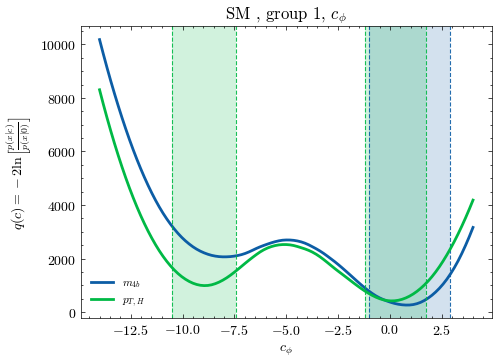

plotting CI: group = 1 | coeff = 1 | run_id = m4b_all | intervals = []
plotting CI: group = 1 | coeff = 1 | run_id = pt_h_all | intervals = []
Saved: plots/07_observable_study/single_obs_group1_c1_manual_ci.png


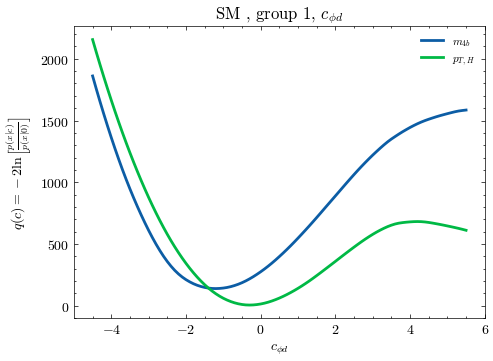

plotting CI: group = 1 | coeff = 2 | run_id = m4b_all | intervals = []
plotting CI: group = 1 | coeff = 2 | run_id = pt_h_all | intervals = []
Saved: plots/07_observable_study/single_obs_group1_c2_manual_ci.png


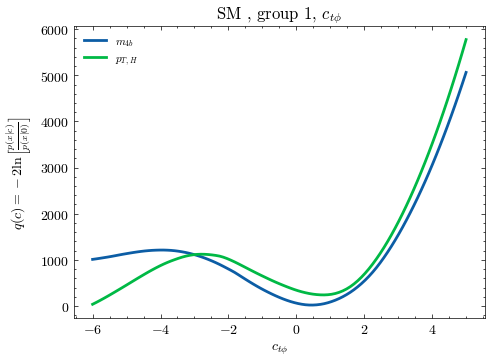

plotting CI: group = 2 | coeff = 0 | run_id = dr_bb_all | intervals = [(-11.0, -8.0), (-0.6, 0.853)]
plotting CI: group = 2 | coeff = 0 | run_id = hh_angles_all | intervals = [(-9.5, -7.0), (-1.0, 0.85)]
Saved: plots/07_observable_study/single_obs_group2_c0_manual_ci.png


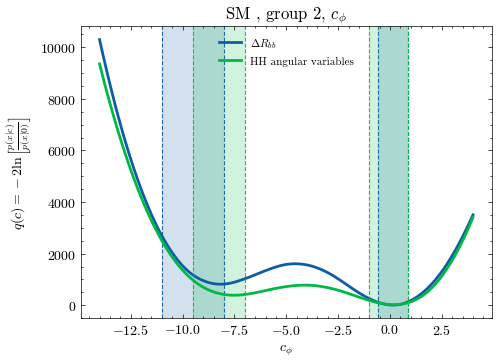

plotting CI: group = 2 | coeff = 1 | run_id = dr_bb_all | intervals = []
plotting CI: group = 2 | coeff = 1 | run_id = hh_angles_all | intervals = []
Saved: plots/07_observable_study/single_obs_group2_c1_manual_ci.png


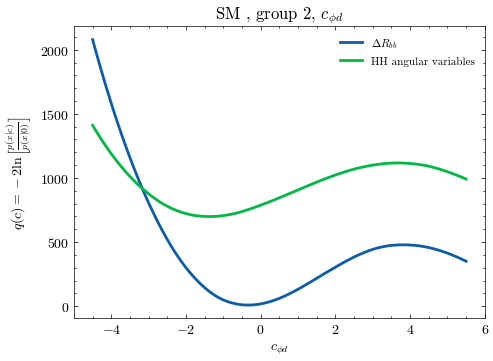

plotting CI: group = 2 | coeff = 2 | run_id = dr_bb_all | intervals = []
plotting CI: group = 2 | coeff = 2 | run_id = hh_angles_all | intervals = []
Saved: plots/07_observable_study/single_obs_group2_c2_manual_ci.png


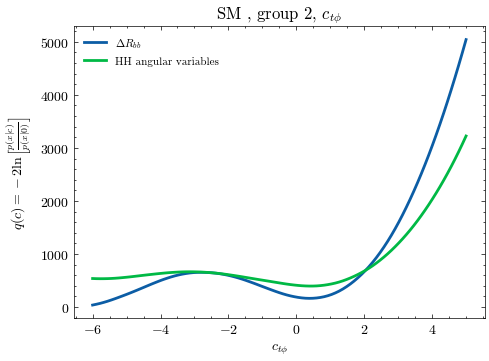

In [54]:
# ============================================================
# Manual confidence intervals for each curve
# ============================================================
# coefficient_index:
# 0 = c_phi
# 1 = c_phid
# 2 = ctphi
#
# Since PLOT_X_UNSCALED = True, enter original MadMiner coordinates.
# Each curve can have multiple disconnected intervals.

MANUAL_CI_1D = {
    0: {
        "m4b_all": [ (-1.02, 2.912)],
        "pt_h_all": [(-10.5, -7.4), (-1.21, 1.72)],
        "dr_bb_all": [(-11.0, -8.0), (-0.6, 0.853)],
        "hh_angles_all": [(-9.5, -7.0), (-1.0, 0.85)],
    },
    1: {
        "m4b_all": [],
        "pt_h_all": [],
        "dr_bb_all": [],
        "hh_angles_all": [],
    },
    2: {
        "m4b_all": [],
        "pt_h_all": [],
        "dr_bb_all": [],
        "hh_angles_all": [],
    },
}


def plot_single_obs_group(
    group_index,
    coeff_index,
    single_obs_results,
    manual_ci_dict=None,
    save=True,
):
    os.makedirs("plots/07_observable_study", exist_ok=True)

    fig, ax = plt.subplots(figsize=(5.2, 4.0))

    model_indices = SINGLE_OBS_GROUPS[group_index]

    for model_idx in model_indices:
        spec = SINGLE_OBS_MODELS[model_idx]
        label = spec["label"]
        run_id = spec["run_id"]

        scan_result = single_obs_results[label]["scans"][coeff_index]

        x = get_axis_values_for_1d(
            scan_result,
            coeff_index,
            plot_unscaled=PLOT_X_UNSCALED,
        )

        q_c = np.asarray(scan_result["q_total_raw"], dtype=float)

        line, = ax.plot(
            x,
            -q_c,
            lw=2,
            label=label,
        )

        line_color = line.get_color()

        if manual_ci_dict is not None:
            intervals = manual_ci_dict.get(coeff_index, {}).get(run_id, [])

            print(
                "plotting CI:",
                "group =", group_index + 1,
                "| coeff =", coeff_index,
                "| run_id =", run_id,
                "| intervals =", intervals,
            )

            for lo, hi in intervals:
                ax.axvspan(
                    lo,
                    hi,
                    color=line_color,
                    alpha=0.18,
                    linewidth=0,
                )

                ax.axvline(
                    lo,
                    color=line_color,
                    ls="--",
                    lw=0.8,
                    alpha=0.9,
                )

                ax.axvline(
                    hi,
                    color=line_color,
                    ls="--",
                    lw=0.8,
                    alpha=0.9,
                )

    ax.set_xlabel(
        get_coeff_label(
            coeff_index,
            plot_unscaled=PLOT_X_UNSCALED,
        )
    )

    ax.set_ylabel(
        r"$q(c)=-2\ln\left[\frac{p(x|c)}{p(x|0)}\right]$"
    )

    ax.set_title(
        rf"SM , group {group_index + 1}, {WILSON_LABELS[coeff_index]}"
    )

    ax.legend(fontsize=8)

    fig.subplots_adjust(
        left=0.17,
        right=0.96,
        bottom=0.17,
        top=0.90,
    )

    if save:
        save_path = (
            f"plots/07_observable_study/"
            f"single_obs_group{group_index + 1}_c{coeff_index}_manual_ci.png"
        )

        fig.savefig(
            save_path,
            dpi=300,
            bbox_inches="tight",
        )

        print("Saved:", save_path)

    plt.show()


for group_index in range(len(SINGLE_OBS_GROUPS)):
    for coeff_index in [0, 1, 2]:
        plot_single_obs_group(
            group_index,
            coeff_index,
            single_obs_results,
            manual_ci_dict=MANUAL_CI_1D,
            save=True,
        )

threshold CI: group = 1 | coeff = 0 | run_id = m4b_all | displayed threshold = 1.0 | real threshold = 861.0790657010234 | intervals = [(-1.1381754532350143, 2.3402224951931996)]
threshold CI: group = 1 | coeff = 0 | run_id = pt_h_all | displayed threshold = 1.0 | real threshold = 861.0790657010234 | intervals = [(-1.3482706469182628, 1.4321990778237197)]
Saved: plots/07_observable_study/single_obs_group1_c0_threshold_ci.png


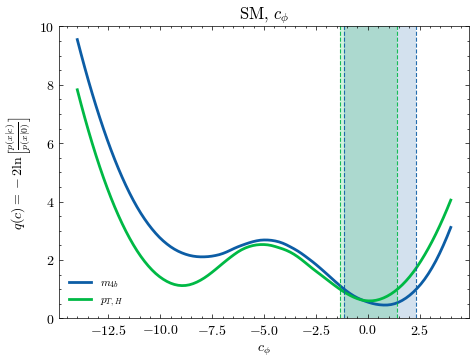

threshold CI: group = 1 | coeff = 1 | run_id = m4b_all | displayed threshold = 1.2 | real threshold = 181.76015093155084 | intervals = [(-1.823657147601455, -0.5371810244102917)]
threshold CI: group = 1 | coeff = 1 | run_id = pt_h_all | displayed threshold = 1.2 | real threshold = 181.76015093155084 | intervals = [(-1.5383703961338495, 1.2106753468462554)]
Saved: plots/07_observable_study/single_obs_group1_c1_threshold_ci.png


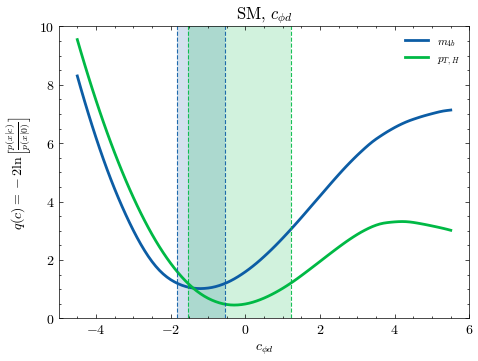

threshold CI: group = 1 | coeff = 2 | run_id = m4b_all | displayed threshold = 1 | real threshold = 366.16830892047625 | intervals = [(-1.0051545787692648, 1.7203375617971777)]
threshold CI: group = 1 | coeff = 2 | run_id = pt_h_all | displayed threshold = 1 | real threshold = 366.16830892047625 | intervals = [(-6.0, -5.200740152703436), (-0.09264199220010107, 1.4712004691462892)]
Saved: plots/07_observable_study/single_obs_group1_c2_threshold_ci.png


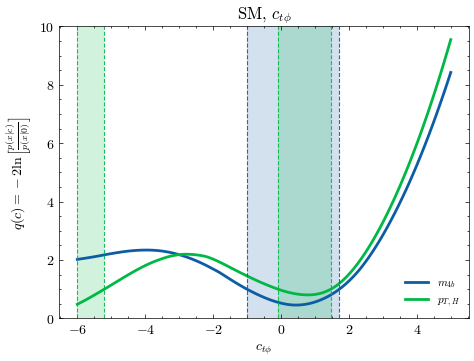

threshold CI: group = 2 | coeff = 0 | run_id = dr_bb_all | displayed threshold = 1.0 | real threshold = 624.355005996513 | intervals = [(-1.7718858961059532, 1.764205986166752)]
threshold CI: group = 2 | coeff = 0 | run_id = hh_angles_all | displayed threshold = 1.0 | real threshold = 624.355005996513 | intervals = [(-8.823268191888413, -5.6751204264456785), (-2.6988297126660945, 1.9492603549567806)]
Saved: plots/07_observable_study/single_obs_group2_c0_threshold_ci.png


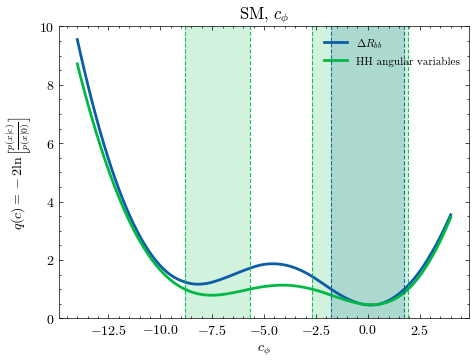

threshold CI: group = 2 | coeff = 1 | run_id = dr_bb_all | displayed threshold = 1 | real threshold = 133.15276143376656 | intervals = [(-1.4528737270067031, 1.0070092412081721)]
threshold CI: group = 2 | coeff = 1 | run_id = hh_angles_all | displayed threshold = 1 | real threshold = 133.15276143376656 | intervals = []
Saved: plots/07_observable_study/single_obs_group2_c1_threshold_ci.png


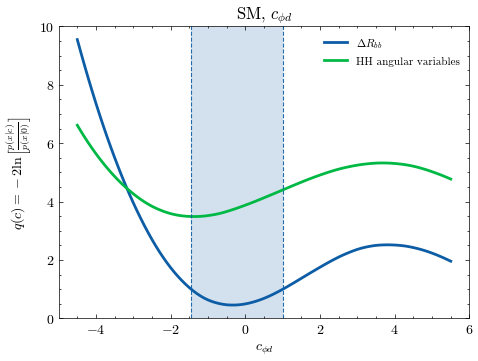

threshold CI: group = 2 | coeff = 2 | run_id = dr_bb_all | displayed threshold = 1.2 | real threshold = 448.2266374684043 | intervals = [(-6.0, -4.205544254697737), (-1.2482571045501472, 1.6178911014274235)]
threshold CI: group = 2 | coeff = 2 | run_id = hh_angles_all | displayed threshold = 1.2 | real threshold = 448.2266374684043 | intervals = [(-0.43283840778089805, 1.122206562796094)]
Saved: plots/07_observable_study/single_obs_group2_c2_threshold_ci.png


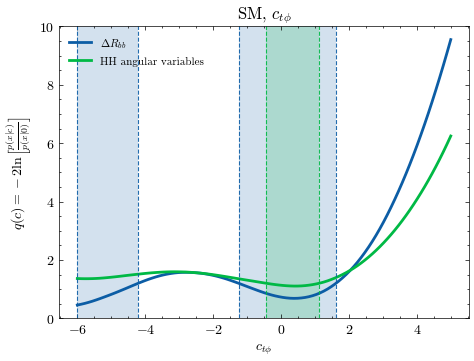

,group,coeff_index,coefficient,run_id,label,displayed_threshold,real_threshold,intervals
0,1,0,$c_\phi$,m4b_all,$m_{4b}$,1.0,861.079066,"[(-1.1381754532350143, 2.3402224951931996)]"
1,1,0,$c_\phi$,pt_h_all,"$p_{T,H}$",1.0,861.079066,"[(-1.3482706469182628, 1.4321990778237197)]"
2,1,1,$c_{\phi d}$,m4b_all,$m_{4b}$,1.2,181.760151,"[(-1.823657147601455, -0.5371810244102917)]"
3,1,1,$c_{\phi d}$,pt_h_all,"$p_{T,H}$",1.2,181.760151,"[(-1.5383703961338495, 1.2106753468462554)]"
4,1,2,$c_{t\phi}$,m4b_all,$m_{4b}$,1.0,366.168309,"[(-1.0051545787692648, 1.7203375617971777)]"
5,1,2,$c_{t\phi}$,pt_h_all,"$p_{T,H}$",1.0,366.168309,"[(-6.0, -5.200740152703436), (-0.0926419922001..."
6,2,0,$c_\phi$,dr_bb_all,$\Delta R_{bb}$,1.0,624.355006,"[(-1.7718858961059532, 1.764205986166752)]"
7,2,0,$c_\phi$,hh_angles_all,HH angular variables,1.0,624.355006,"[(-8.823268191888413, -5.6751204264456785), (-..."
8,2,1,$c_{\phi d}$,dr_bb_all,$\Delta R_{bb}$,1.0,133.152761,"[(-1.4528737270067031, 1.0070092412081721)]"
9,2,1,$c_{\phi d}$,hh_angles_all,HH angular variables,1.0,133.152761,[]


In [55]:
# ============================================================
# Manual displayed-y thresholds for confidence intervals
# ============================================================
# coefficient_index:
# 0 = c_phi
# 1 = c_phid
# 2 = ctphi
#
# The threshold values below are in the displayed y-axis scale,
# i.e. the fake 0--10 axis labels.
#
# Confidence interval is defined by:
# displayed_y(c) <= displayed_threshold
#
# The plotted curve itself is still y = -q_total_raw.
# Only the displayed y-axis labels are remapped.

MANUAL_Y_THRESHOLD_1D = {
    0: {
        "m4b_all": 1.0,
        "pt_h_all":1.0,
        "dr_bb_all": 1.0,
        "hh_angles_all": 1.0,
    },
    1: {
        "m4b_all": 1.2,
        "pt_h_all": 1.2,
        "dr_bb_all": 1,
        "hh_angles_all": 1,
    },
    2: {
        "m4b_all": 1,
        "pt_h_all": 1,
        "dr_bb_all": 1.2,
        "hh_angles_all": 1.2,
    },
}


def fake_to_real_y(fake_y, real_ymin, real_ymax, fake_min=0.0, fake_max=10.0):
    fake_y = float(fake_y)

    return real_ymin + (fake_y - fake_min) / (fake_max - fake_min) * (real_ymax - real_ymin)


def real_to_fake_y(real_y, real_ymin, real_ymax, fake_min=0.0, fake_max=10.0):
    real_y = np.asarray(real_y, dtype=float)

    return fake_min + (real_y - real_ymin) / (real_ymax - real_ymin) * (fake_max - fake_min)


def intervals_below_threshold(x, y, threshold):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    valid = np.isfinite(x) & np.isfinite(y)
    x = x[valid]
    y = y[valid]

    inside = y <= threshold
    intervals = []

    if not np.any(inside):
        return intervals

    start = None

    for i in range(len(x)):
        if inside[i] and start is None:
            if i == 0:
                start = x[i]
            else:
                start = interpolate_crossing(
                    x[i - 1],
                    y[i - 1],
                    x[i],
                    y[i],
                    threshold,
                )

        if inside[i] and (i == len(x) - 1 or not inside[i + 1]):
            if i == len(x) - 1:
                end = x[i]
            else:
                end = interpolate_crossing(
                    x[i],
                    y[i],
                    x[i + 1],
                    y[i + 1],
                    threshold,
                )

            intervals.append((float(start), float(end)))
            start = None

    return intervals


def apply_display_y_axis_labels(ax, fake_min=0.0, fake_max=10.0, n_ticks=6):
    real_ymin, real_ymax = ax.get_ylim()

    real_ticks = np.linspace(real_ymin, real_ymax, n_ticks)
    fake_labels = np.linspace(fake_min, fake_max, n_ticks)

    ax.set_yticks(real_ticks)
    ax.set_yticklabels([f"{v:.0f}" for v in fake_labels])


def plot_single_obs_group_with_threshold_ci(
    group_index,
    coeff_index,
    single_obs_results,
    manual_y_threshold_dict=None,
    fake_min=0.0,
    fake_max=10.0,
    save=True,
):
    os.makedirs("plots/07_observable_study", exist_ok=True)

    fig, ax = plt.subplots(figsize=(5.2, 4.0))

    model_indices = SINGLE_OBS_GROUPS[group_index]

    curve_store = []

    for model_idx in model_indices:
        spec = SINGLE_OBS_MODELS[model_idx]
        label = spec["label"]
        run_id = spec["run_id"]

        scan_result = single_obs_results[label]["scans"][coeff_index]

        x = get_axis_values_for_1d(
            scan_result,
            coeff_index,
            plot_unscaled=PLOT_X_UNSCALED,
        )

        q_c = np.asarray(scan_result["q_total_raw"], dtype=float)

        y = -q_c

        line, = ax.plot(
            x,
            y,
            lw=2,
            label=label,
        )

        curve_store.append(
            {
                "label": label,
                "run_id": run_id,
                "x": x,
                "y": y,
                "color": line.get_color(),
            }
        )

    real_ymin, real_ymax = ax.get_ylim()

    interval_summary = []

    for curve in curve_store:
        run_id = curve["run_id"]
        label = curve["label"]
        x = curve["x"]
        y = curve["y"]
        color = curve["color"]

        displayed_threshold = None

        if manual_y_threshold_dict is not None:
            displayed_threshold = manual_y_threshold_dict.get(coeff_index, {}).get(run_id, None)

        if displayed_threshold is None:
            continue

        real_threshold = fake_to_real_y(
            displayed_threshold,
            real_ymin,
            real_ymax,
            fake_min=fake_min,
            fake_max=fake_max,
        )

        intervals = intervals_below_threshold(
            x,
            y,
            real_threshold,
        )

        interval_summary.append(
            {
                "group": group_index + 1,
                "coeff_index": coeff_index,
                "coefficient": WILSON_LABELS[coeff_index],
                "run_id": run_id,
                "label": label,
                "displayed_threshold": displayed_threshold,
                "real_threshold": real_threshold,
                "intervals": intervals,
            }
        )

        print(
            "threshold CI:",
            "group =", group_index + 1,
            "| coeff =", coeff_index,
            "| run_id =", run_id,
            "| displayed threshold =", displayed_threshold,
            "| real threshold =", real_threshold,
            "| intervals =", intervals,
        )

        for lo, hi in intervals:
            ax.axvspan(
                lo,
                hi,
                color=color,
                alpha=0.18,
                linewidth=0,
            )

            ax.axvline(
                lo,
                color=color,
                ls="--",
                lw=0.8,
                alpha=0.9,
            )

            ax.axvline(
                hi,
                color=color,
                ls="--",
                lw=0.8,
                alpha=0.9,
            )

        # ax.axhline(
        #     real_threshold,
        #     color=color,
        #     ls=":",
        #     lw=0.9,
        #     alpha=0.7,
        # )

    ax.set_xlabel(
        get_coeff_label(
            coeff_index,
            plot_unscaled=PLOT_X_UNSCALED,
        )
    )

    ax.set_ylabel(
        r"$q(c)=-2\ln\left[\frac{p(x|c)}{p(x|0)}\right]$"
    )

    ax.set_title(
        rf"SM, {WILSON_LABELS[coeff_index]}"
    )

    ax.legend(fontsize=8)

    apply_display_y_axis_labels(
        ax,
        fake_min=fake_min,
        fake_max=fake_max,
        n_ticks=6,
    )

    fig.subplots_adjust(
        left=0.17,
        right=0.96,
        bottom=0.17,
        top=0.90,
    )

    if save:
        save_path = (
            f"plots/07_observable_study/"
            f"single_obs_group{group_index + 1}_c{coeff_index}_threshold_ci.png"
        )

        fig.savefig(
            save_path,
            dpi=300,
            bbox_inches="tight",
        )

        print("Saved:", save_path)

    plt.show()

    return interval_summary


all_threshold_interval_summaries = []

for group_index in range(len(SINGLE_OBS_GROUPS)):
    for coeff_index in [0, 1, 2]:
        summary = plot_single_obs_group_with_threshold_ci(
            group_index,
            coeff_index,
            single_obs_results,
            manual_y_threshold_dict=MANUAL_Y_THRESHOLD_1D,
            fake_min=0.0,
            fake_max=10.0,
            save=True,
        )

        all_threshold_interval_summaries.extend(summary)


threshold_interval_df = pd.DataFrame(all_threshold_interval_summaries)

display(threshold_interval_df)

threshold_interval_df.to_csv(
    "plots/07_observable_study/manual_threshold_interval_summary.csv",
    index=False,
)

threshold CI: row = 1 | col = 1 | coeff = 0 | run_id = pt_h_all | displayed threshold = 1.0 | real threshold = 861.0790657010234 | intervals = [(-1.3482706469182628, 1.4321990778237197)]
threshold CI: row = 1 | col = 1 | coeff = 0 | run_id = m4b_all | displayed threshold = 1.0 | real threshold = 861.0790657010234 | intervals = [(-1.1381754532350143, 2.3402224951931996)]
threshold CI: row = 1 | col = 2 | coeff = 1 | run_id = pt_h_all | displayed threshold = 1.0 | real threshold = 134.456805165456 | intervals = [(-1.3640413853477584, 0.96380936195247)]
threshold CI: row = 1 | col = 2 | coeff = 1 | run_id = m4b_all | displayed threshold = 1.0 | real threshold = 134.456805165456 | intervals = []
threshold CI: row = 1 | col = 3 | coeff = 2 | run_id = pt_h_all | displayed threshold = 1.0 | real threshold = 366.16830892047625 | intervals = [(-6.0, -5.200740152703436), (-0.09264199220010107, 1.4712004691462892)]
threshold CI: row = 1 | col = 3 | coeff = 2 | run_id = m4b_all | displayed thresho

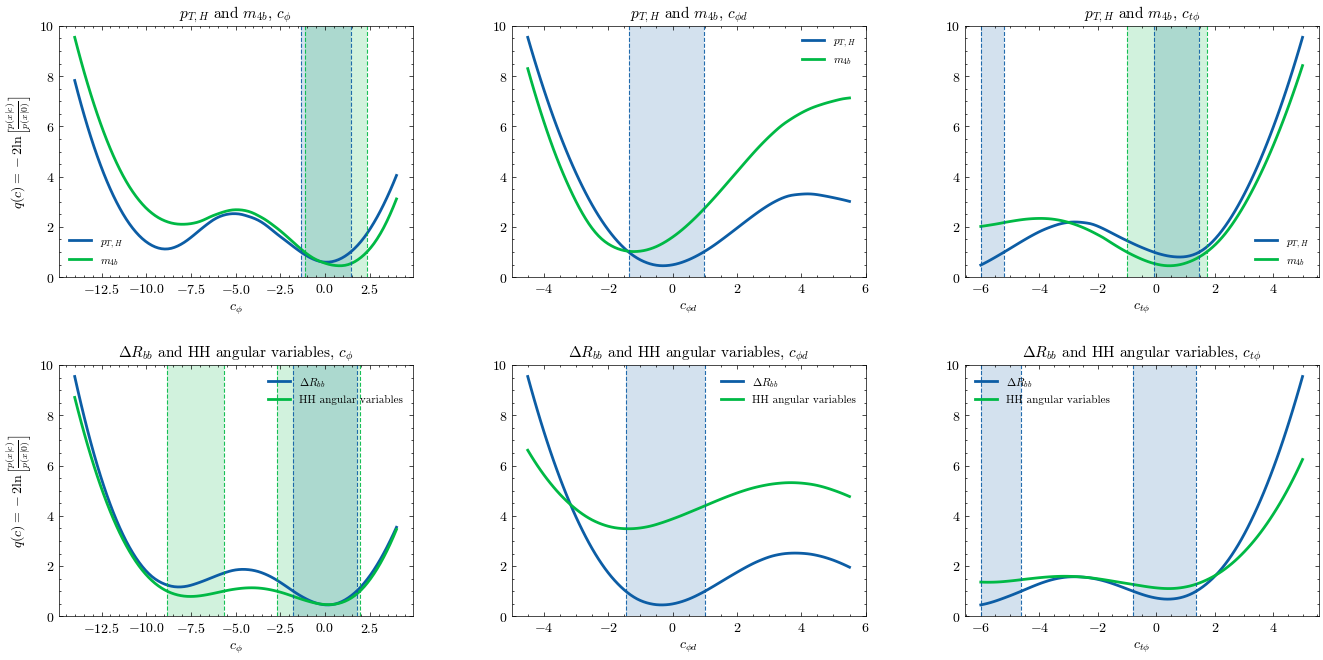

,row,column,group,coeff_index,coefficient,run_id,label,displayed_threshold,real_threshold,intervals
0,1,1,"$p_{T,H}$ and $m_{4b}$",0,$c_\phi$,pt_h_all,"$p_{T,H}$",1.0,861.079066,"[(-1.3482706469182628, 1.4321990778237197)]"
1,1,1,"$p_{T,H}$ and $m_{4b}$",0,$c_\phi$,m4b_all,$m_{4b}$,1.0,861.079066,"[(-1.1381754532350143, 2.3402224951931996)]"
2,1,2,"$p_{T,H}$ and $m_{4b}$",1,$c_{\phi d}$,pt_h_all,"$p_{T,H}$",1.0,134.456805,"[(-1.3640413853477584, 0.96380936195247)]"
3,1,2,"$p_{T,H}$ and $m_{4b}$",1,$c_{\phi d}$,m4b_all,$m_{4b}$,1.0,134.456805,[]
4,1,3,"$p_{T,H}$ and $m_{4b}$",2,$c_{t\phi}$,pt_h_all,"$p_{T,H}$",1.0,366.168309,"[(-6.0, -5.200740152703436), (-0.0926419922001..."
5,1,3,"$p_{T,H}$ and $m_{4b}$",2,$c_{t\phi}$,m4b_all,$m_{4b}$,1.0,366.168309,"[(-1.0051545787692648, 1.7203375617971777)]"
6,2,1,$\Delta R_{bb}$ and HH angular variables,0,$c_\phi$,dr_bb_all,$\Delta R_{bb}$,1.0,624.355006,"[(-1.7718858961059532, 1.764205986166752)]"
7,2,1,$\Delta R_{bb}$ and HH angular variables,0,$c_\phi$,hh_angles_all,HH angular variables,1.0,624.355006,"[(-8.823268191888413, -5.6751204264456785), (-..."
8,2,2,$\Delta R_{bb}$ and HH angular variables,1,$c_{\phi d}$,dr_bb_all,$\Delta R_{bb}$,1.0,133.152761,"[(-1.4528737270067031, 1.0070092412081721)]"
9,2,2,$\Delta R_{bb}$ and HH angular variables,1,$c_{\phi d}$,hh_angles_all,HH angular variables,1.0,133.152761,[]


In [68]:
# ============================================================
# 2 x 3 combined plot with manual displayed-y thresholds
# Row 1: pT,H and m4b
# Row 2: DeltaRbb and HH angular variables
# Columns: c_phi, c_phid, ctphi
# ============================================================

MANUAL_Y_THRESHOLD_1D = {
    0: {
        "m4b_all": 1.0,
        "pt_h_all": 1.0,
        "dr_bb_all": 1.0,
        "hh_angles_all": 1.0,
    },
    1: {
        "m4b_all": 1.0,
        "pt_h_all": 1.0,
        "dr_bb_all": 1.0,
        "hh_angles_all": 1.0,
    },
    2: {
        "m4b_all": 1.0,
        "pt_h_all": 1.0,
        "dr_bb_all": 1.0,
        "hh_angles_all": 1.0,
    },
}

# ------------------------------------------------------------
# Layout controls
# ------------------------------------------------------------

FIGSIZE = (14.0, 7.2)

LEFT = 0.08
RIGHT = 0.98
BOTTOM = 0.10
TOP = 0.92

WSPACE = 0.28
HSPACE = 0.35

FAKE_Y_MIN = 0.0
FAKE_Y_MAX = 10.0
N_Y_TICKS = 6

SAVE_COMBINED_FIG = True
COMBINED_SAVE_PATH = "plots/07_observable_study/single_obs_2x3_threshold_ci.png"

# ------------------------------------------------------------
# Plot grouping
# ------------------------------------------------------------
# First row: pT,H and m4b
# Second row: DeltaRbb and HH angular variables

PLOT_GROUP_RUN_IDS_2X3 = [
    ["pt_h_all", "m4b_all"],
    ["dr_bb_all", "hh_angles_all"],
]

ROW_LABELS = [
    r"$p_{T,H}$ and $m_{4b}$",
    r"$\Delta R_{bb}$ and HH angular variables",
]

COEFF_INDICES = [0, 1, 2]

SPEC_BY_RUN_ID = {
    spec["run_id"]: spec
    for spec in SINGLE_OBS_MODELS
}


def fake_to_real_y(fake_y, real_ymin, real_ymax, fake_min=0.0, fake_max=10.0):
    fake_y = float(fake_y)

    return real_ymin + (fake_y - fake_min) / (fake_max - fake_min) * (real_ymax - real_ymin)


def intervals_below_threshold(x, y, threshold):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    valid = np.isfinite(x) & np.isfinite(y)
    x = x[valid]
    y = y[valid]

    inside = y <= threshold
    intervals = []

    if not np.any(inside):
        return intervals

    start = None

    for i in range(len(x)):
        if inside[i] and start is None:
            if i == 0:
                start = x[i]
            else:
                start = interpolate_crossing(
                    x[i - 1],
                    y[i - 1],
                    x[i],
                    y[i],
                    threshold,
                )

        if inside[i] and (i == len(x) - 1 or not inside[i + 1]):
            if i == len(x) - 1:
                end = x[i]
            else:
                end = interpolate_crossing(
                    x[i],
                    y[i],
                    x[i + 1],
                    y[i + 1],
                    threshold,
                )

            intervals.append((float(start), float(end)))
            start = None

    return intervals


def apply_display_y_axis_labels(ax, fake_min=0.0, fake_max=10.0, n_ticks=6):
    real_ymin, real_ymax = ax.get_ylim()

    real_ticks = np.linspace(real_ymin, real_ymax, n_ticks)
    fake_labels = np.linspace(fake_min, fake_max, n_ticks)

    ax.set_yticks(real_ticks)
    ax.set_yticklabels([f"{v:.0f}" for v in fake_labels])


def plot_2x3_single_obs_threshold_ci(
    single_obs_results,
    manual_y_threshold_dict,
    save=True,
):
    os.makedirs("plots/07_observable_study", exist_ok=True)

    fig, axes = plt.subplots(
        2,
        3,
        figsize=FIGSIZE,
        sharex=False,
        sharey=False,
    )

    interval_summary = []

    for row_idx, group_run_ids in enumerate(PLOT_GROUP_RUN_IDS_2X3):
        for col_idx, coeff_index in enumerate(COEFF_INDICES):
            ax = axes[row_idx, col_idx]

            curve_store = []

            for run_id in group_run_ids:
                spec = SPEC_BY_RUN_ID[run_id]
                label = spec["label"]

                scan_result = single_obs_results[label]["scans"][coeff_index]

                x = get_axis_values_for_1d(
                    scan_result,
                    coeff_index,
                    plot_unscaled=PLOT_X_UNSCALED,
                )

                q_c = np.asarray(scan_result["q_total_raw"], dtype=float)

                y = -q_c

                line, = ax.plot(
                    x,
                    y,
                    lw=2,
                    label=label,
                )

                curve_store.append(
                    {
                        "label": label,
                        "run_id": run_id,
                        "x": x,
                        "y": y,
                        "color": line.get_color(),
                    }
                )

            real_ymin, real_ymax = ax.get_ylim()

            for curve in curve_store:
                run_id = curve["run_id"]
                label = curve["label"]
                x = curve["x"]
                y = curve["y"]
                color = curve["color"]

                displayed_threshold = manual_y_threshold_dict.get(coeff_index, {}).get(run_id, None)

                if displayed_threshold is None:
                    continue

                real_threshold = fake_to_real_y(
                    displayed_threshold,
                    real_ymin,
                    real_ymax,
                    fake_min=FAKE_Y_MIN,
                    fake_max=FAKE_Y_MAX,
                )

                intervals = intervals_below_threshold(
                    x,
                    y,
                    real_threshold,
                )

                interval_summary.append(
                    {
                        "row": row_idx + 1,
                        "column": col_idx + 1,
                        "group": ROW_LABELS[row_idx],
                        "coeff_index": coeff_index,
                        "coefficient": WILSON_LABELS[coeff_index],
                        "run_id": run_id,
                        "label": label,
                        "displayed_threshold": displayed_threshold,
                        "real_threshold": real_threshold,
                        "intervals": intervals,
                    }
                )

                print(
                    "threshold CI:",
                    "row =", row_idx + 1,
                    "| col =", col_idx + 1,
                    "| coeff =", coeff_index,
                    "| run_id =", run_id,
                    "| displayed threshold =", displayed_threshold,
                    "| real threshold =", real_threshold,
                    "| intervals =", intervals,
                )

                for lo, hi in intervals:
                    ax.axvspan(
                        lo,
                        hi,
                        color=color,
                        alpha=0.18,
                        linewidth=0,
                    )

                    ax.axvline(
                        lo,
                        color=color,
                        ls="--",
                        lw=0.8,
                        alpha=0.9,
                    )

                    ax.axvline(
                        hi,
                        color=color,
                        ls="--",
                        lw=0.8,
                        alpha=0.9,
                    )

            ax.set_title(
                rf"{ROW_LABELS[row_idx]}, {WILSON_LABELS[coeff_index]}",
                fontsize=11,
            )

            ax.set_xlabel(
                get_coeff_label(
                    coeff_index,
                    plot_unscaled=PLOT_X_UNSCALED,
                ),
                fontsize=10,
            )

            if col_idx == 0:
                ax.set_ylabel(
                    r"$q(c)=-2\ln\left[\frac{p(x|c)}{p(x|0)}\right]$",
                    fontsize=10,
                )

            ax.legend(fontsize=8)

            apply_display_y_axis_labels(
                ax,
                fake_min=FAKE_Y_MIN,
                fake_max=FAKE_Y_MAX,
                n_ticks=N_Y_TICKS,
            )

    fig.subplots_adjust(
        left=LEFT,
        right=RIGHT,
        bottom=BOTTOM,
        top=TOP,
        wspace=WSPACE,
        hspace=HSPACE,
    )

    if save:
        fig.savefig(
            COMBINED_SAVE_PATH,
            dpi=300,
            bbox_inches="tight",
        )

        print("Saved:", COMBINED_SAVE_PATH)

    plt.show()

    return interval_summary


all_threshold_interval_summaries = plot_2x3_single_obs_threshold_ci(
    single_obs_results,
    manual_y_threshold_dict=MANUAL_Y_THRESHOLD_1D,
    save=SAVE_COMBINED_FIG,
)

threshold_interval_df = pd.DataFrame(all_threshold_interval_summaries)

display(threshold_interval_df)

threshold_interval_df.to_csv(
    "plots/07_observable_study/manual_threshold_interval_summary_2x3.csv",
    index=False,
)

In [72]:
# ============================================================
# Comparison models: selected 2 observables vs custom top3
# ============================================================

COMPARISON_MODEL_SPECS = [
    {
        "label": r"$\Delta R_{bb}+p_{T,H}$",
        "run_id": "m4b_pt_h_all",
        "model_dir": f"{MODEL_BACKUP_DIR}/m4b_pt_h",
    },
    {
        "label": r"top3 custom",
        "run_id": "top3_custom_all",
        "model_dir": f"{MODEL_BACKUP_DIR}/top3_custom",
    },
]

print("Checking comparison models:")

for spec in COMPARISON_MODEL_SPECS:
    print("\n" + "=" * 80)
    print("label:", spec["label"])
    print("run_id:", spec["run_id"])
    print("model_dir:", spec["model_dir"])
    print("model_dir exists:", os.path.exists(spec["model_dir"]))

    config_path = find_run_config_path(spec["run_id"])
    print("run_config:", config_path)

    cfg = load_yaml(config_path)
    print("network_id:", cfg.get("network_id"))
    print("parameter_code:", cfg.get("parameter_code"))
    print("features:", cfg.get("features"))

    network_id = cfg.get("network_id")

    expected_files = [
        f"{spec['model_dir']}/scaler_{network_id}.pkl",
        f"{spec['model_dir']}/{network_id}_Ssm_Salt_best_model.pt",
        f"{spec['model_dir']}/{network_id}_B_Salt_best_model.pt",
        f"{spec['model_dir']}/{network_id}_Ssm_B_best_model.pt",
    ]

    for path in expected_files:
        print("exists:", os.path.exists(path), "|", path)

Checking comparison models:

label: $\Delta R_{bb}+p_{T,H}$
run_id: m4b_pt_h_all
model_dir: /vols/cms/jl3222/model_backup/m4b_pt_h
model_dir exists: True
run_config: /home/hep/jl3222/projects/nsbi_photon_final_state/run_configs/m4b_pt_h/m4b_pt_h_all.yml
network_id: m4b_pt_h_all
parameter_code: c2
features: [25, 26, 17, 18]
exists: True | /vols/cms/jl3222/model_backup/m4b_pt_h/scaler_m4b_pt_h_all.pkl
exists: True | /vols/cms/jl3222/model_backup/m4b_pt_h/m4b_pt_h_all_Ssm_Salt_best_model.pt
exists: True | /vols/cms/jl3222/model_backup/m4b_pt_h/m4b_pt_h_all_B_Salt_best_model.pt
exists: True | /vols/cms/jl3222/model_backup/m4b_pt_h/m4b_pt_h_all_Ssm_B_best_model.pt

label: top3 custom
run_id: top3_custom_all
model_dir: /vols/cms/jl3222/model_backup/top3_custom
model_dir exists: True
run_config: /home/hep/jl3222/projects/nsbi_photon_final_state/run_configs/top3_custom/top3_custom_all.yml
network_id: top3_custom_all
parameter_code: c2
features: [24, 27, 30]
exists: True | /vols/cms/jl3222/mode

In [73]:
# ============================================================
# Evaluate SM pseudo-data scans for comparison models
# ============================================================

FORCE_RECOMPUTE_COMPARISON_SM = True
comparison_sm_cache_path = "preplot_pickles/07_selected2_vs_top3custom_sm_1d_scans.pkl"

os.makedirs("preplot_pickles", exist_ok=True)

if os.path.exists(comparison_sm_cache_path) and not FORCE_RECOMPUTE_COMPARISON_SM:
    with open(comparison_sm_cache_path, "rb") as file:
        comparison_sm_results = pickle.load(file)

    print("Loaded cached comparison SM 1D results from:", comparison_sm_cache_path)

else:
    comparison_sm_results = {}

    for spec in COMPARISON_MODEL_SPECS:
        label = spec["label"]
        run_id = spec["run_id"]
        model_dir = spec["model_dir"]

        print("\n" + "=" * 80)
        print("Running comparison model:", label)
        print("run_id:", run_id)
        print("model_dir:", model_dir)

        bundle = load_model_bundle(
            run_id,
            device,
            model_dir=model_dir,
        )

        pseudo_sm = build_pseudo_data(
            bundle,
            true_code="sm",
            true_c_unscaled=(0, 0, 0),
            N_sig_SM_target=N_sig_SM_target,
            N_bkg_SM_target=N_bkg_SM_target,
            random_state=7,
        )

        comparison_sm_results[label] = {
            "spec": spec,
            "run_id": run_id,
            "model_dir": model_dir,
            "features": bundle["features"],
            "parameter_code": bundle["parameter_code"],
            "network_id": bundle["network_id"],
            "scans": {},
        }

        for coeff_index in [0, 1, 2]:
            scan_indices = str(coeff_index)

            print("\n" + "-" * 80)
            print(f"1D scan for {label}: {WILSON_LABELS[coeff_index]}")
            print("scan_indices:", scan_indices)

            scan_result = evaluate_scan_raw(
                bundle,
                pseudo_sm,
                scan_indices=scan_indices,
                n_scan_points=N_SCAN_1D,
                lower_limits_scaled=lower_limits_scaled,
                upper_limits_scaled=upper_limits_scaled,
                N_sig_SM_target=N_sig_SM_target,
                N_bkg_SM_target=N_bkg_SM_target,
            )

            comparison_sm_results[label]["scans"][coeff_index] = scan_result

            q_c = np.asarray(scan_result["q_total_raw"], dtype=float)

            print("q_total_raw shape:", q_c.shape)
            print("plotted y min:", np.min(-q_c), "plotted y max:", np.max(-q_c))

            with open(comparison_sm_cache_path, "wb") as file:
                pickle.dump(comparison_sm_results, file)

            print("Intermediate result saved to:", comparison_sm_cache_path)

    print("\nDone.")
    print("Saved comparison SM results to:", comparison_sm_cache_path)


Running comparison model: $\Delta R_{bb}+p_{T,H}$
run_id: m4b_pt_h_all
model_dir: /vols/cms/jl3222/model_backup/m4b_pt_h
Loading run config: /home/hep/jl3222/projects/nsbi_photon_final_state/run_configs/m4b_pt_h/m4b_pt_h_all.yml
Loading scaler: /vols/cms/jl3222/model_backup/m4b_pt_h/scaler_m4b_pt_h_all.pkl
Loading model: /vols/cms/jl3222/model_backup/m4b_pt_h/m4b_pt_h_all_Ssm_Salt_best_model.pt
Loading model: /vols/cms/jl3222/model_backup/m4b_pt_h/m4b_pt_h_all_B_Salt_best_model.pt
Loading model: /vols/cms/jl3222/model_backup/m4b_pt_h/m4b_pt_h_all_Ssm_B_best_model.pt
Loaded run_id=m4b_pt_h_all, model_dir=/vols/cms/jl3222/model_backup/m4b_pt_h, network_id=m4b_pt_h_all, parameter_code=c2, features=[25, 26, 17, 18]
Pseudo-data built for sm: N_sig=3600.000, N_bkg=8160, shape=(11760, 4)

--------------------------------------------------------------------------------
1D scan for $\Delta R_{bb}+p_{T,H}$: $c_\phi$
scan_indices: 0


/home/hep/jl3222/projects/nsbi_photon_final_state/helpers/test_statistics.py:242: RuntimeWarning: divide by zero encountered in divide
  comp_3  = np.array([(f_sig_SM / (1.0 - f_sig_alt[i]))*(1.0/lr_B_to_S_SM[:]) for i in range(N_c_points)])  # shape: (# c points, # test points, 1)


q_total_raw shape: (101,)
plotted y min: 49.26085639541964 plotted y max: 10218.485487203186
Intermediate result saved to: preplot_pickles/07_selected2_vs_top3custom_sm_1d_scans.pkl

--------------------------------------------------------------------------------
1D scan for $\Delta R_{bb}+p_{T,H}$: $c_{\phi d}$
scan_indices: 1
q_total_raw shape: (101,)
plotted y min: 61.958114506996026 plotted y max: 1971.575468633686
Intermediate result saved to: preplot_pickles/07_selected2_vs_top3custom_sm_1d_scans.pkl

--------------------------------------------------------------------------------
1D scan for $\Delta R_{bb}+p_{T,H}$: $c_{t\phi}$
scan_indices: 2
q_total_raw shape: (101,)
plotted y min: 5.908172264673738 plotted y max: 5886.528755118103
Intermediate result saved to: preplot_pickles/07_selected2_vs_top3custom_sm_1d_scans.pkl

Running comparison model: top3 custom
run_id: top3_custom_all
model_dir: /vols/cms/jl3222/model_backup/top3_custom
Loading run config: /home/hep/jl3222/project

Saved: plots/07_observable_study/selected2_vs_top3custom_sm_1x3.png


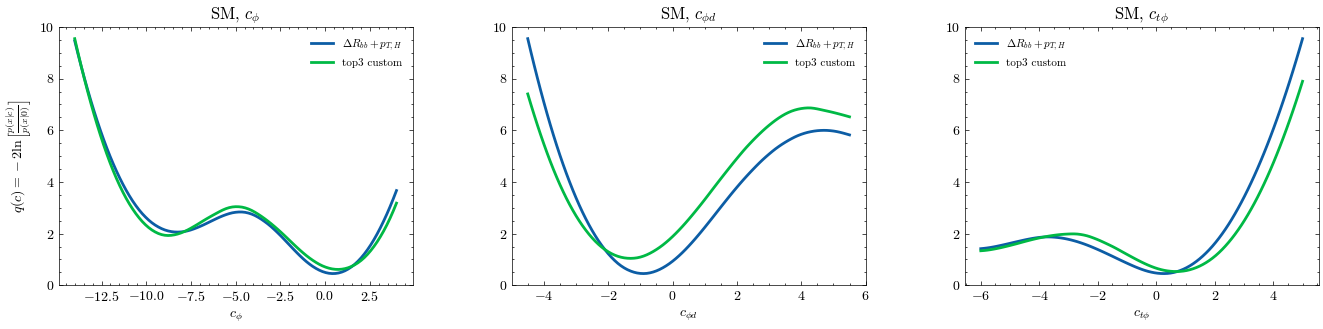

In [75]:
# ============================================================
# Plot selected 2 observables vs custom top3 in one 1x3 figure
# ============================================================

COMPARISON_FIGSIZE = (14.0, 3.8)

COMPARISON_LEFT = 0.08
COMPARISON_RIGHT = 0.98
COMPARISON_BOTTOM = 0.18
COMPARISON_TOP = 0.86

COMPARISON_WSPACE = 0.28

COMPARISON_FAKE_Y_MIN = 0.0
COMPARISON_FAKE_Y_MAX = 10.0
COMPARISON_N_Y_TICKS = 6

SAVE_COMPARISON_SM_FIG = True
COMPARISON_SM_SAVE_PATH = "plots/07_observable_study/selected2_vs_top3custom_sm_1x3.png"


def apply_display_y_axis_labels(ax, fake_min=0.0, fake_max=10.0, n_ticks=6):
    real_ymin, real_ymax = ax.get_ylim()

    real_ticks = np.linspace(real_ymin, real_ymax, n_ticks)
    fake_labels = np.linspace(fake_min, fake_max, n_ticks)

    ax.set_yticks(real_ticks)
    ax.set_yticklabels([f"{v:.0f}" for v in fake_labels])


def plot_comparison_sm_1x3(
    comparison_sm_results,
    save=True,
):
    os.makedirs("plots/07_observable_study", exist_ok=True)

    fig, axes = plt.subplots(
        1,
        3,
        figsize=COMPARISON_FIGSIZE,
        sharex=False,
        sharey=False,
    )

    for col_idx, coeff_index in enumerate([0, 1, 2]):
        ax = axes[col_idx]

        for spec in COMPARISON_MODEL_SPECS:
            label = spec["label"]

            scan_result = comparison_sm_results[label]["scans"][coeff_index]

            x = get_axis_values_for_1d(
                scan_result,
                coeff_index,
                plot_unscaled=PLOT_X_UNSCALED,
            )

            q_c = np.asarray(scan_result["q_total_raw"], dtype=float)

            y = -q_c

            ax.plot(
                x,
                y,
                lw=2,
                label=label,
            )

        ax.set_title(
            rf"SM, {WILSON_LABELS[coeff_index]}",
            fontsize=12,
        )

        ax.set_xlabel(
            get_coeff_label(
                coeff_index,
                plot_unscaled=PLOT_X_UNSCALED,
            ),
            fontsize=10,
        )

        if col_idx == 0:
            ax.set_ylabel(
                r"$q(c)=-2\ln\left[\frac{p(x|c)}{p(x|0)}\right]$",
                fontsize=10,
            )

        ax.legend(fontsize=8)

        apply_display_y_axis_labels(
            ax,
            fake_min=COMPARISON_FAKE_Y_MIN,
            fake_max=COMPARISON_FAKE_Y_MAX,
            n_ticks=COMPARISON_N_Y_TICKS,
        )

    fig.subplots_adjust(
        left=COMPARISON_LEFT,
        right=COMPARISON_RIGHT,
        bottom=COMPARISON_BOTTOM,
        top=COMPARISON_TOP,
        wspace=COMPARISON_WSPACE,
    )

    if save:
        fig.savefig(
            COMPARISON_SM_SAVE_PATH,
            dpi=300,
            bbox_inches="tight",
        )

        print("Saved:", COMPARISON_SM_SAVE_PATH)

    plt.show()


plot_comparison_sm_1x3(
    comparison_sm_results,
    save=SAVE_COMPARISON_SM_FIG,
)

threshold CI: row = 1 | column = 1 | coeff = 0 | run_id = m4b_pt_h_all | displayed threshold = 1.0 | real threshold = 664.995264419667 | intervals = [(-1.1751385346248548, 1.937534573416835)]
threshold CI: row = 1 | column = 1 | coeff = 0 | run_id = top3_custom_all | displayed threshold = 1.0 | real threshold = 664.995264419667 | intervals = [(-0.7491144642782707, 2.0814988440863536)]
threshold CI: row = 1 | column = 2 | coeff = 1 | run_id = m4b_pt_h_all | displayed threshold = 1.0 | real threshold = 176.53515575459747 | intervals = [(-1.8306244577674728, 0.06764543094567552)]
threshold CI: row = 1 | column = 2 | coeff = 1 | run_id = top3_custom_all | displayed threshold = 1.0 | real threshold = 176.53515575459747 | intervals = []
threshold CI: row = 1 | column = 3 | coeff = 2 | run_id = m4b_pt_h_all | displayed threshold = 1.0 | real threshold = 358.7454072358795 | intervals = [(-1.2711897641520207, 1.4532100521212283)]
threshold CI: row = 1 | column = 3 | coeff = 2 | run_id = top3_cu

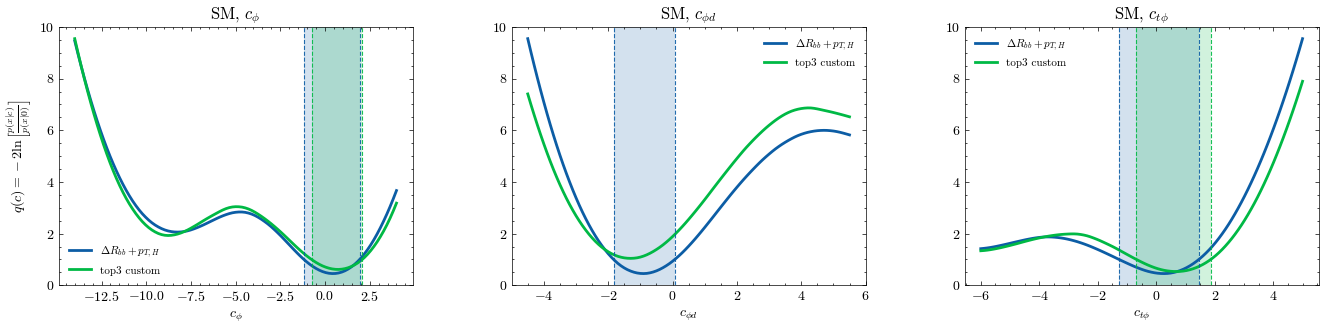

,row,column,group,coeff_index,coefficient,run_id,label,displayed_threshold,real_threshold,intervals
0,1,1,selected 2 observables vs top3 custom,0,$c_\phi$,m4b_pt_h_all,"$\Delta R_{bb}+p_{T,H}$",1.0,664.995264,"[(-1.1751385346248548, 1.937534573416835)]"
1,1,1,selected 2 observables vs top3 custom,0,$c_\phi$,top3_custom_all,top3 custom,1.0,664.995264,"[(-0.7491144642782707, 2.0814988440863536)]"
2,1,2,selected 2 observables vs top3 custom,1,$c_{\phi d}$,m4b_pt_h_all,"$\Delta R_{bb}+p_{T,H}$",1.0,176.535156,"[(-1.8306244577674728, 0.06764543094567552)]"
3,1,2,selected 2 observables vs top3 custom,1,$c_{\phi d}$,top3_custom_all,top3 custom,1.0,176.535156,[]
4,1,3,selected 2 observables vs top3 custom,2,$c_{t\phi}$,m4b_pt_h_all,"$\Delta R_{bb}+p_{T,H}$",1.0,358.745407,"[(-1.2711897641520207, 1.4532100521212283)]"
5,1,3,selected 2 observables vs top3 custom,2,$c_{t\phi}$,top3_custom_all,top3 custom,1.0,358.745407,"[(-0.6780725285034288, 1.8591563638961879)]"


In [77]:
# ============================================================
# Plot selected 2 observables vs custom top3 in one 1x3 figure
# with manual displayed-y thresholds and interval summary table
# ============================================================

COMPARISON_FIGSIZE = (14.0, 3.8)

COMPARISON_LEFT = 0.08
COMPARISON_RIGHT = 0.98
COMPARISON_BOTTOM = 0.18
COMPARISON_TOP = 0.86
COMPARISON_WSPACE = 0.28

COMPARISON_FAKE_Y_MIN = 0.0
COMPARISON_FAKE_Y_MAX = 10.0
COMPARISON_N_Y_TICKS = 6

SAVE_COMPARISON_SM_FIG = True
COMPARISON_SM_SAVE_PATH = "plots/07_observable_study/selected2_vs_top3custom_sm_1x3_threshold_ci.png"

COMPARISON_GROUP_LABEL = r"selected 2 observables vs top3 custom"

# ============================================================
# Manual displayed-y thresholds
# ============================================================
# coefficient_index:
# 0 = c_phi
# 1 = c_phid
# 2 = ctphi
#
# These threshold values are in the displayed 0--10 y-axis scale.
# Intervals are selected by displayed_y(c) <= displayed_threshold.

COMPARISON_MANUAL_Y_THRESHOLD_1D = {
    0: {
        "m4b_pt_h_all": 1.0,
        "top3_custom_all": 1.0,
    },
    1: {
        "m4b_pt_h_all": 1.0,
        "top3_custom_all": 1.0,
    },
    2: {
        "m4b_pt_h_all": 1.0,
        "top3_custom_all": 1.0,
    },
}


def fake_to_real_y(fake_y, real_ymin, real_ymax, fake_min=0.0, fake_max=10.0):
    fake_y = float(fake_y)

    return real_ymin + (fake_y - fake_min) / (fake_max - fake_min) * (real_ymax - real_ymin)


def interpolate_crossing(x0, y0, x1, y1, threshold):
    if y1 == y0:
        return x0

    return x0 + (threshold - y0) * (x1 - x0) / (y1 - y0)


def intervals_below_threshold(x, y, threshold):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    valid = np.isfinite(x) & np.isfinite(y)

    x = x[valid]
    y = y[valid]

    inside = y <= threshold
    intervals = []

    if not np.any(inside):
        return intervals

    start = None

    for i in range(len(x)):
        if inside[i] and start is None:
            if i == 0:
                start = x[i]
            else:
                start = interpolate_crossing(
                    x[i - 1],
                    y[i - 1],
                    x[i],
                    y[i],
                    threshold,
                )

        if inside[i] and (i == len(x) - 1 or not inside[i + 1]):
            if i == len(x) - 1:
                end = x[i]
            else:
                end = interpolate_crossing(
                    x[i],
                    y[i],
                    x[i + 1],
                    y[i + 1],
                    threshold,
                )

            intervals.append((float(start), float(end)))
            start = None

    return intervals


def apply_display_y_axis_labels(ax, fake_min=0.0, fake_max=10.0, n_ticks=6):
    real_ymin, real_ymax = ax.get_ylim()

    real_ticks = np.linspace(real_ymin, real_ymax, n_ticks)
    fake_labels = np.linspace(fake_min, fake_max, n_ticks)

    ax.set_yticks(real_ticks)
    ax.set_yticklabels([f"{v:.0f}" for v in fake_labels])


def plot_comparison_sm_1x3_with_threshold_ci(
    comparison_sm_results,
    manual_y_threshold_dict,
    save=True,
):
    os.makedirs("plots/07_observable_study", exist_ok=True)

    fig, axes = plt.subplots(
        1,
        3,
        figsize=COMPARISON_FIGSIZE,
        sharex=False,
        sharey=False,
    )

    interval_summary = []

    for col_idx, coeff_index in enumerate([0, 1, 2]):
        ax = axes[col_idx]

        curve_store = []

        for spec in COMPARISON_MODEL_SPECS:
            label = spec["label"]
            run_id = spec["run_id"]

            scan_result = comparison_sm_results[label]["scans"][coeff_index]

            x = get_axis_values_for_1d(
                scan_result,
                coeff_index,
                plot_unscaled=PLOT_X_UNSCALED,
            )

            q_c = np.asarray(scan_result["q_total_raw"], dtype=float)

            y = -q_c

            line, = ax.plot(
                x,
                y,
                lw=2,
                label=label,
            )

            curve_store.append(
                {
                    "label": label,
                    "run_id": run_id,
                    "x": x,
                    "y": y,
                    "color": line.get_color(),
                }
            )

        real_ymin, real_ymax = ax.get_ylim()

        for curve in curve_store:
            run_id = curve["run_id"]
            label = curve["label"]
            x = curve["x"]
            y = curve["y"]
            color = curve["color"]

            displayed_threshold = manual_y_threshold_dict.get(coeff_index, {}).get(run_id, None)

            if displayed_threshold is None:
                continue

            real_threshold = fake_to_real_y(
                displayed_threshold,
                real_ymin,
                real_ymax,
                fake_min=COMPARISON_FAKE_Y_MIN,
                fake_max=COMPARISON_FAKE_Y_MAX,
            )

            intervals = intervals_below_threshold(
                x,
                y,
                real_threshold,
            )

            interval_summary.append(
                {
                    "row": 1,
                    "column": col_idx + 1,
                    "group": COMPARISON_GROUP_LABEL,
                    "coeff_index": coeff_index,
                    "coefficient": WILSON_LABELS[coeff_index],
                    "run_id": run_id,
                    "label": label,
                    "displayed_threshold": displayed_threshold,
                    "real_threshold": real_threshold,
                    "intervals": intervals,
                }
            )

            print(
                "threshold CI:",
                "row =", 1,
                "| column =", col_idx + 1,
                "| coeff =", coeff_index,
                "| run_id =", run_id,
                "| displayed threshold =", displayed_threshold,
                "| real threshold =", real_threshold,
                "| intervals =", intervals,
            )

            for lo, hi in intervals:
                ax.axvspan(
                    lo,
                    hi,
                    color=color,
                    alpha=0.18,
                    linewidth=0,
                )

                ax.axvline(
                    lo,
                    color=color,
                    ls="--",
                    lw=0.8,
                    alpha=0.9,
                )

                ax.axvline(
                    hi,
                    color=color,
                    ls="--",
                    lw=0.8,
                    alpha=0.9,
                )

        ax.set_title(
            rf"SM, {WILSON_LABELS[coeff_index]}",
            fontsize=12,
        )

        ax.set_xlabel(
            get_coeff_label(
                coeff_index,
                plot_unscaled=PLOT_X_UNSCALED,
            ),
            fontsize=10,
        )

        if col_idx == 0:
            ax.set_ylabel(
                r"$q(c)=-2\ln\left[\frac{p(x|c)}{p(x|0)}\right]$",
                fontsize=10,
            )

        ax.legend(fontsize=8)

        apply_display_y_axis_labels(
            ax,
            fake_min=COMPARISON_FAKE_Y_MIN,
            fake_max=COMPARISON_FAKE_Y_MAX,
            n_ticks=COMPARISON_N_Y_TICKS,
        )

    fig.subplots_adjust(
        left=COMPARISON_LEFT,
        right=COMPARISON_RIGHT,
        bottom=COMPARISON_BOTTOM,
        top=COMPARISON_TOP,
        wspace=COMPARISON_WSPACE,
    )

    if save:
        fig.savefig(
            COMPARISON_SM_SAVE_PATH,
            dpi=300,
            bbox_inches="tight",
        )

        print("Saved:", COMPARISON_SM_SAVE_PATH)

    plt.show()

    return interval_summary


comparison_threshold_interval_summaries = plot_comparison_sm_1x3_with_threshold_ci(
    comparison_sm_results,
    manual_y_threshold_dict=COMPARISON_MANUAL_Y_THRESHOLD_1D,
    save=SAVE_COMPARISON_SM_FIG,
)

comparison_threshold_interval_df = pd.DataFrame(comparison_threshold_interval_summaries)

display(comparison_threshold_interval_df)

comparison_threshold_interval_df.to_csv(
    "plots/07_observable_study/selected2_vs_top3custom_manual_threshold_interval_summary.csv",
    index=False,
)

In [80]:
# ============================================================
# BSM 1D inference:
# selected 2 observables vs top3 custom
# Test points: cp_m50, ctp_m10, cdp_m20
#
# IMPORTANT:
# Here the displayed / scanned Wilson coordinates are:
# cp_m50  -> c_phi  = -5
# ctp_m10 -> ctphi  = -1
# cdp_m20 -> c_phid = -2
#
# The MadMiner / rate coordinate is 10 times this value.
# evaluate_scan_raw() already uses 10 * c_grid internally for rate.
# ============================================================

BSM_INFERENCE_MODEL_SPECS = [
    {
        "label": r"selected 2 observables",
        "run_id": "m4b_pt_h_all",
        "model_dir": f"{MODEL_BACKUP_DIR}/m4b_pt_h",
    },
    {
        "label": r"top3 custom",
        "run_id": "top3_custom_all",
        "model_dir": f"{MODEL_BACKUP_DIR}/top3_custom",
    },
]

# ------------------------------------------------------------
# BSM points in displayed / network coordinates
# ------------------------------------------------------------

BSM_INFERENCE_POINTS = {
    "cp_m50": {
        "title": r"$c_\phi=-5$",
        "true_c_plot": (-5.0, 0.0, 0.0),
        "scan_index": 0,
        "scan_range_plot": (-6.5, 2.5),
    },
    "ctp_m10": {
        "title": r"$c_{t\phi}=-1$",
        "true_c_plot": (0.0, 0.0, -1.0),
        "scan_index": 2,
        "scan_range_plot": (-1.5, 4.5),
    },
    "cdp_m20": {
        "title": r"$c_{\phi d}=-2$",
        "true_c_plot": (0.0, -2.0, 0.0),
        "scan_index": 1,
        "scan_range_plot": (-2.5, 3.5),
    },
}

BSM_TEST_CODES_TO_PLOT = ["cp_m50", "ctp_m10", "cdp_m20"]

N_SCAN_BSM_1D = 121

FORCE_RECOMPUTE_BSM_INFERENCE = True
bsm_inference_cache_path = "preplot_pickles/07_bsm_selected2_vs_top3custom_1d_scans_scaledcoords.pkl"

os.makedirs("preplot_pickles", exist_ok=True)
os.makedirs("plots/07_observable_study", exist_ok=True)


def make_bsm_scan_limits_from_plot_coords(scan_index, scan_range_plot):
    lower_limits_local = list(lower_limits_scaled)
    upper_limits_local = list(upper_limits_scaled)

    lower_limits_local[scan_index] = scan_range_plot[0]
    upper_limits_local[scan_index] = scan_range_plot[1]

    return lower_limits_local, upper_limits_local


if os.path.exists(bsm_inference_cache_path) and not FORCE_RECOMPUTE_BSM_INFERENCE:
    with open(bsm_inference_cache_path, "rb") as file:
        bsm_inference_results = pickle.load(file)

    print("Loaded cached BSM inference results from:", bsm_inference_cache_path)

else:
    bsm_inference_results = {}

    for test_code in BSM_TEST_CODES_TO_PLOT:
        point_info = BSM_INFERENCE_POINTS[test_code]

        true_c_plot = np.array(point_info["true_c_plot"], dtype=float)
        true_c_madminer = tuple(10.0 * true_c_plot)

        scan_index = point_info["scan_index"]
        scan_range_plot = point_info["scan_range_plot"]

        lower_limits_bsm, upper_limits_bsm = make_bsm_scan_limits_from_plot_coords(
            scan_index,
            scan_range_plot,
        )

        bsm_inference_results[test_code] = {
            "point_info": point_info,
            "models": {},
        }

        print("\n" + "=" * 100)
        print("BSM test point:", test_code)
        print("true_c_plot:", true_c_plot)
        print("true_c_madminer:", true_c_madminer)
        print("scan_index:", scan_index)
        print("scan_range_plot:", scan_range_plot)
        print("lower_limits_bsm:", lower_limits_bsm)
        print("upper_limits_bsm:", upper_limits_bsm)

        for spec in BSM_INFERENCE_MODEL_SPECS:
            label = spec["label"]
            run_id = spec["run_id"]
            model_dir = spec["model_dir"]

            print("\n" + "-" * 100)
            print("Running model:", label)
            print("run_id:", run_id)
            print("model_dir:", model_dir)

            bundle = load_model_bundle(
                run_id,
                device,
                model_dir=model_dir,
            )

            pseudo_bsm = build_pseudo_data(
                bundle,
                true_code=test_code,
                true_c_unscaled=true_c_madminer,
                N_sig_SM_target=N_sig_SM_target,
                N_bkg_SM_target=N_bkg_SM_target,
                random_state=7,
            )

            scan_result = evaluate_scan_raw(
                bundle,
                pseudo_bsm,
                scan_indices=str(scan_index),
                n_scan_points=N_SCAN_BSM_1D,
                lower_limits_scaled=lower_limits_bsm,
                upper_limits_scaled=upper_limits_bsm,
                N_sig_SM_target=N_sig_SM_target,
                N_bkg_SM_target=N_bkg_SM_target,
            )

            bsm_inference_results[test_code]["models"][label] = {
                "spec": spec,
                "run_id": run_id,
                "model_dir": model_dir,
                "features": bundle["features"],
                "parameter_code": bundle["parameter_code"],
                "network_id": bundle["network_id"],
                "scan_result": scan_result,
            }

            q_c = np.asarray(scan_result["q_total_raw"], dtype=float)

            print("q_total_raw shape:", q_c.shape)
            print("plotted y min:", np.min(-q_c), "plotted y max:", np.max(-q_c))

            with open(bsm_inference_cache_path, "wb") as file:
                pickle.dump(bsm_inference_results, file)

            print("Intermediate result saved to:", bsm_inference_cache_path)

    print("\nDone.")
    print("Saved BSM inference results to:", bsm_inference_cache_path)


BSM test point: cp_m50
true_c_plot: [-5.  0.  0.]
true_c_madminer: (-50.0, 0.0, 0.0)
scan_index: 0
scan_range_plot: (-6.5, 2.5)
lower_limits_bsm: [-6.5, -0.45, -0.6]
upper_limits_bsm: [2.5, 0.55, 0.5]

----------------------------------------------------------------------------------------------------
Running model: selected 2 observables
run_id: m4b_pt_h_all
model_dir: /vols/cms/jl3222/model_backup/m4b_pt_h
Loading run config: /home/hep/jl3222/projects/nsbi_photon_final_state/run_configs/m4b_pt_h/m4b_pt_h_all.yml
Loading scaler: /vols/cms/jl3222/model_backup/m4b_pt_h/scaler_m4b_pt_h_all.pkl
Loading model: /vols/cms/jl3222/model_backup/m4b_pt_h/m4b_pt_h_all_Ssm_Salt_best_model.pt
Loading model: /vols/cms/jl3222/model_backup/m4b_pt_h/m4b_pt_h_all_B_Salt_best_model.pt
Loading model: /vols/cms/jl3222/model_backup/m4b_pt_h/m4b_pt_h_all_Ssm_B_best_model.pt
Loaded run_id=m4b_pt_h_all, model_dir=/vols/cms/jl3222/model_backup/m4b_pt_h, network_id=m4b_pt_h_all, parameter_code=c2, features=[25,

/home/hep/jl3222/projects/nsbi_photon_final_state/helpers/test_statistics.py:242: RuntimeWarning: divide by zero encountered in divide
  comp_3  = np.array([(f_sig_SM / (1.0 - f_sig_alt[i]))*(1.0/lr_B_to_S_SM[:]) for i in range(N_c_points)])  # shape: (# c points, # test points, 1)


q_total_raw shape: (121,)
plotted y min: -1438326.218998326 plotted y max: 703093.7651286407
Intermediate result saved to: preplot_pickles/07_bsm_selected2_vs_top3custom_1d_scans_scaledcoords.pkl

----------------------------------------------------------------------------------------------------
Running model: top3 custom
run_id: top3_custom_all
model_dir: /vols/cms/jl3222/model_backup/top3_custom
Loading run config: /home/hep/jl3222/projects/nsbi_photon_final_state/run_configs/top3_custom/top3_custom_all.yml
Loading scaler: /vols/cms/jl3222/model_backup/top3_custom/scaler_top3_custom_all.pkl
Loading model: /vols/cms/jl3222/model_backup/top3_custom/top3_custom_all_Ssm_Salt_best_model.pt
Loading model: /vols/cms/jl3222/model_backup/top3_custom/top3_custom_all_B_Salt_best_model.pt
Loading model: /vols/cms/jl3222/model_backup/top3_custom/top3_custom_all_Ssm_B_best_model.pt
Loaded run_id=top3_custom_all, model_dir=/vols/cms/jl3222/model_backup/top3_custom, network_id=top3_custom_all, para

/home/hep/jl3222/projects/nsbi_photon_final_state/helpers/test_statistics.py:242: RuntimeWarning: divide by zero encountered in divide
  comp_3  = np.array([(f_sig_SM / (1.0 - f_sig_alt[i]))*(1.0/lr_B_to_S_SM[:]) for i in range(N_c_points)])  # shape: (# c points, # test points, 1)


q_total_raw shape: (121,)
plotted y min: -1055.617141229135 plotted y max: 483336.61767598207
Intermediate result saved to: preplot_pickles/07_bsm_selected2_vs_top3custom_1d_scans_scaledcoords.pkl

----------------------------------------------------------------------------------------------------
Running model: top3 custom
run_id: top3_custom_all
model_dir: /vols/cms/jl3222/model_backup/top3_custom
Loading run config: /home/hep/jl3222/projects/nsbi_photon_final_state/run_configs/top3_custom/top3_custom_all.yml
Loading scaler: /vols/cms/jl3222/model_backup/top3_custom/scaler_top3_custom_all.pkl
Loading model: /vols/cms/jl3222/model_backup/top3_custom/top3_custom_all_Ssm_Salt_best_model.pt
Loading model: /vols/cms/jl3222/model_backup/top3_custom/top3_custom_all_B_Salt_best_model.pt
Loading model: /vols/cms/jl3222/model_backup/top3_custom/top3_custom_all_Ssm_B_best_model.pt
Loaded run_id=top3_custom_all, model_dir=/vols/cms/jl3222/model_backup/top3_custom, network_id=top3_custom_all, par

/home/hep/jl3222/projects/nsbi_photon_final_state/helpers/test_statistics.py:242: RuntimeWarning: divide by zero encountered in divide
  comp_3  = np.array([(f_sig_SM / (1.0 - f_sig_alt[i]))*(1.0/lr_B_to_S_SM[:]) for i in range(N_c_points)])  # shape: (# c points, # test points, 1)


q_total_raw shape: (121,)
plotted y min: -87275.5780766979 plotted y max: 82577.27575300995
Intermediate result saved to: preplot_pickles/07_bsm_selected2_vs_top3custom_1d_scans_scaledcoords.pkl

----------------------------------------------------------------------------------------------------
Running model: top3 custom
run_id: top3_custom_all
model_dir: /vols/cms/jl3222/model_backup/top3_custom
Loading run config: /home/hep/jl3222/projects/nsbi_photon_final_state/run_configs/top3_custom/top3_custom_all.yml
Loading scaler: /vols/cms/jl3222/model_backup/top3_custom/scaler_top3_custom_all.pkl
Loading model: /vols/cms/jl3222/model_backup/top3_custom/top3_custom_all_Ssm_Salt_best_model.pt
Loading model: /vols/cms/jl3222/model_backup/top3_custom/top3_custom_all_B_Salt_best_model.pt
Loading model: /vols/cms/jl3222/model_backup/top3_custom/top3_custom_all_Ssm_B_best_model.pt
Loaded run_id=top3_custom_all, model_dir=/vols/cms/jl3222/model_backup/top3_custom, network_id=top3_custom_all, param

Saved: plots/07_observable_study/bsm_selected2_vs_top3custom_1x3_scaledcoords.png


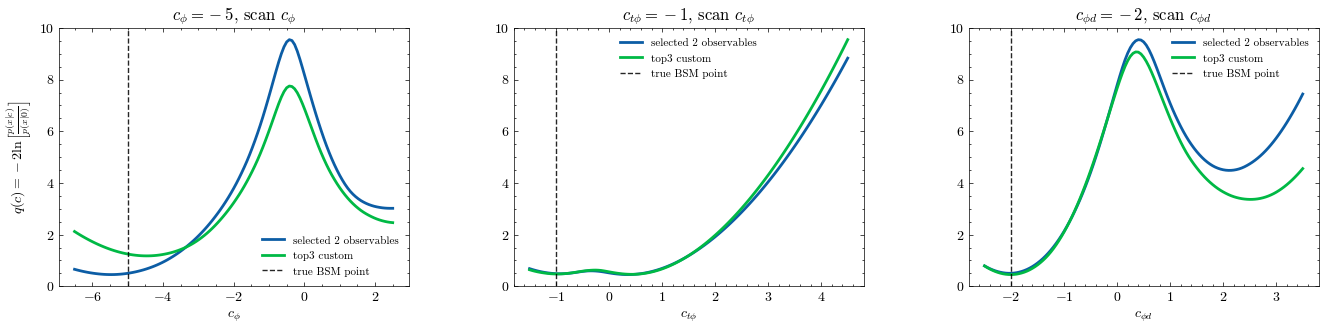

In [81]:
# ============================================================
# Plot BSM inference in one 1 x 3 figure
# ============================================================

BSM_FIGSIZE = (14.0, 3.8)

BSM_LEFT = 0.08
BSM_RIGHT = 0.98
BSM_BOTTOM = 0.18
BSM_TOP = 0.86
BSM_WSPACE = 0.30

BSM_FAKE_Y_MIN = 0.0
BSM_FAKE_Y_MAX = 10.0
BSM_N_Y_TICKS = 6

DRAW_TRUE_POINT_LINE = True

SAVE_BSM_INFERENCE_FIG = True
BSM_INFERENCE_SAVE_PATH = "plots/07_observable_study/bsm_selected2_vs_top3custom_1x3_scaledcoords.png"


def apply_display_y_axis_labels(ax, fake_min=0.0, fake_max=10.0, n_ticks=6):
    real_ymin, real_ymax = ax.get_ylim()

    real_ticks = np.linspace(real_ymin, real_ymax, n_ticks)
    fake_labels = np.linspace(fake_min, fake_max, n_ticks)

    ax.set_yticks(real_ticks)
    ax.set_yticklabels([f"{v:.0f}" for v in fake_labels])


def get_bsm_axis_label(coeff_index):
    return WILSON_LABELS[coeff_index]


def plot_bsm_inference_1x3(
    bsm_inference_results,
    save=True,
):
    fig, axes = plt.subplots(
        1,
        3,
        figsize=BSM_FIGSIZE,
        sharex=False,
        sharey=False,
    )

    for col_idx, test_code in enumerate(BSM_TEST_CODES_TO_PLOT):
        ax = axes[col_idx]

        point_info = bsm_inference_results[test_code]["point_info"]

        scan_index = point_info["scan_index"]
        true_c_plot = np.array(point_info["true_c_plot"], dtype=float)
        true_value_plot = true_c_plot[scan_index]

        for spec in BSM_INFERENCE_MODEL_SPECS:
            label = spec["label"]

            scan_result = bsm_inference_results[test_code]["models"][label]["scan_result"]

            x = get_axis_values_for_1d(
                scan_result,
                scan_index,
                plot_unscaled=False,
            )

            q_c = np.asarray(scan_result["q_total_raw"], dtype=float)

            y = -q_c

            ax.plot(
                x,
                y,
                lw=2,
                label=label,
            )

        if DRAW_TRUE_POINT_LINE:
            ax.axvline(
                true_value_plot,
                color="black",
                ls="--",
                lw=1.0,
                alpha=0.85,
                label="true BSM point",
            )

        ax.set_title(
            rf"{point_info['title']}, scan {WILSON_LABELS[scan_index]}",
            fontsize=12,
        )

        ax.set_xlabel(
            get_bsm_axis_label(scan_index),
            fontsize=10,
        )

        if col_idx == 0:
            ax.set_ylabel(
                r"$q(c)=-2\ln\left[\frac{p(x|c)}{p(x|0)}\right]$",
                fontsize=10,
            )

        ax.legend(fontsize=8)

        apply_display_y_axis_labels(
            ax,
            fake_min=BSM_FAKE_Y_MIN,
            fake_max=BSM_FAKE_Y_MAX,
            n_ticks=BSM_N_Y_TICKS,
        )

    fig.subplots_adjust(
        left=BSM_LEFT,
        right=BSM_RIGHT,
        bottom=BSM_BOTTOM,
        top=BSM_TOP,
        wspace=BSM_WSPACE,
    )

    if save:
        fig.savefig(
            BSM_INFERENCE_SAVE_PATH,
            dpi=300,
            bbox_inches="tight",
        )

        print("Saved:", BSM_INFERENCE_SAVE_PATH)

    plt.show()


plot_bsm_inference_1x3(
    bsm_inference_results,
    save=SAVE_BSM_INFERENCE_FIG,
)

threshold CI: column = 1 | test_code = cp_m50 | scan_index = 0 | run_id = m4b_pt_h_all | displayed threshold = 1.0 | real threshold = -1309841.019950708 | intervals = [(-6.5, -3.909815883707272)]
threshold CI: column = 1 | test_code = cp_m50 | scan_index = 0 | run_id = top3_custom_all | displayed threshold = 1.0 | real threshold = -1309841.019950708 | intervals = []
threshold CI: column = 2 | test_code = ctp_m10 | scan_index = 2 | run_id = m4b_pt_h_all | displayed threshold = 1.0 | real threshold = 30488.12798295979 | intervals = [(-1.5, 1.3389189526192153)]
threshold CI: column = 2 | test_code = ctp_m10 | scan_index = 2 | run_id = top3_custom_all | displayed threshold = 1.0 | real threshold = 30488.12798295979 | intervals = [(-1.5, 1.346099178477583)]
threshold CI: column = 3 | test_code = cdp_m20 | scan_index = 1 | run_id = m4b_pt_h_all | displayed threshold = 1.0 | real threshold = -77964.2057962101 | intervals = [(-2.5, -1.440758053853084)]
threshold CI: column = 3 | test_code = cd

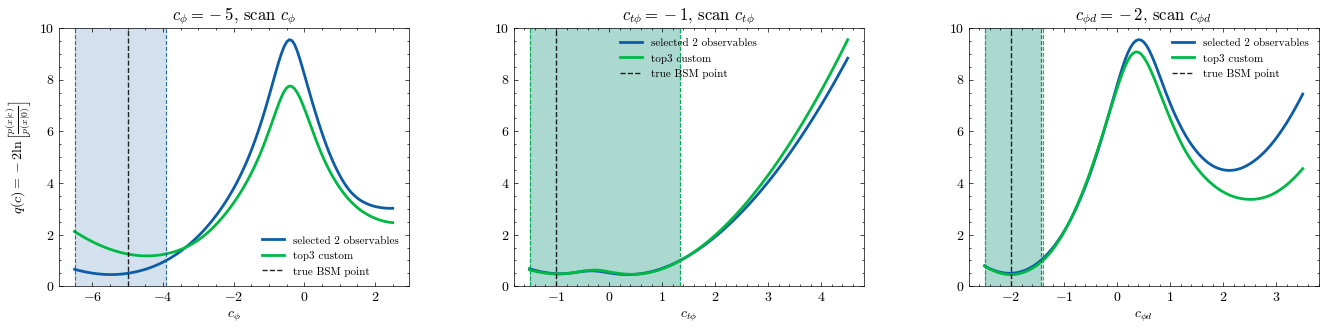

,column,test_code,true_point,scan_index,coefficient,run_id,label,displayed_threshold,real_threshold,intervals
0,1,cp_m50,$c_\phi=-5$,0,$c_\phi$,m4b_pt_h_all,selected 2 observables,1.0,-1.309841e+06,"[(-6.5, -3.909815883707272)]"
1,1,cp_m50,$c_\phi=-5$,0,$c_\phi$,top3_custom_all,top3 custom,1.0,-1.309841e+06,[]
2,2,ctp_m10,$c_{t\phi}=-1$,2,$c_{t\phi}$,m4b_pt_h_all,selected 2 observables,1.0,3.048813e+04,"[(-1.5, 1.3389189526192153)]"
3,2,ctp_m10,$c_{t\phi}=-1$,2,$c_{t\phi}$,top3_custom_all,top3 custom,1.0,3.048813e+04,"[(-1.5, 1.346099178477583)]"
4,3,cdp_m20,$c_{\phi d}=-2$,1,$c_{\phi d}$,m4b_pt_h_all,selected 2 observables,1.0,-7.796421e+04,"[(-2.5, -1.440758053853084)]"
5,3,cdp_m20,$c_{\phi d}=-2$,1,$c_{\phi d}$,top3_custom_all,top3 custom,1.0,-7.796421e+04,"[(-2.5, -1.4004609318561099)]"


In [82]:
# ============================================================
# BSM 1D inference with manual displayed-y thresholds
# selected 2 observables vs top3 custom
# ============================================================

BSM_MANUAL_Y_THRESHOLD_1D = {
    "cp_m50": {
        "m4b_pt_h_all": 1.0,
        "top3_custom_all": 1.0,
    },
    "ctp_m10": {
        "m4b_pt_h_all": 1.0,
        "top3_custom_all": 1.0,
    },
    "cdp_m20": {
        "m4b_pt_h_all": 1.0,
        "top3_custom_all": 1.0,
    },
}

BSM_THRESHOLD_FIGSIZE = (14.0, 3.8)

BSM_THRESHOLD_LEFT = 0.08
BSM_THRESHOLD_RIGHT = 0.98
BSM_THRESHOLD_BOTTOM = 0.18
BSM_THRESHOLD_TOP = 0.86
BSM_THRESHOLD_WSPACE = 0.30

BSM_THRESHOLD_FAKE_Y_MIN = 0.0
BSM_THRESHOLD_FAKE_Y_MAX = 10.0
BSM_THRESHOLD_N_Y_TICKS = 6

DRAW_TRUE_POINT_LINE = True

SAVE_BSM_THRESHOLD_FIG = True
BSM_THRESHOLD_SAVE_PATH = "plots/07_observable_study/bsm_selected2_vs_top3custom_1x3_threshold_ci.png"


def fake_to_real_y(fake_y, real_ymin, real_ymax, fake_min=0.0, fake_max=10.0):
    fake_y = float(fake_y)

    return real_ymin + (fake_y - fake_min) / (fake_max - fake_min) * (real_ymax - real_ymin)


def interpolate_crossing(x0, y0, x1, y1, threshold):
    if y1 == y0:
        return x0

    return x0 + (threshold - y0) * (x1 - x0) / (y1 - y0)


def intervals_below_threshold(x, y, threshold):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    valid = np.isfinite(x) & np.isfinite(y)
    x = x[valid]
    y = y[valid]

    inside = y <= threshold
    intervals = []

    if not np.any(inside):
        return intervals

    start = None

    for i in range(len(x)):
        if inside[i] and start is None:
            if i == 0:
                start = x[i]
            else:
                start = interpolate_crossing(
                    x[i - 1],
                    y[i - 1],
                    x[i],
                    y[i],
                    threshold,
                )

        if inside[i] and (i == len(x) - 1 or not inside[i + 1]):
            if i == len(x) - 1:
                end = x[i]
            else:
                end = interpolate_crossing(
                    x[i],
                    y[i],
                    x[i + 1],
                    y[i + 1],
                    threshold,
                )

            intervals.append((float(start), float(end)))
            start = None

    return intervals


def apply_display_y_axis_labels(ax, fake_min=0.0, fake_max=10.0, n_ticks=6):
    real_ymin, real_ymax = ax.get_ylim()

    real_ticks = np.linspace(real_ymin, real_ymax, n_ticks)
    fake_labels = np.linspace(fake_min, fake_max, n_ticks)

    ax.set_yticks(real_ticks)
    ax.set_yticklabels([f"{v:.0f}" for v in fake_labels])


def plot_bsm_inference_1x3_with_threshold_ci(
    bsm_inference_results,
    manual_y_threshold_dict,
    save=True,
):
    os.makedirs("plots/07_observable_study", exist_ok=True)

    fig, axes = plt.subplots(
        1,
        3,
        figsize=BSM_THRESHOLD_FIGSIZE,
        sharex=False,
        sharey=False,
    )

    interval_summary = []

    for col_idx, test_code in enumerate(BSM_TEST_CODES_TO_PLOT):
        ax = axes[col_idx]

        point_info = bsm_inference_results[test_code]["point_info"]

        scan_index = point_info["scan_index"]
        true_c_plot = np.array(point_info["true_c_plot"], dtype=float)
        true_value_plot = true_c_plot[scan_index]

        curve_store = []

        for spec in BSM_INFERENCE_MODEL_SPECS:
            label = spec["label"]
            run_id = spec["run_id"]

            scan_result = bsm_inference_results[test_code]["models"][label]["scan_result"]

            x = get_axis_values_for_1d(
                scan_result,
                scan_index,
                plot_unscaled=False,
            )

            q_c = np.asarray(scan_result["q_total_raw"], dtype=float)

            y = -q_c

            line, = ax.plot(
                x,
                y,
                lw=2,
                label=label,
            )

            curve_store.append(
                {
                    "test_code": test_code,
                    "label": label,
                    "run_id": run_id,
                    "x": x,
                    "y": y,
                    "color": line.get_color(),
                }
            )

        if DRAW_TRUE_POINT_LINE:
            ax.axvline(
                true_value_plot,
                color="black",
                ls="--",
                lw=1.0,
                alpha=0.85,
                label="true BSM point",
            )

        real_ymin, real_ymax = ax.get_ylim()

        for curve in curve_store:
            run_id = curve["run_id"]
            label = curve["label"]
            x = curve["x"]
            y = curve["y"]
            color = curve["color"]

            displayed_threshold = manual_y_threshold_dict.get(test_code, {}).get(run_id, None)

            if displayed_threshold is None:
                continue

            real_threshold = fake_to_real_y(
                displayed_threshold,
                real_ymin,
                real_ymax,
                fake_min=BSM_THRESHOLD_FAKE_Y_MIN,
                fake_max=BSM_THRESHOLD_FAKE_Y_MAX,
            )

            intervals = intervals_below_threshold(
                x,
                y,
                real_threshold,
            )

            interval_summary.append(
                {
                    "column": col_idx + 1,
                    "test_code": test_code,
                    "true_point": point_info["title"],
                    "scan_index": scan_index,
                    "coefficient": WILSON_LABELS[scan_index],
                    "run_id": run_id,
                    "label": label,
                    "displayed_threshold": displayed_threshold,
                    "real_threshold": real_threshold,
                    "intervals": intervals,
                }
            )

            print(
                "threshold CI:",
                "column =", col_idx + 1,
                "| test_code =", test_code,
                "| scan_index =", scan_index,
                "| run_id =", run_id,
                "| displayed threshold =", displayed_threshold,
                "| real threshold =", real_threshold,
                "| intervals =", intervals,
            )

            for lo, hi in intervals:
                ax.axvspan(
                    lo,
                    hi,
                    color=color,
                    alpha=0.18,
                    linewidth=0,
                )

                ax.axvline(
                    lo,
                    color=color,
                    ls="--",
                    lw=0.8,
                    alpha=0.9,
                )

                ax.axvline(
                    hi,
                    color=color,
                    ls="--",
                    lw=0.8,
                    alpha=0.9,
                )

        ax.set_title(
            rf"{point_info['title']}, scan {WILSON_LABELS[scan_index]}",
            fontsize=12,
        )

        ax.set_xlabel(
            WILSON_LABELS[scan_index],
            fontsize=10,
        )

        if col_idx == 0:
            ax.set_ylabel(
                r"$q(c)=-2\ln\left[\frac{p(x|c)}{p(x|0)}\right]$",
                fontsize=10,
            )

        ax.legend(fontsize=8)

        apply_display_y_axis_labels(
            ax,
            fake_min=BSM_THRESHOLD_FAKE_Y_MIN,
            fake_max=BSM_THRESHOLD_FAKE_Y_MAX,
            n_ticks=BSM_THRESHOLD_N_Y_TICKS,
        )

    fig.subplots_adjust(
        left=BSM_THRESHOLD_LEFT,
        right=BSM_THRESHOLD_RIGHT,
        bottom=BSM_THRESHOLD_BOTTOM,
        top=BSM_THRESHOLD_TOP,
        wspace=BSM_THRESHOLD_WSPACE,
    )

    if save:
        fig.savefig(
            BSM_THRESHOLD_SAVE_PATH,
            dpi=300,
            bbox_inches="tight",
        )

        print("Saved:", BSM_THRESHOLD_SAVE_PATH)

    plt.show()

    return interval_summary


bsm_threshold_interval_summaries = plot_bsm_inference_1x3_with_threshold_ci(
    bsm_inference_results,
    manual_y_threshold_dict=BSM_MANUAL_Y_THRESHOLD_1D,
    save=SAVE_BSM_THRESHOLD_FIG,
)

bsm_threshold_interval_df = pd.DataFrame(bsm_threshold_interval_summaries)

display(bsm_threshold_interval_df)

bsm_threshold_interval_df.to_csv(
    "plots/07_observable_study/bsm_selected2_vs_top3custom_manual_threshold_interval_summary.csv",
    index=False,
)

In [2]:
import os
import glob
import yaml
import pickle
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from sklearn.utils import shuffle

try:
    import scienceplots
    plt.style.use(["science", "no-latex"])
except Exception:
    pass

plt.rcParams["text.usetex"] = False

from helpers.likelihood_visualizers import make_c_grid
from helpers.test_statistics import (
    get_test_statistic_rate_at_c_points,
    get_N_sig_obs_at_c_point,
    eval_test_statistic_shape_mixture_model_4_comp_ensemble,
)
from helpers.network_training import NeuralNet


torch.set_num_threads(2)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


# ============================================================
# Paths
# ============================================================

RUN_CONFIG_DIR = "/home/hep/jl3222/projects/nsbi_photon_final_state/run_configs"
MODEL_BACKUP_DIR = "/vols/cms/jl3222/model_backup"
PROJECT_MODEL_DIR = "/vols/cms/jl3222/nsbi_photon_final_state/models"

with open("workflow.yaml", "r") as file:
    workflow = yaml.safe_load(file)

samples_dir = workflow["sampling"]["output_dir"]

# Do not use workflow["sampling"]["input_dir"] if it points to old 04_post_delphes.
data_input_dir = "/vols/cms/jl3222/nsbi_backups/combined_samples"

print("RUN_CONFIG_DIR =", RUN_CONFIG_DIR)
print("MODEL_BACKUP_DIR =", MODEL_BACKUP_DIR)
print("PROJECT_MODEL_DIR =", PROJECT_MODEL_DIR)
print("samples_dir =", samples_dir)
print("data_input_dir =", data_input_dir)


# ============================================================
# Global settings
# ============================================================

N_sig_SM_target = 3600
N_bkg_SM_target = 8160

lower_limits_scaled = [-1.4, -0.45, -0.6]
upper_limits_scaled = [0.4, 0.55, 0.5]

PLOT_X_UNSCALED = False

WILSON_LABELS = {
    0: r"$c_\phi$",
    1: r"$c_{\phi d}$",
    2: r"$c_{t\phi}$",
}


# ============================================================
# Utility functions
# ============================================================

def find_run_config_path(run_id, config_dir=RUN_CONFIG_DIR):
    candidates = []

    candidates.extend(glob.glob(f"{config_dir}/{run_id}.yml"))
    candidates.extend(glob.glob(f"{config_dir}/{run_id}.yaml"))
    candidates.extend(glob.glob(f"{config_dir}/**/{run_id}.yml", recursive=True))
    candidates.extend(glob.glob(f"{config_dir}/**/{run_id}.yaml", recursive=True))

    candidates = sorted(list(set(candidates)))

    if len(candidates) == 0:
        raise FileNotFoundError(
            f"Could not find run config for run_id={run_id} under {config_dir}"
        )

    if len(candidates) > 1:
        raise RuntimeError(
            f"Found multiple run configs for run_id={run_id}:\n" + "\n".join(candidates)
        )

    return candidates[0]


def load_yaml(path):
    with open(path, "r") as file:
        return yaml.safe_load(file)


def load_scaler(network_id, model_dir="models"):
    candidates = [
        f"{model_dir}/scaler_{network_id}.pkl",
        f"{model_dir}/scaler_{network_id}",
        f"{PROJECT_MODEL_DIR}/scaler_{network_id}.pkl",
        f"{PROJECT_MODEL_DIR}/scaler_{network_id}",
        f"models/scaler_{network_id}.pkl",
        f"models/scaler_{network_id}",
    ]

    for path in candidates:
        if os.path.exists(path):
            print("Loading scaler:", path)
            with open(path, "rb") as ifile:
                return pickle.load(ifile)

    raise FileNotFoundError(
        f"Could not find scaler for network_id={network_id}. Tried:\n" + "\n".join(candidates)
    )


def safe_torch_load(path, device):
    try:
        return torch.load(path, map_location=device, weights_only=False)
    except TypeError:
        return torch.load(path, map_location=device)


def load_model_bundle(run_id, device, model_dir="models", config_dir=RUN_CONFIG_DIR):
    run_config_path = find_run_config_path(run_id, config_dir=config_dir)
    print("Loading run config:", run_config_path)

    run_configs = load_yaml(run_config_path)

    identity_code = run_configs["input_precode"]
    parameter_code = run_configs["parameter_code"]
    network_id = run_configs["network_id"]
    features = run_configs["features"]
    n_features = len(features)

    scaler = load_scaler(network_id, model_dir=model_dir)

    networks = {
        0: {
            "Ssm_Salt": NeuralNet(n_inputs=n_features + 3, layers=run_configs["network.layers"]),
            "B_Salt": NeuralNet(n_inputs=n_features + 3, layers=run_configs["network.layers"]),
            "Ssm_B": NeuralNet(n_inputs=n_features, layers=run_configs["network.layers"]),
        }
    }

    for key in networks[0]:
        candidates = [
            f"{model_dir}/{network_id}_{key}_best_model.pt",
            f"{PROJECT_MODEL_DIR}/{network_id}_{key}_best_model.pt",
            f"models/{network_id}_{key}_best_model.pt",
        ]

        model_path = None

        for path in candidates:
            if os.path.exists(path):
                model_path = path
                break

        if model_path is None:
            raise FileNotFoundError(
                f"Missing model for network_id={network_id}, key={key}. Tried:\n"
                + "\n".join(candidates)
            )

        print("Loading model:", model_path)

        checkpoint = safe_torch_load(model_path, device)
        networks[0][key].load_state_dict(checkpoint["model_state_dict"])
        networks[0][key].eval().to(device)

    bundle = {
        "run_id": run_id,
        "run_config_path": run_config_path,
        "model_dir": model_dir,
        "run_configs": run_configs,
        "identity_code": identity_code,
        "parameter_code": parameter_code,
        "network_id": network_id,
        "features": features,
        "n_features": n_features,
        "scaler": scaler,
        "networks": networks,
        "seeds": [0],
    }

    print(
        f"Loaded run_id={run_id}, model_dir={model_dir}, network_id={network_id}, "
        f"parameter_code={parameter_code}, features={features}"
    )

    return bundle


def signal_test_path(bundle, true_code):
    signal_dir = f"{samples_dir}/plain_real/{bundle['identity_code']}/{bundle['parameter_code']}"

    if true_code == "sm":
        return f"{signal_dir}/x_sm_test.npy"

    return f"{signal_dir}/x_alt_{bundle['parameter_code']}_{true_code}_test.npy"


def background_test_path(bundle):
    return f"{samples_dir}/plain_real/delphes_b0/{bundle['parameter_code']}/x_bkg_test.npy"


def load_scaled_test_array(path, features, scaler, random_state=7):
    if not os.path.exists(path):
        raise FileNotFoundError(f"Missing test file: {path}")

    arr = np.load(path)[:, features]
    arr = shuffle(arr, random_state=random_state)
    arr = scaler.transform(arr)

    return arr


def build_pseudo_data(
    bundle,
    true_code="sm",
    true_c_unscaled=(0, 0, 0),
    N_sig_SM_target=3600,
    N_bkg_SM_target=8160,
    random_state=7,
):
    sig_path = signal_test_path(bundle, true_code)
    bkg_path = background_test_path(bundle)

    sig_full = load_scaled_test_array(
        sig_path,
        bundle["features"],
        bundle["scaler"],
        random_state=random_state,
    )

    bkg_full = load_scaled_test_array(
        bkg_path,
        bundle["features"],
        bundle["scaler"],
        random_state=random_state,
    )

    loc_N_sig_obs = float(
        get_N_sig_obs_at_c_point(
            data_input_dir,
            bundle["identity_code"],
            true_c_unscaled,
            N_sig_SM_target,
        )
    )

    n_sig = int(loc_N_sig_obs)
    n_bkg = int(N_bkg_SM_target)

    if sig_full.shape[0] < n_sig:
        print(f"CAUTION: not enough signal events. Need {n_sig}, have {sig_full.shape[0]}.")

    if bkg_full.shape[0] < n_bkg:
        print(f"CAUTION: not enough background events. Need {n_bkg}, have {bkg_full.shape[0]}.")

    loc_test_set_sig = sig_full[:n_sig]
    loc_test_set_bkg = bkg_full[:n_bkg]
    loc_test_set = np.vstack([loc_test_set_sig, loc_test_set_bkg])

    pseudo = {
        "test_set": loc_test_set,
        "N_sig_obs": loc_N_sig_obs,
        "N_bkg_obs": float(N_bkg_SM_target),
        "N_obs_for_rate": float(N_bkg_SM_target + loc_N_sig_obs),
        "true_code": true_code,
        "true_c_unscaled": np.array(true_c_unscaled, dtype=float),
        "true_c_scaled": np.array(true_c_unscaled, dtype=float) / 10.0,
    }

    print(
        f"Pseudo-data built for {true_code}: "
        f"N_sig={loc_N_sig_obs:.3f}, N_bkg={N_bkg_SM_target}, "
        f"shape={loc_test_set.shape}"
    )

    return pseudo


print("Setup done.")

Using device: cpu
RUN_CONFIG_DIR = /home/hep/jl3222/projects/nsbi_photon_final_state/run_configs
MODEL_BACKUP_DIR = /vols/cms/jl3222/model_backup
PROJECT_MODEL_DIR = /vols/cms/jl3222/nsbi_photon_final_state/models
samples_dir = /vols/cms/jl3222/nsbi_photon_final_state/05_samples
data_input_dir = /vols/cms/jl3222/nsbi_backups/combined_samples
Setup done.


In [13]:
# ============================================================
# Fast 2D Wilson scan:
# Compare Rate only, selected 2 observables, and top3 custom
#
# Fast settings:
#   N_SCAN_BSM_2D = 30
#   MAX_SHAPE_EVENTS_2D = 500
#
# Points:
#   mix_m60_p00_p20 -> target = [-6, 0, 2], scan c_phi vs c_tphi
#   mix_p10_p30_p00 -> target = [1, 3, 0], scan c_phi vs c_phid
# ============================================================

BSM_2D_MODEL_SPECS = [
    {
        "label": r"selected 2 observables",
        "run_id": "m4b_pt_h_all",
        "model_dir": f"{MODEL_BACKUP_DIR}/m4b_pt_h",
    },
    {
        "label": r"top3 custom",
        "run_id": "top3_custom_all",
        "model_dir": f"{MODEL_BACKUP_DIR}/top3_custom",
    },
]

BSM_2D_POINTS = {
    "mix_m60_p00_p20": {
        "title": r"Target $(-6,0,2)$",
        "true_c_plot": np.array([-6.0, 0.0, 2.0]),
        "scan_indices": "02",
        "scan_ranges_plot": {
            0: (-7.5, 2.5),
            2: (-1.5, 3.5),
        },
    },
    "mix_p10_p30_p00": {
        "title": r"Target $(1,3,0)$",
        "true_c_plot": np.array([1.0, 3.0, 0.0]),
        "scan_indices": "01",
        "scan_ranges_plot": {
            0: (-2.5, 3.0),
            1: (-1.0, 4.0),
        },
    },
}

BSM_2D_TEST_CODES_TO_PLOT = [
    "mix_m60_p00_p20",
    "mix_p10_p30_p00",
]

# ------------------------------------------------------------
# Fast settings
# ------------------------------------------------------------

N_SCAN_BSM_2D = 41
SHAPE_CHUNK_SIZE_2D = 250
MAX_SHAPE_EVENTS_2D = 3000

CONTOUR_DELTA_Q = 2.30

FORCE_RECOMPUTE_BSM_2D = True
bsm_2d_cache_path = "preplot_pickles/07_bsm_2d_rate_selected2_top3custom_fast500.pkl"

os.makedirs("preplot_pickles", exist_ok=True)
os.makedirs("plots/07_observable_study", exist_ok=True)


def make_2d_scan_limits(scan_ranges_plot):
    lower_limits_local = list(lower_limits_scaled)
    upper_limits_local = list(upper_limits_scaled)

    for coeff_index, scan_range in scan_ranges_plot.items():
        lower_limits_local[coeff_index] = scan_range[0]
        upper_limits_local[coeff_index] = scan_range[1]

    return lower_limits_local, upper_limits_local


def reshape_2d_values_from_cgrid(c_grid, values, x_index, y_index):
    c_grid = np.asarray(c_grid)
    values = np.asarray(values).reshape(-1)

    x_unique = np.sort(np.unique(c_grid[:, x_index]))
    y_unique = np.sort(np.unique(c_grid[:, y_index]))

    z = np.full((len(y_unique), len(x_unique)), np.nan)

    x_map = {value: i for i, value in enumerate(x_unique)}
    y_map = {value: i for i, value in enumerate(y_unique)}

    for point, value in zip(c_grid, values):
        ix = x_map[point[x_index]]
        iy = y_map[point[y_index]]
        z[iy, ix] = value

    X, Y = np.meshgrid(x_unique, y_unique)

    return X, Y, z


def evaluate_scan_raw_chunked(
    bundle,
    pseudo,
    scan_indices,
    n_scan_points,
    lower_limits_scaled,
    upper_limits_scaled,
    N_sig_SM_target=3600,
    N_bkg_SM_target=8160,
    chunk_size=250,
    max_shape_events=500,
    random_state=123,
):
    c_grid, c_scans, edges = make_c_grid(
        n_scan_points,
        lower_limits_scaled,
        upper_limits_scaled,
        scan_indices,
    )

    q_rate, N_sig_c_scan = get_test_statistic_rate_at_c_points(
        data_input_dir,
        bundle["identity_code"],
        10.0 * c_grid,
        N_sig_SM_target,
        N_bkg_SM_target,
        pseudo["N_obs_for_rate"],
    )

    full_test_set = pseudo["test_set"]
    n_full = full_test_set.shape[0]

    if max_shape_events is not None and n_full > max_shape_events:
        rng = np.random.default_rng(random_state)

        indices = rng.choice(
            n_full,
            size=max_shape_events,
            replace=False,
        )

        test_set_for_shape = full_test_set[indices]
        shape_weight = n_full / max_shape_events

        print(
            "Using subsampled shape data:",
            max_shape_events,
            "out of",
            n_full,
            "| shape_weight =",
            shape_weight,
        )

    else:
        test_set_for_shape = full_test_set
        shape_weight = 1.0

        print("Using full shape data:", n_full)

    q_shape_total = np.zeros_like(q_rate, dtype=float)

    n_eval = test_set_for_shape.shape[0]

    for start in range(0, n_eval, chunk_size):
        stop = min(start + chunk_size, n_eval)
        chunk = test_set_for_shape[start:stop]

        print(f"Shape chunk {start}:{stop} / {n_eval}")

        q_shape_chunk = eval_test_statistic_shape_mixture_model_4_comp_ensemble(
            chunk,
            c_grid,
            bundle["networks"],
            bundle["seeds"],
            N_sig_c_scan,
            N_sig_SM_target,
            N_bkg_SM_target,
            device,
            network_type="dense",
        )

        q_shape_total += q_shape_chunk

    q_shape_total *= shape_weight

    q_total_raw = q_rate + q_shape_total

    return {
        "c_grid": c_grid,
        "c_scans": c_scans,
        "edges": edges,
        "q_rate_raw": q_rate,
        "q_shape_raw": q_shape_total,
        "q_total_raw": q_total_raw,
        "N_sig_c_scan": N_sig_c_scan,
        "scan_indices": scan_indices,
        "n_shape_events_full": n_full,
        "n_shape_events_used": test_set_for_shape.shape[0],
        "shape_weight": shape_weight,
    }


if os.path.exists(bsm_2d_cache_path) and not FORCE_RECOMPUTE_BSM_2D:
    with open(bsm_2d_cache_path, "rb") as file:
        bsm_2d_results = pickle.load(file)

    print("Loaded cached BSM 2D results from:", bsm_2d_cache_path)

else:
    bsm_2d_results = {}

    for test_code in BSM_2D_TEST_CODES_TO_PLOT:
        point_info = BSM_2D_POINTS[test_code]

        true_c_plot = np.asarray(point_info["true_c_plot"], dtype=float)
        true_c_madminer = tuple(10.0 * true_c_plot)

        scan_indices = point_info["scan_indices"]
        x_index = int(scan_indices[0])
        y_index = int(scan_indices[1])

        lower_limits_2d, upper_limits_2d = make_2d_scan_limits(
            point_info["scan_ranges_plot"]
        )

        print("\n" + "=" * 100)
        print("2D BSM test point:", test_code)
        print("true_c_plot:", true_c_plot)
        print("true_c_madminer:", true_c_madminer)
        print("scan_indices:", scan_indices)
        print("x_index:", x_index, "| y_index:", y_index)
        print("lower_limits_2d:", lower_limits_2d)
        print("upper_limits_2d:", upper_limits_2d)

        bsm_2d_results[test_code] = {
            "point_info": point_info,
            "models": {},
        }

        # ------------------------------------------------------------
        # Rate-only result
        # ------------------------------------------------------------

        first_spec = BSM_2D_MODEL_SPECS[0]

        first_bundle = load_model_bundle(
            first_spec["run_id"],
            device,
            model_dir=first_spec["model_dir"],
        )

        loc_N_sig_obs = float(
            get_N_sig_obs_at_c_point(
                data_input_dir,
                first_bundle["identity_code"],
                true_c_madminer,
                N_sig_SM_target,
            )
        )

        N_obs_for_rate = float(N_bkg_SM_target + loc_N_sig_obs)

        c_grid, c_scans, edges = make_c_grid(
            N_SCAN_BSM_2D,
            lower_limits_2d,
            upper_limits_2d,
            scan_indices,
        )

        q_rate_raw, N_sig_c_scan = get_test_statistic_rate_at_c_points(
            data_input_dir,
            first_bundle["identity_code"],
            10.0 * c_grid,
            N_sig_SM_target,
            N_bkg_SM_target,
            N_obs_for_rate,
        )

        bsm_2d_results[test_code]["rate_only"] = {
            "label": "Rate only",
            "c_grid": c_grid,
            "c_scans": c_scans,
            "edges": edges,
            "q_raw": q_rate_raw,
            "N_sig_c_scan": N_sig_c_scan,
            "N_sig_obs": loc_N_sig_obs,
            "N_obs_for_rate": N_obs_for_rate,
        }

        print("Rate-only q shape:", q_rate_raw.shape)
        print("Expected BSM signal events:", loc_N_sig_obs)

        # ------------------------------------------------------------
        # Shape + rate models
        # ------------------------------------------------------------

        for spec in BSM_2D_MODEL_SPECS:
            label = spec["label"]
            run_id = spec["run_id"]
            model_dir = spec["model_dir"]

            print("\n" + "-" * 100)
            print("Running 2D model:", label)
            print("run_id:", run_id)
            print("model_dir:", model_dir)

            bundle = load_model_bundle(
                run_id,
                device,
                model_dir=model_dir,
            )

            pseudo_bsm = build_pseudo_data(
                bundle,
                true_code=test_code,
                true_c_unscaled=true_c_madminer,
                N_sig_SM_target=N_sig_SM_target,
                N_bkg_SM_target=N_bkg_SM_target,
                random_state=7,
            )

            scan_result = evaluate_scan_raw_chunked(
                bundle,
                pseudo_bsm,
                scan_indices=scan_indices,
                n_scan_points=N_SCAN_BSM_2D,
                lower_limits_scaled=lower_limits_2d,
                upper_limits_scaled=upper_limits_2d,
                N_sig_SM_target=N_sig_SM_target,
                N_bkg_SM_target=N_bkg_SM_target,
                chunk_size=SHAPE_CHUNK_SIZE_2D,
                max_shape_events=MAX_SHAPE_EVENTS_2D,
                random_state=123,
            )

            bsm_2d_results[test_code]["models"][label] = {
                "spec": spec,
                "run_id": run_id,
                "model_dir": model_dir,
                "features": bundle["features"],
                "parameter_code": bundle["parameter_code"],
                "network_id": bundle["network_id"],
                "scan_result": scan_result,
            }

            print("q_total_raw shape:", np.asarray(scan_result["q_total_raw"]).shape)

            with open(bsm_2d_cache_path, "wb") as file:
                pickle.dump(bsm_2d_results, file)

            print("Intermediate result saved to:", bsm_2d_cache_path)

    print("\nDone.")
    print("Saved BSM 2D results to:", bsm_2d_cache_path)


2D BSM test point: mix_m60_p00_p20
true_c_plot: [-6.  0.  2.]
true_c_madminer: (-60.0, 0.0, 20.0)
scan_indices: 02
x_index: 0 | y_index: 2
lower_limits_2d: [-7.5, -0.45, -1.5]
upper_limits_2d: [2.5, 0.55, 3.5]
Loading run config: /home/hep/jl3222/projects/nsbi_photon_final_state/run_configs/m4b_pt_h/m4b_pt_h_all.yml
Loading scaler: /vols/cms/jl3222/model_backup/m4b_pt_h/scaler_m4b_pt_h_all.pkl
Loading model: /vols/cms/jl3222/model_backup/m4b_pt_h/m4b_pt_h_all_Ssm_Salt_best_model.pt
Loading model: /vols/cms/jl3222/model_backup/m4b_pt_h/m4b_pt_h_all_B_Salt_best_model.pt
Loading model: /vols/cms/jl3222/model_backup/m4b_pt_h/m4b_pt_h_all_Ssm_B_best_model.pt
Loaded run_id=m4b_pt_h_all, model_dir=/vols/cms/jl3222/model_backup/m4b_pt_h, network_id=m4b_pt_h_all, parameter_code=c2, features=[25, 26, 17, 18]
Rate-only q shape: (1681,)
Expected BSM signal events: 309986.31713813974

----------------------------------------------------------------------------------------------------
Running 2D mo

/home/hep/jl3222/projects/nsbi_photon_final_state/helpers/test_statistics.py:242: RuntimeWarning: divide by zero encountered in divide
  comp_3  = np.array([(f_sig_SM / (1.0 - f_sig_alt[i]))*(1.0/lr_B_to_S_SM[:]) for i in range(N_c_points)])  # shape: (# c points, # test points, 1)


Shape chunk 500:750 / 3000
Shape chunk 750:1000 / 3000
Shape chunk 1000:1250 / 3000
Shape chunk 1250:1500 / 3000
Shape chunk 1500:1750 / 3000
Shape chunk 1750:2000 / 3000
Shape chunk 2000:2250 / 3000
Shape chunk 2250:2500 / 3000
Shape chunk 2500:2750 / 3000
Shape chunk 2750:3000 / 3000
q_total_raw shape: (1681,)
Intermediate result saved to: preplot_pickles/07_bsm_2d_rate_selected2_top3custom_fast500.pkl

----------------------------------------------------------------------------------------------------
Running 2D model: top3 custom
run_id: top3_custom_all
model_dir: /vols/cms/jl3222/model_backup/top3_custom
Loading run config: /home/hep/jl3222/projects/nsbi_photon_final_state/run_configs/top3_custom/top3_custom_all.yml
Loading scaler: /vols/cms/jl3222/model_backup/top3_custom/scaler_top3_custom_all.pkl
Loading model: /vols/cms/jl3222/model_backup/top3_custom/top3_custom_all_Ssm_Salt_best_model.pt
Loading model: /vols/cms/jl3222/model_backup/top3_custom/top3_custom_all_B_Salt_best_mod

Contour: Rate only | q_level = 1.0 | q range = (-1485597.9562314518, 128624.80763209179)
Contour: selected 2 observables | q_level = 1.0 | q range = (-1176562.3215772673, 934747.3004926061)
Contour: top3 custom | q_level = 1.0 | q range = (-1266540.6227767954, 305120.81836335966)
Contour: Rate only | q_level = 1.0 | q range = (-34432.910548978296, 426787.5748679524)
Contour: selected 2 observables | q_level = 1.0 | q range = (-27959.421955636266, 480807.3658803222)
Contour: top3 custom | q_level = 1.0 | q range = (-26836.753925868066, 533731.8265492675)
Saved: plots/07_observable_study/bsm_2d_rate_selected2_top3custom_q1_contours.png


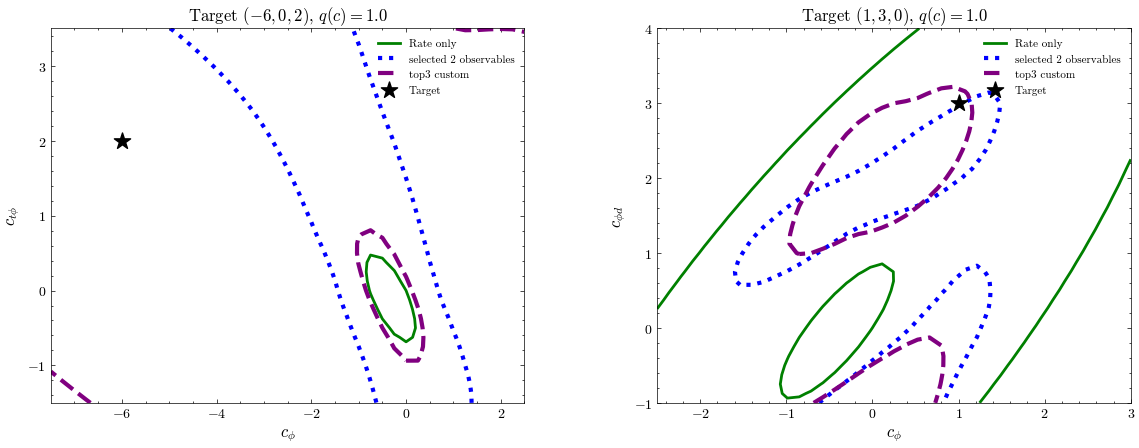

In [14]:
# ============================================================
# Plot 2D q(c) contours:
# Rate only vs selected 2 observables vs top3 custom
#
# z-axis is directly:
# q(c) = -2 ln[p(x|c) / p(x|0)]
#
# The contour is manually selected as:
# q(c) = CONTOUR_Q_LEVEL
#
# Region inside / below the contour corresponds to:
# q(c) <= CONTOUR_Q_LEVEL
# ============================================================

BSM_2D_FIGSIZE = (12.0, 5.2)

BSM_2D_LEFT = 0.08
BSM_2D_RIGHT = 0.98
BSM_2D_BOTTOM = 0.14
BSM_2D_TOP = 0.86
BSM_2D_WSPACE = 0.28

# ------------------------------------------------------------
# Manually selected q-level
# ------------------------------------------------------------
# This is your z = 1 cutting plane.
# Change this number if you want a different contour level.

CONTOUR_Q_LEVEL = 1.0

SAVE_BSM_2D_CONTOUR_FIG = True
BSM_2D_CONTOUR_SAVE_PATH = (
    "plots/07_observable_study/"
    "bsm_2d_rate_selected2_top3custom_q1_contours.png"
)

# ------------------------------------------------------------
# Plot styles
# ------------------------------------------------------------

STYLE_2D_CONTOUR = {
    "Rate only": {
        "colors": "green",
        "linestyles": "solid",
        "linewidths": 2.0,
    },
    r"selected 2 observables": {
        "colors": "blue",
        "linestyles": "dotted",
        "linewidths": 3.0,
    },
    r"top3 custom": {
        "colors": "purple",
        "linestyles": "dashed",
        "linewidths": 3.0,
    },
}

STYLE_2D_LEGEND = {
    "Rate only": {
        "color": "green",
        "linestyle": "solid",
        "lw": 2.0,
    },
    r"selected 2 observables": {
        "color": "blue",
        "linestyle": "dotted",
        "lw": 3.0,
    },
    r"top3 custom": {
        "color": "purple",
        "linestyle": "dashed",
        "lw": 3.0,
    },
}


def reshape_2d_values_from_cgrid(c_grid, values, x_index, y_index):
    c_grid = np.asarray(c_grid)
    values = np.asarray(values).reshape(-1)

    x_unique = np.sort(np.unique(c_grid[:, x_index]))
    y_unique = np.sort(np.unique(c_grid[:, y_index]))

    z = np.full((len(y_unique), len(x_unique)), np.nan)

    x_map = {value: i for i, value in enumerate(x_unique)}
    y_map = {value: i for i, value in enumerate(y_unique)}

    for point, value in zip(c_grid, values):
        ix = x_map[point[x_index]]
        iy = y_map[point[y_index]]
        z[iy, ix] = value

    X, Y = np.meshgrid(x_unique, y_unique)

    return X, Y, z


def contour_raw_q(
    ax,
    c_grid,
    q_raw,
    x_index,
    y_index,
    label,
    q_level,
    style_contour,
    style_legend,
):
    X, Y, Z_raw = reshape_2d_values_from_cgrid(
        c_grid,
        q_raw,
        x_index,
        y_index,
    )

    # ------------------------------------------------------------
    # Match your 1D convention:
    # plotted q(c) = - q_total_raw
    # ------------------------------------------------------------

    Z_q = -Z_raw

    zmin = np.nanmin(Z_q)
    zmax = np.nanmax(Z_q)

    print(
        "Contour:",
        label,
        "| q_level =",
        q_level,
        "| q range =",
        (zmin, zmax),
    )

    # Add dummy line for legend even if contour is not drawable.
    ax.plot(
        [np.nan],
        [np.nan],
        label=label,
        **style_legend,
    )

    if not (zmin <= q_level <= zmax):
        print("WARNING: q level is outside the available q range for", label)
        return None

    cs = ax.contour(
        X,
        Y,
        Z_q,
        levels=[q_level],
        **style_contour,
    )

    return cs


def plot_bsm_2d_q_contours(
    bsm_2d_results,
    save=True,
):
    fig, axes = plt.subplots(
        1,
        len(BSM_2D_TEST_CODES_TO_PLOT),
        figsize=BSM_2D_FIGSIZE,
        sharex=False,
        sharey=False,
    )

    if len(BSM_2D_TEST_CODES_TO_PLOT) == 1:
        axes = [axes]

    for col_idx, test_code in enumerate(BSM_2D_TEST_CODES_TO_PLOT):
        ax = axes[col_idx]

        point_info = bsm_2d_results[test_code]["point_info"]

        true_c_plot = np.asarray(point_info["true_c_plot"], dtype=float)
        scan_indices = point_info["scan_indices"]

        x_index = int(scan_indices[0])
        y_index = int(scan_indices[1])

        # ------------------------------------------------------------
        # Rate only contour
        # ------------------------------------------------------------

        rate_result = bsm_2d_results[test_code]["rate_only"]

        contour_raw_q(
            ax=ax,
            c_grid=rate_result["c_grid"],
            q_raw=rate_result["q_raw"],
            x_index=x_index,
            y_index=y_index,
            label="Rate only",
            q_level=CONTOUR_Q_LEVEL,
            style_contour=STYLE_2D_CONTOUR["Rate only"],
            style_legend=STYLE_2D_LEGEND["Rate only"],
        )

        # ------------------------------------------------------------
        # selected 2 observables and top3 custom contours
        # ------------------------------------------------------------

        for spec in BSM_2D_MODEL_SPECS:
            label = spec["label"]

            scan_result = bsm_2d_results[test_code]["models"][label]["scan_result"]

            contour_raw_q(
                ax=ax,
                c_grid=scan_result["c_grid"],
                q_raw=scan_result["q_total_raw"],
                x_index=x_index,
                y_index=y_index,
                label=label,
                q_level=CONTOUR_Q_LEVEL,
                style_contour=STYLE_2D_CONTOUR[label],
                style_legend=STYLE_2D_LEGEND[label],
            )

        # ------------------------------------------------------------
        # Target point
        # ------------------------------------------------------------

        ax.scatter(
            true_c_plot[x_index],
            true_c_plot[y_index],
            s=150,
            marker="*",
            color="black",
            label="Target",
            zorder=10,
        )

        ax.set_xlabel(
            WILSON_LABELS[x_index],
            fontsize=12,
        )

        ax.set_ylabel(
            WILSON_LABELS[y_index],
            fontsize=12,
        )

        ax.set_title(
            rf"{point_info['title']}, $q(c)={CONTOUR_Q_LEVEL}$",
            fontsize=12,
        )

        ax.legend(
            frameon=False,
            fontsize=8,
            loc="best",
        )

    fig.subplots_adjust(
        left=BSM_2D_LEFT,
        right=BSM_2D_RIGHT,
        bottom=BSM_2D_BOTTOM,
        top=BSM_2D_TOP,
        wspace=BSM_2D_WSPACE,
    )

    if save:
        fig.savefig(
            BSM_2D_CONTOUR_SAVE_PATH,
            dpi=300,
            bbox_inches="tight",
        )

        print("Saved:", BSM_2D_CONTOUR_SAVE_PATH)

    plt.show()


plot_bsm_2d_q_contours(
    bsm_2d_results,
    save=SAVE_BSM_2D_CONTOUR_FIG,
)


Contour: Rate only | q_level = 1.0 | q range = (-1485597.9562314518, 128624.80763209179)
Contour: selected 2 observables | q_level = 1.0 | q range = (-1176562.3215772673, 934747.3004926061)
Contour: top3 custom | q_level = 1.0 | q range = (-1266540.6227767954, 305120.81836335966)
Contour: Rate only | q_level = 1.0 | q range = (-34432.910548978296, 426787.5748679524)
Contour: selected 2 observables | q_level = 1.0 | q range = (-27959.421955636266, 480807.3658803222)
Contour: top3 custom | q_level = 1.0 | q range = (-26836.753925868066, 533731.8265492675)
Saved: plots/07_observable_study/bsm_2d_rate_selected2_top3custom_q1_contours_with_colour.png


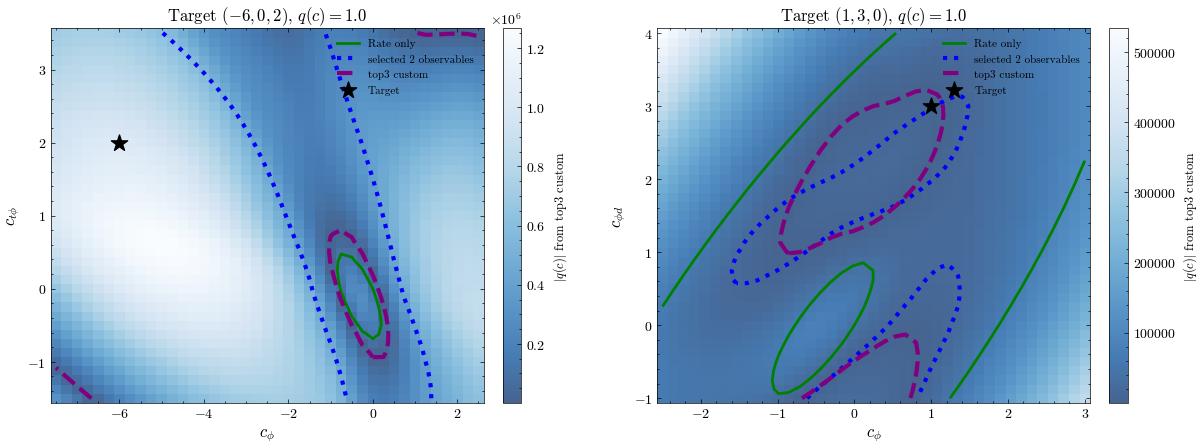

In [15]:
# ============================================================
# Plot 2D q(c) contours + colour surface:
# Rate only vs selected 2 observables vs top3 custom
#
# z-axis is directly:
# q(c) = -2 ln[p(x|c) / p(x|0)]
#
# The contour is manually selected as:
# q(c) = CONTOUR_Q_LEVEL
#
# Colour background:
# |q(c)| from one selected model.
# Darker blue means closer to q(c)=0.
# ============================================================

BSM_2D_FIGSIZE = (12.0, 5.2)

BSM_2D_LEFT = 0.08
BSM_2D_RIGHT = 0.98
BSM_2D_BOTTOM = 0.14
BSM_2D_TOP = 0.86
BSM_2D_WSPACE = 0.28

# ------------------------------------------------------------
# Manually selected q-level
# ------------------------------------------------------------

CONTOUR_Q_LEVEL = 1.0

SAVE_BSM_2D_CONTOUR_FIG = True
BSM_2D_CONTOUR_SAVE_PATH = (
    "plots/07_observable_study/"
    "bsm_2d_rate_selected2_top3custom_q1_contours_with_colour.png"
)

# ------------------------------------------------------------
# Which surface to use for the colour map
# ------------------------------------------------------------
# Options:
# "Rate only"
# r"selected 2 observables"
# r"top3 custom"

COLOUR_SURFACE_LABEL = r"top3 custom"

# ------------------------------------------------------------
# Plot styles
# ------------------------------------------------------------

STYLE_2D_CONTOUR = {
    "Rate only": {
        "colors": "green",
        "linestyles": "solid",
        "linewidths": 2.0,
    },
    r"selected 2 observables": {
        "colors": "blue",
        "linestyles": "dotted",
        "linewidths": 3.0,
    },
    r"top3 custom": {
        "colors": "purple",
        "linestyles": "dashed",
        "linewidths": 3.0,
    },
}

STYLE_2D_LEGEND = {
    "Rate only": {
        "color": "green",
        "linestyle": "solid",
        "lw": 2.0,
    },
    r"selected 2 observables": {
        "color": "blue",
        "linestyle": "dotted",
        "lw": 3.0,
    },
    r"top3 custom": {
        "color": "purple",
        "linestyle": "dashed",
        "lw": 3.0,
    },
}


def reshape_2d_values_from_cgrid(c_grid, values, x_index, y_index):
    c_grid = np.asarray(c_grid)
    values = np.asarray(values).reshape(-1)

    x_unique = np.sort(np.unique(c_grid[:, x_index]))
    y_unique = np.sort(np.unique(c_grid[:, y_index]))

    z = np.full((len(y_unique), len(x_unique)), np.nan)

    x_map = {value: i for i, value in enumerate(x_unique)}
    y_map = {value: i for i, value in enumerate(y_unique)}

    for point, value in zip(c_grid, values):
        ix = x_map[point[x_index]]
        iy = y_map[point[y_index]]
        z[iy, ix] = value

    X, Y = np.meshgrid(x_unique, y_unique)

    return X, Y, z


def get_q_raw_for_colour_surface(test_result, surface_label):
    if surface_label == "Rate only":
        return (
            test_result["rate_only"]["c_grid"],
            test_result["rate_only"]["q_raw"],
        )

    return (
        test_result["models"][surface_label]["scan_result"]["c_grid"],
        test_result["models"][surface_label]["scan_result"]["q_total_raw"],
    )


def add_colour_surface(
    fig,
    ax,
    test_result,
    x_index,
    y_index,
    surface_label,
):
    c_grid, q_raw = get_q_raw_for_colour_surface(
        test_result,
        surface_label,
    )

    X, Y, Z_raw = reshape_2d_values_from_cgrid(
        c_grid,
        q_raw,
        x_index,
        y_index,
    )

    # Match your 1D convention:
    # q(c) = - q_total_raw
    Z_q = -Z_raw

    # Colour represents distance from q=0.
    # Blues_r makes smaller |q| darker blue.
    Z_colour = np.abs(Z_q)

    pcm = ax.pcolormesh(
        X,
        Y,
        Z_colour,
        cmap="Blues_r",
        shading="auto",
        alpha=0.75,
    )

    cbar = fig.colorbar(
        pcm,
        ax=ax,
        fraction=0.046,
        pad=0.04,
    )

    cbar.set_label(
        rf"$|q(c)|$ from {surface_label}",
        fontsize=9,
    )

    return pcm


def contour_raw_q(
    ax,
    c_grid,
    q_raw,
    x_index,
    y_index,
    label,
    q_level,
    style_contour,
    style_legend,
):
    X, Y, Z_raw = reshape_2d_values_from_cgrid(
        c_grid,
        q_raw,
        x_index,
        y_index,
    )

    # ------------------------------------------------------------
    # Match your 1D convention:
    # plotted q(c) = - q_total_raw
    # ------------------------------------------------------------

    Z_q = -Z_raw

    zmin = np.nanmin(Z_q)
    zmax = np.nanmax(Z_q)

    print(
        "Contour:",
        label,
        "| q_level =",
        q_level,
        "| q range =",
        (zmin, zmax),
    )

    # Add dummy line for legend even if contour is not drawable.
    ax.plot(
        [np.nan],
        [np.nan],
        label=label,
        **style_legend,
    )

    if not (zmin <= q_level <= zmax):
        print("WARNING: q level is outside the available q range for", label)
        return None

    cs = ax.contour(
        X,
        Y,
        Z_q,
        levels=[q_level],
        **style_contour,
    )

    return cs


def plot_bsm_2d_q_contours(
    bsm_2d_results,
    save=True,
):
    fig, axes = plt.subplots(
        1,
        len(BSM_2D_TEST_CODES_TO_PLOT),
        figsize=BSM_2D_FIGSIZE,
        sharex=False,
        sharey=False,
    )

    if len(BSM_2D_TEST_CODES_TO_PLOT) == 1:
        axes = [axes]

    for col_idx, test_code in enumerate(BSM_2D_TEST_CODES_TO_PLOT):
        ax = axes[col_idx]

        test_result = bsm_2d_results[test_code]
        point_info = test_result["point_info"]

        true_c_plot = np.asarray(point_info["true_c_plot"], dtype=float)
        scan_indices = point_info["scan_indices"]

        x_index = int(scan_indices[0])
        y_index = int(scan_indices[1])

        # ------------------------------------------------------------
        # Colour surface
        # ------------------------------------------------------------

        add_colour_surface(
            fig=fig,
            ax=ax,
            test_result=test_result,
            x_index=x_index,
            y_index=y_index,
            surface_label=COLOUR_SURFACE_LABEL,
        )

        # ------------------------------------------------------------
        # Rate only contour
        # ------------------------------------------------------------

        rate_result = test_result["rate_only"]

        contour_raw_q(
            ax=ax,
            c_grid=rate_result["c_grid"],
            q_raw=rate_result["q_raw"],
            x_index=x_index,
            y_index=y_index,
            label="Rate only",
            q_level=CONTOUR_Q_LEVEL,
            style_contour=STYLE_2D_CONTOUR["Rate only"],
            style_legend=STYLE_2D_LEGEND["Rate only"],
        )

        # ------------------------------------------------------------
        # selected 2 observables and top3 custom contours
        # ------------------------------------------------------------

        for spec in BSM_2D_MODEL_SPECS:
            label = spec["label"]

            scan_result = test_result["models"][label]["scan_result"]

            contour_raw_q(
                ax=ax,
                c_grid=scan_result["c_grid"],
                q_raw=scan_result["q_total_raw"],
                x_index=x_index,
                y_index=y_index,
                label=label,
                q_level=CONTOUR_Q_LEVEL,
                style_contour=STYLE_2D_CONTOUR[label],
                style_legend=STYLE_2D_LEGEND[label],
            )

        # ------------------------------------------------------------
        # Target point
        # ------------------------------------------------------------

        ax.scatter(
            true_c_plot[x_index],
            true_c_plot[y_index],
            s=150,
            marker="*",
            color="black",
            label="Target",
            zorder=10,
        )

        ax.set_xlabel(
            WILSON_LABELS[x_index],
            fontsize=12,
        )

        ax.set_ylabel(
            WILSON_LABELS[y_index],
            fontsize=12,
        )

        ax.set_title(
            rf"{point_info['title']}, $q(c)={CONTOUR_Q_LEVEL}$",
            fontsize=12,
        )

        ax.legend(
            frameon=False,
            fontsize=8,
            loc="best",
        )

    fig.subplots_adjust(
        left=BSM_2D_LEFT,
        right=BSM_2D_RIGHT,
        bottom=BSM_2D_BOTTOM,
        top=BSM_2D_TOP,
        wspace=BSM_2D_WSPACE,
    )

    if save:
        fig.savefig(
            BSM_2D_CONTOUR_SAVE_PATH,
            dpi=300,
            bbox_inches="tight",
        )

        print("Saved:", BSM_2D_CONTOUR_SAVE_PATH)

    plt.show()


plot_bsm_2d_q_contours(
    bsm_2d_results,
    save=SAVE_BSM_2D_CONTOUR_FIG,
)

Contour: Rate only | q_level = 1.0 | q range = (-1485597.9562314518, 128624.80763209179)
Contour: selected 2 observables | q_level = 1.0 | q range = (-1176562.3215772673, 934747.3004926061)
Contour: top3 custom | q_level = 1.0 | q range = (-1266540.6227767954, 305120.81836335966)
Contour: Rate only | q_level = 1.0 | q range = (-34432.910548978296, 426787.5748679524)
Contour: selected 2 observables | q_level = 1.0 | q range = (-27959.421955636266, 480807.3658803222)
Contour: top3 custom | q_level = 1.0 | q range = (-26836.753925868066, 533731.8265492675)
Saved: plots/07_observable_study/bsm_2d_rate_selected2_top3custom_q1_contours_with_colour.png


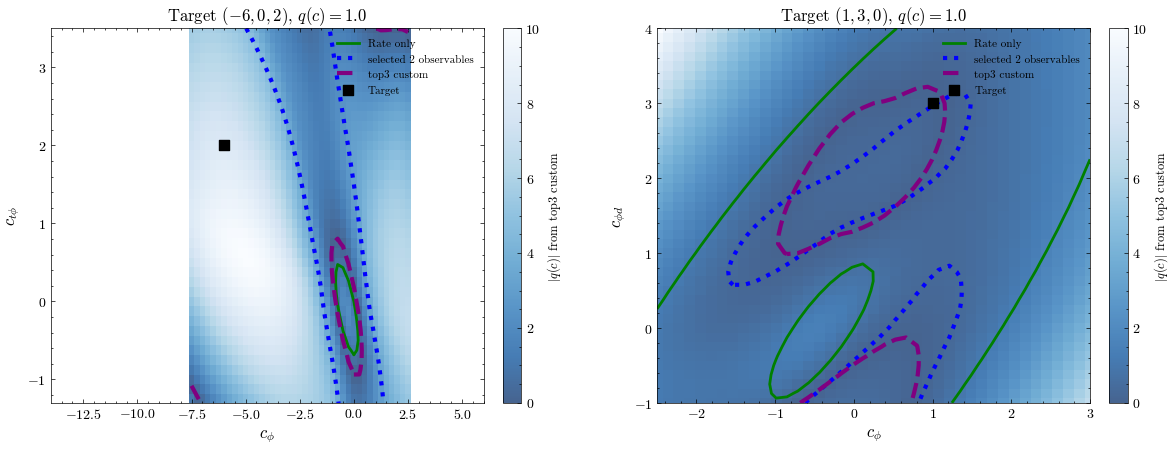

In [16]:
# ============================================================
# Plot 2D q(c) contours + colour surface:
# Rate only vs selected 2 observables vs top3 custom
#
# z-axis is directly:
# q(c) = -2 ln[p(x|c) / p(x|0)]
#
# The contour is manually selected as:
# q(c) = CONTOUR_Q_LEVEL
#
# Colour background:
# |q(c)| from one selected model.
# Darker blue means closer to q(c)=0.
#
# New controls:
# 1. Colourbar displayed tick labels are remapped to 0--10.
# 2. Each subplot has independently controlled xlim and ylim.
# ============================================================

BSM_2D_FIGSIZE = (12.0, 5.2)

BSM_2D_LEFT = 0.08
BSM_2D_RIGHT = 0.98
BSM_2D_BOTTOM = 0.14
BSM_2D_TOP = 0.86
BSM_2D_WSPACE = 0.28

# ------------------------------------------------------------
# Manually selected q-level
# ------------------------------------------------------------

CONTOUR_Q_LEVEL = 1.0

SAVE_BSM_2D_CONTOUR_FIG = True
BSM_2D_CONTOUR_SAVE_PATH = (
    "plots/07_observable_study/"
    "bsm_2d_rate_selected2_top3custom_q1_contours_with_colour.png"
)

# ------------------------------------------------------------
# Which surface to use for the colour map
# ------------------------------------------------------------
# Options:
# "Rate only"
# r"selected 2 observables"
# r"top3 custom"

COLOUR_SURFACE_LABEL = r"top3 custom"

# ------------------------------------------------------------
# Colourbar displayed labels
# ------------------------------------------------------------
# This only changes displayed tick labels on the colourbar.
# It does not change the underlying colour values.

COLOURBAR_FAKE_MIN = 0.0
COLOURBAR_FAKE_MAX = 10.0
COLOURBAR_N_TICKS = 6

# ------------------------------------------------------------
# Manual axis limits for each subplot
# ------------------------------------------------------------
# Each test_code can have its own xlim and ylim.
# This means the c_phi range can be different in the two panels.

AXIS_LIMITS_2D = {
    "mix_m60_p00_p20": {
        "xlim": (-14.0, 6.0),   # c_phi range for panel 1
        "ylim": (-1.3, 3.5),    # c_tphi range for panel 1
    },
    "mix_p10_p30_p00": {
        "xlim": (-2.5, 3.0),   # c_phi range for panel 2
        "ylim": (-1, 4.0),    # c_phid range for panel 2
    },
}

# ------------------------------------------------------------
# Plot styles
# ------------------------------------------------------------

STYLE_2D_CONTOUR = {
    "Rate only": {
        "colors": "green",
        "linestyles": "solid",
        "linewidths": 2.0,
    },
    r"selected 2 observables": {
        "colors": "blue",
        "linestyles": "dotted",
        "linewidths": 3.0,
    },
    r"top3 custom": {
        "colors": "purple",
        "linestyles": "dashed",
        "linewidths": 3.0,
    },
}

STYLE_2D_LEGEND = {
    "Rate only": {
        "color": "green",
        "linestyle": "solid",
        "lw": 2.0,
    },
    r"selected 2 observables": {
        "color": "blue",
        "linestyle": "dotted",
        "lw": 3.0,
    },
    r"top3 custom": {
        "color": "purple",
        "linestyle": "dashed",
        "lw": 3.0,
    },
}


def reshape_2d_values_from_cgrid(c_grid, values, x_index, y_index):
    c_grid = np.asarray(c_grid)
    values = np.asarray(values).reshape(-1)

    x_unique = np.sort(np.unique(c_grid[:, x_index]))
    y_unique = np.sort(np.unique(c_grid[:, y_index]))

    z = np.full((len(y_unique), len(x_unique)), np.nan)

    x_map = {value: i for i, value in enumerate(x_unique)}
    y_map = {value: i for i, value in enumerate(y_unique)}

    for point, value in zip(c_grid, values):
        ix = x_map[point[x_index]]
        iy = y_map[point[y_index]]
        z[iy, ix] = value

    X, Y = np.meshgrid(x_unique, y_unique)

    return X, Y, z


def get_q_raw_for_colour_surface(test_result, surface_label):
    if surface_label == "Rate only":
        return (
            test_result["rate_only"]["c_grid"],
            test_result["rate_only"]["q_raw"],
        )

    return (
        test_result["models"][surface_label]["scan_result"]["c_grid"],
        test_result["models"][surface_label]["scan_result"]["q_total_raw"],
    )


def apply_display_colourbar_labels(cbar, fake_min=0.0, fake_max=10.0, n_ticks=6):
    real_vmin, real_vmax = cbar.mappable.get_clim()

    real_ticks = np.linspace(real_vmin, real_vmax, n_ticks)
    fake_labels = np.linspace(fake_min, fake_max, n_ticks)

    cbar.set_ticks(real_ticks)
    cbar.set_ticklabels([f"{v:.0f}" for v in fake_labels])


def add_colour_surface(
    fig,
    ax,
    test_result,
    x_index,
    y_index,
    surface_label,
):
    c_grid, q_raw = get_q_raw_for_colour_surface(
        test_result,
        surface_label,
    )

    X, Y, Z_raw = reshape_2d_values_from_cgrid(
        c_grid,
        q_raw,
        x_index,
        y_index,
    )

    # Match your 1D convention:
    # q(c) = - q_total_raw
    Z_q = -Z_raw

    # Colour represents distance from q=0.
    # Blues_r makes smaller |q| darker blue.
    Z_colour = np.abs(Z_q)

    pcm = ax.pcolormesh(
        X,
        Y,
        Z_colour,
        cmap="Blues_r",
        shading="auto",
        alpha=0.75,
    )

    cbar = fig.colorbar(
        pcm,
        ax=ax,
        fraction=0.046,
        pad=0.04,
    )

    cbar.set_label(
        rf"$|q(c)|$ from {surface_label}",
        fontsize=9,
    )

    apply_display_colourbar_labels(
        cbar,
        fake_min=COLOURBAR_FAKE_MIN,
        fake_max=COLOURBAR_FAKE_MAX,
        n_ticks=COLOURBAR_N_TICKS,
    )

    return pcm


def contour_raw_q(
    ax,
    c_grid,
    q_raw,
    x_index,
    y_index,
    label,
    q_level,
    style_contour,
    style_legend,
):
    X, Y, Z_raw = reshape_2d_values_from_cgrid(
        c_grid,
        q_raw,
        x_index,
        y_index,
    )

    # Match your 1D convention:
    # plotted q(c) = - q_total_raw
    Z_q = -Z_raw

    zmin = np.nanmin(Z_q)
    zmax = np.nanmax(Z_q)

    print(
        "Contour:",
        label,
        "| q_level =",
        q_level,
        "| q range =",
        (zmin, zmax),
    )

    ax.plot(
        [np.nan],
        [np.nan],
        label=label,
        **style_legend,
    )

    if not (zmin <= q_level <= zmax):
        print("WARNING: q level is outside the available q range for", label)
        return None

    cs = ax.contour(
        X,
        Y,
        Z_q,
        levels=[q_level],
        **style_contour,
    )

    return cs


def plot_bsm_2d_q_contours(
    bsm_2d_results,
    save=True,
):
    fig, axes = plt.subplots(
        1,
        len(BSM_2D_TEST_CODES_TO_PLOT),
        figsize=BSM_2D_FIGSIZE,
        sharex=False,
        sharey=False,
    )

    if len(BSM_2D_TEST_CODES_TO_PLOT) == 1:
        axes = [axes]

    for col_idx, test_code in enumerate(BSM_2D_TEST_CODES_TO_PLOT):
        ax = axes[col_idx]

        test_result = bsm_2d_results[test_code]
        point_info = test_result["point_info"]

        true_c_plot = np.asarray(point_info["true_c_plot"], dtype=float)
        scan_indices = point_info["scan_indices"]

        x_index = int(scan_indices[0])
        y_index = int(scan_indices[1])

        # ------------------------------------------------------------
        # Colour surface
        # ------------------------------------------------------------

        add_colour_surface(
            fig=fig,
            ax=ax,
            test_result=test_result,
            x_index=x_index,
            y_index=y_index,
            surface_label=COLOUR_SURFACE_LABEL,
        )

        # ------------------------------------------------------------
        # Rate only contour
        # ------------------------------------------------------------

        rate_result = test_result["rate_only"]

        contour_raw_q(
            ax=ax,
            c_grid=rate_result["c_grid"],
            q_raw=rate_result["q_raw"],
            x_index=x_index,
            y_index=y_index,
            label="Rate only",
            q_level=CONTOUR_Q_LEVEL,
            style_contour=STYLE_2D_CONTOUR["Rate only"],
            style_legend=STYLE_2D_LEGEND["Rate only"],
        )

        # ------------------------------------------------------------
        # selected 2 observables and top3 custom contours
        # ------------------------------------------------------------

        for spec in BSM_2D_MODEL_SPECS:
            label = spec["label"]

            scan_result = test_result["models"][label]["scan_result"]

            contour_raw_q(
                ax=ax,
                c_grid=scan_result["c_grid"],
                q_raw=scan_result["q_total_raw"],
                x_index=x_index,
                y_index=y_index,
                label=label,
                q_level=CONTOUR_Q_LEVEL,
                style_contour=STYLE_2D_CONTOUR[label],
                style_legend=STYLE_2D_LEGEND[label],
            )

        # ------------------------------------------------------------
        # Target point: black small square
        # ------------------------------------------------------------

        ax.scatter(
            true_c_plot[x_index],
            true_c_plot[y_index],
            s=55,
            marker="s",
            color="black",
            label="Target",
            zorder=10,
        )

        ax.set_xlabel(
            WILSON_LABELS[x_index],
            fontsize=12,
        )

        ax.set_ylabel(
            WILSON_LABELS[y_index],
            fontsize=12,
        )

        ax.set_title(
            rf"{point_info['title']}, $q(c)={CONTOUR_Q_LEVEL}$",
            fontsize=12,
        )

        # ------------------------------------------------------------
        # Manual xlim and ylim for this subplot
        # ------------------------------------------------------------

        if test_code in AXIS_LIMITS_2D:
            if AXIS_LIMITS_2D[test_code].get("xlim") is not None:
                ax.set_xlim(*AXIS_LIMITS_2D[test_code]["xlim"])

            if AXIS_LIMITS_2D[test_code].get("ylim") is not None:
                ax.set_ylim(*AXIS_LIMITS_2D[test_code]["ylim"])

        ax.legend(
            frameon=False,
            fontsize=8,
            loc="best",
        )

    fig.subplots_adjust(
        left=BSM_2D_LEFT,
        right=BSM_2D_RIGHT,
        bottom=BSM_2D_BOTTOM,
        top=BSM_2D_TOP,
        wspace=BSM_2D_WSPACE,
    )

    if save:
        fig.savefig(
            BSM_2D_CONTOUR_SAVE_PATH,
            dpi=300,
            bbox_inches="tight",
        )

        print("Saved:", BSM_2D_CONTOUR_SAVE_PATH)

    plt.show()


plot_bsm_2d_q_contours(
    bsm_2d_results,
    save=SAVE_BSM_2D_CONTOUR_FIG,
)


2D BSM test point: mix_m60_p00_p20
true_c_plot: [-6.  0.  2.]
true_c_madminer: (-60.0, 0.0, 20.0)
scan_indices: 02
x_index: 0 | y_index: 2
lower_limits_2d: [-14.0, -0.45, -5.0]
upper_limits_2d: [6.0, 0.55, 7.0]
Loading run config: /home/hep/jl3222/projects/nsbi_photon_final_state/run_configs/m4b_pt_h/m4b_pt_h_all.yml
Loading scaler: /vols/cms/jl3222/model_backup/m4b_pt_h/scaler_m4b_pt_h_all.pkl
Loading model: /vols/cms/jl3222/model_backup/m4b_pt_h/m4b_pt_h_all_Ssm_Salt_best_model.pt
Loading model: /vols/cms/jl3222/model_backup/m4b_pt_h/m4b_pt_h_all_B_Salt_best_model.pt
Loading model: /vols/cms/jl3222/model_backup/m4b_pt_h/m4b_pt_h_all_Ssm_B_best_model.pt
Loaded run_id=m4b_pt_h_all, model_dir=/vols/cms/jl3222/model_backup/m4b_pt_h, network_id=m4b_pt_h_all, parameter_code=c2, features=[25, 26, 17, 18]
Rate-only q shape: (900,)
Expected BSM signal events: 309986.31713813974

----------------------------------------------------------------------------------------------------
Running 2D mo

/home/hep/jl3222/projects/nsbi_photon_final_state/helpers/test_statistics.py:242: RuntimeWarning: divide by zero encountered in divide
  comp_3  = np.array([(f_sig_SM / (1.0 - f_sig_alt[i]))*(1.0/lr_B_to_S_SM[:]) for i in range(N_c_points)])  # shape: (# c points, # test points, 1)


q_total_raw shape: (900,)
Intermediate result saved to: preplot_pickles/07_bsm_2d_expanded_range_fast500.pkl

----------------------------------------------------------------------------------------------------
Running 2D model: top3 custom
run_id: top3_custom_all
model_dir: /vols/cms/jl3222/model_backup/top3_custom
Loading run config: /home/hep/jl3222/projects/nsbi_photon_final_state/run_configs/top3_custom/top3_custom_all.yml
Loading scaler: /vols/cms/jl3222/model_backup/top3_custom/scaler_top3_custom_all.pkl
Loading model: /vols/cms/jl3222/model_backup/top3_custom/top3_custom_all_Ssm_Salt_best_model.pt
Loading model: /vols/cms/jl3222/model_backup/top3_custom/top3_custom_all_B_Salt_best_model.pt
Loading model: /vols/cms/jl3222/model_backup/top3_custom/top3_custom_all_Ssm_B_best_model.pt
Loaded run_id=top3_custom_all, model_dir=/vols/cms/jl3222/model_backup/top3_custom, network_id=top3_custom_all, parameter_code=c2, features=[24, 27, 30]
Pseudo-data built for mix_m60_p00_p20: N_sig=30

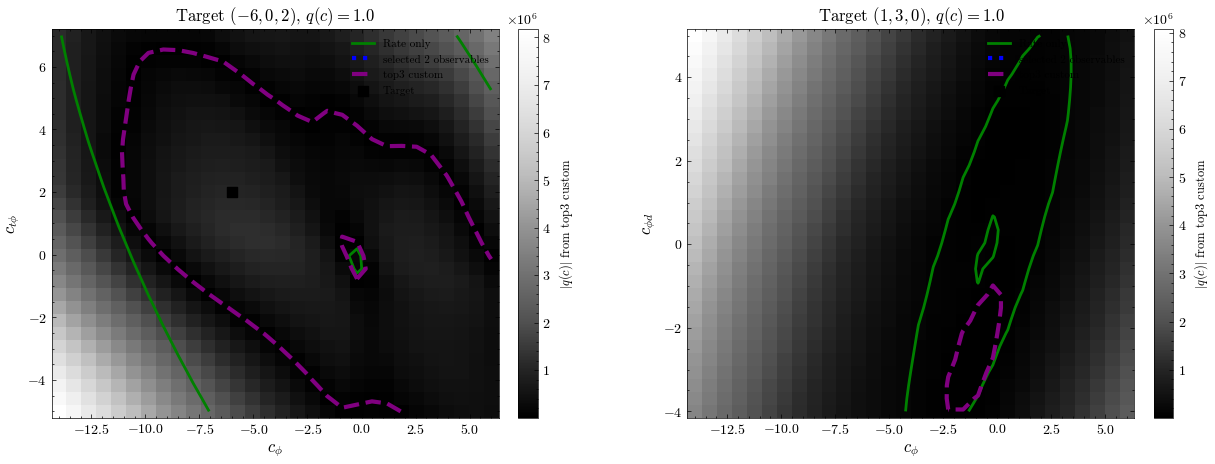

In [17]:
# ============================================================
# Expanded-range fast 2D Wilson scan + contour plot
#
# Compare:
#   Rate only
#   selected 2 observables = m4b_pt_h_all
#   top3 custom = top3_custom_all
#
# Target points:
#   mix_m60_p00_p20 = [-6, 0, 2], scan c_phi vs c_tphi
#   mix_p10_p30_p00 = [1, 3, 0], scan c_phi vs c_phid
#
# Full scan ranges:
#   c_phi   : [-14, 6]
#   c_phid  : [-4, 5]
#   ctphi   : [-5, 7]
#
# Contour:
#   q(c1, c2) = CONTOUR_Q_LEVEL
#
# Color background:
#   chosen model's |q(c)| value, darker means closer to 0
# ============================================================

# ------------------------------------------------------------
# Models
# ------------------------------------------------------------

BSM_2D_MODEL_SPECS = [
    {
        "label": r"selected 2 observables",
        "run_id": "m4b_pt_h_all",
        "model_dir": f"{MODEL_BACKUP_DIR}/m4b_pt_h",
    },
    {
        "label": r"top3 custom",
        "run_id": "top3_custom_all",
        "model_dir": f"{MODEL_BACKUP_DIR}/top3_custom",
    },
]

# ------------------------------------------------------------
# Full Wilson coefficient ranges shown on the axes
# ------------------------------------------------------------

WILSON_SCAN_FULL_RANGES = {
    0: (-14.0, 6.0),   # c_phi
    1: (-4.0, 5.0),    # c_phid
    2: (-5.0, 7.0),    # ctphi
}

BSM_2D_POINTS = {
    "mix_m60_p00_p20": {
        "title": r"Target $(-6,0,2)$",
        "true_c_plot": np.array([-6.0, 0.0, 2.0]),
        "scan_indices": "02",
        "scan_ranges_plot": {
            0: WILSON_SCAN_FULL_RANGES[0],
            2: WILSON_SCAN_FULL_RANGES[2],
        },
    },
    "mix_p10_p30_p00": {
        "title": r"Target $(1,3,0)$",
        "true_c_plot": np.array([1.0, 3.0, 0.0]),
        "scan_indices": "01",
        "scan_ranges_plot": {
            0: WILSON_SCAN_FULL_RANGES[0],
            1: WILSON_SCAN_FULL_RANGES[1],
        },
    },
}

BSM_2D_TEST_CODES_TO_PLOT = [
    "mix_m60_p00_p20",
    "mix_p10_p30_p00",
]

# ------------------------------------------------------------
# Fast settings
# ------------------------------------------------------------

N_SCAN_BSM_2D = 30
SHAPE_CHUNK_SIZE_2D = 250
MAX_SHAPE_EVENTS_2D = 500

FORCE_RECOMPUTE_BSM_2D = True
bsm_2d_cache_path = "preplot_pickles/07_bsm_2d_expanded_range_fast500.pkl"

# ------------------------------------------------------------
# Contour and color settings
# ------------------------------------------------------------

CONTOUR_Q_LEVEL = 1.0

COLOR_SURFACE_LABEL = r"top3 custom"
# Options:
#   "Rate only"
#   r"selected 2 observables"
#   r"top3 custom"

BSM_2D_FIGSIZE = (12.5, 5.4)

BSM_2D_LEFT = 0.08
BSM_2D_RIGHT = 0.98
BSM_2D_BOTTOM = 0.14
BSM_2D_TOP = 0.86
BSM_2D_WSPACE = 0.30

SAVE_BSM_2D_CONTOUR_FIG = True
BSM_2D_CONTOUR_SAVE_PATH = (
    "plots/07_observable_study/"
    "bsm_2d_expanded_range_rate_selected2_top3custom_q1_contours.png"
)

STYLE_2D_CONTOUR = {
    "Rate only": {
        "colors": "green",
        "linestyles": "solid",
        "linewidths": 2.0,
    },
    r"selected 2 observables": {
        "colors": "blue",
        "linestyles": "dotted",
        "linewidths": 3.0,
    },
    r"top3 custom": {
        "colors": "purple",
        "linestyles": "dashed",
        "linewidths": 3.0,
    },
}

STYLE_2D_LEGEND = {
    "Rate only": {
        "color": "green",
        "linestyle": "solid",
        "lw": 2.0,
    },
    r"selected 2 observables": {
        "color": "blue",
        "linestyle": "dotted",
        "lw": 3.0,
    },
    r"top3 custom": {
        "color": "purple",
        "linestyle": "dashed",
        "lw": 3.0,
    },
}

os.makedirs("preplot_pickles", exist_ok=True)
os.makedirs("plots/07_observable_study", exist_ok=True)


# ============================================================
# Helper functions
# ============================================================

def make_2d_scan_limits(scan_ranges_plot):
    lower_limits_local = list(lower_limits_scaled)
    upper_limits_local = list(upper_limits_scaled)

    for coeff_index, scan_range in scan_ranges_plot.items():
        lower_limits_local[coeff_index] = scan_range[0]
        upper_limits_local[coeff_index] = scan_range[1]

    return lower_limits_local, upper_limits_local


def reshape_2d_values_from_cgrid(c_grid, values, x_index, y_index):
    c_grid = np.asarray(c_grid)
    values = np.asarray(values).reshape(-1)

    x_unique = np.sort(np.unique(c_grid[:, x_index]))
    y_unique = np.sort(np.unique(c_grid[:, y_index]))

    z = np.full((len(y_unique), len(x_unique)), np.nan)

    x_map = {value: i for i, value in enumerate(x_unique)}
    y_map = {value: i for i, value in enumerate(y_unique)}

    for point, value in zip(c_grid, values):
        ix = x_map[point[x_index]]
        iy = y_map[point[y_index]]
        z[iy, ix] = value

    X, Y = np.meshgrid(x_unique, y_unique)

    return X, Y, z


def evaluate_scan_raw_chunked(
    bundle,
    pseudo,
    scan_indices,
    n_scan_points,
    lower_limits_scaled,
    upper_limits_scaled,
    N_sig_SM_target=3600,
    N_bkg_SM_target=8160,
    chunk_size=250,
    max_shape_events=500,
    random_state=123,
):
    c_grid, c_scans, edges = make_c_grid(
        n_scan_points,
        lower_limits_scaled,
        upper_limits_scaled,
        scan_indices,
    )

    q_rate, N_sig_c_scan = get_test_statistic_rate_at_c_points(
        data_input_dir,
        bundle["identity_code"],
        10.0 * c_grid,
        N_sig_SM_target,
        N_bkg_SM_target,
        pseudo["N_obs_for_rate"],
    )

    full_test_set = pseudo["test_set"]
    n_full = full_test_set.shape[0]

    if max_shape_events is not None and n_full > max_shape_events:
        rng = np.random.default_rng(random_state)

        indices = rng.choice(
            n_full,
            size=max_shape_events,
            replace=False,
        )

        test_set_for_shape = full_test_set[indices]
        shape_weight = n_full / max_shape_events

        print(
            "Using subsampled shape data:",
            max_shape_events,
            "out of",
            n_full,
            "| shape_weight =",
            shape_weight,
        )

    else:
        test_set_for_shape = full_test_set
        shape_weight = 1.0

        print("Using full shape data:", n_full)

    q_shape_total = np.zeros_like(q_rate, dtype=float)

    n_eval = test_set_for_shape.shape[0]

    for start in range(0, n_eval, chunk_size):
        stop = min(start + chunk_size, n_eval)
        chunk = test_set_for_shape[start:stop]

        print(f"Shape chunk {start}:{stop} / {n_eval}")

        q_shape_chunk = eval_test_statistic_shape_mixture_model_4_comp_ensemble(
            chunk,
            c_grid,
            bundle["networks"],
            bundle["seeds"],
            N_sig_c_scan,
            N_sig_SM_target,
            N_bkg_SM_target,
            device,
            network_type="dense",
        )

        q_shape_total += q_shape_chunk

    q_shape_total *= shape_weight

    q_total_raw = q_rate + q_shape_total

    return {
        "c_grid": c_grid,
        "c_scans": c_scans,
        "edges": edges,
        "q_rate_raw": q_rate,
        "q_shape_raw": q_shape_total,
        "q_total_raw": q_total_raw,
        "N_sig_c_scan": N_sig_c_scan,
        "scan_indices": scan_indices,
        "n_shape_events_full": n_full,
        "n_shape_events_used": test_set_for_shape.shape[0],
        "shape_weight": shape_weight,
    }


# ============================================================
# Compute 2D scans
# ============================================================

if os.path.exists(bsm_2d_cache_path) and not FORCE_RECOMPUTE_BSM_2D:
    with open(bsm_2d_cache_path, "rb") as file:
        bsm_2d_results = pickle.load(file)

    print("Loaded cached BSM 2D results from:", bsm_2d_cache_path)

else:
    bsm_2d_results = {}

    for test_code in BSM_2D_TEST_CODES_TO_PLOT:
        point_info = BSM_2D_POINTS[test_code]

        true_c_plot = np.asarray(point_info["true_c_plot"], dtype=float)
        true_c_madminer = tuple(10.0 * true_c_plot)

        scan_indices = point_info["scan_indices"]
        x_index = int(scan_indices[0])
        y_index = int(scan_indices[1])

        lower_limits_2d, upper_limits_2d = make_2d_scan_limits(
            point_info["scan_ranges_plot"]
        )

        print("\n" + "=" * 100)
        print("2D BSM test point:", test_code)
        print("true_c_plot:", true_c_plot)
        print("true_c_madminer:", true_c_madminer)
        print("scan_indices:", scan_indices)
        print("x_index:", x_index, "| y_index:", y_index)
        print("lower_limits_2d:", lower_limits_2d)
        print("upper_limits_2d:", upper_limits_2d)

        bsm_2d_results[test_code] = {
            "point_info": point_info,
            "models": {},
        }

        # ------------------------------------------------------------
        # Rate only
        # ------------------------------------------------------------

        first_spec = BSM_2D_MODEL_SPECS[0]

        first_bundle = load_model_bundle(
            first_spec["run_id"],
            device,
            model_dir=first_spec["model_dir"],
        )

        loc_N_sig_obs = float(
            get_N_sig_obs_at_c_point(
                data_input_dir,
                first_bundle["identity_code"],
                true_c_madminer,
                N_sig_SM_target,
            )
        )

        N_obs_for_rate = float(N_bkg_SM_target + loc_N_sig_obs)

        c_grid, c_scans, edges = make_c_grid(
            N_SCAN_BSM_2D,
            lower_limits_2d,
            upper_limits_2d,
            scan_indices,
        )

        q_rate_raw, N_sig_c_scan = get_test_statistic_rate_at_c_points(
            data_input_dir,
            first_bundle["identity_code"],
            10.0 * c_grid,
            N_sig_SM_target,
            N_bkg_SM_target,
            N_obs_for_rate,
        )

        bsm_2d_results[test_code]["rate_only"] = {
            "label": "Rate only",
            "c_grid": c_grid,
            "c_scans": c_scans,
            "edges": edges,
            "q_raw": q_rate_raw,
            "N_sig_c_scan": N_sig_c_scan,
            "N_sig_obs": loc_N_sig_obs,
            "N_obs_for_rate": N_obs_for_rate,
        }

        print("Rate-only q shape:", q_rate_raw.shape)
        print("Expected BSM signal events:", loc_N_sig_obs)

        # ------------------------------------------------------------
        # Shape + rate models
        # ------------------------------------------------------------

        for spec in BSM_2D_MODEL_SPECS:
            label = spec["label"]
            run_id = spec["run_id"]
            model_dir = spec["model_dir"]

            print("\n" + "-" * 100)
            print("Running 2D model:", label)
            print("run_id:", run_id)
            print("model_dir:", model_dir)

            bundle = load_model_bundle(
                run_id,
                device,
                model_dir=model_dir,
            )

            pseudo_bsm = build_pseudo_data(
                bundle,
                true_code=test_code,
                true_c_unscaled=true_c_madminer,
                N_sig_SM_target=N_sig_SM_target,
                N_bkg_SM_target=N_bkg_SM_target,
                random_state=7,
            )

            scan_result = evaluate_scan_raw_chunked(
                bundle,
                pseudo_bsm,
                scan_indices=scan_indices,
                n_scan_points=N_SCAN_BSM_2D,
                lower_limits_scaled=lower_limits_2d,
                upper_limits_scaled=upper_limits_2d,
                N_sig_SM_target=N_sig_SM_target,
                N_bkg_SM_target=N_bkg_SM_target,
                chunk_size=SHAPE_CHUNK_SIZE_2D,
                max_shape_events=MAX_SHAPE_EVENTS_2D,
                random_state=123,
            )

            bsm_2d_results[test_code]["models"][label] = {
                "spec": spec,
                "run_id": run_id,
                "model_dir": model_dir,
                "features": bundle["features"],
                "parameter_code": bundle["parameter_code"],
                "network_id": bundle["network_id"],
                "scan_result": scan_result,
            }

            print("q_total_raw shape:", np.asarray(scan_result["q_total_raw"]).shape)

            with open(bsm_2d_cache_path, "wb") as file:
                pickle.dump(bsm_2d_results, file)

            print("Intermediate result saved to:", bsm_2d_cache_path)

    print("\nDone.")
    print("Saved BSM 2D results to:", bsm_2d_cache_path)


# ============================================================
# Plot 2D contours + colored test-statistic surface
# ============================================================

def get_q_surface_for_label(test_result, label):
    if label == "Rate only":
        q_raw = test_result["rate_only"]["q_raw"]
        c_grid = test_result["rate_only"]["c_grid"]
    else:
        q_raw = test_result["models"][label]["scan_result"]["q_total_raw"]
        c_grid = test_result["models"][label]["scan_result"]["c_grid"]

    Z_q = -np.asarray(q_raw, dtype=float)

    return c_grid, Z_q


def contour_raw_q(
    ax,
    c_grid,
    q_raw,
    x_index,
    y_index,
    label,
    q_level,
    style_contour,
    style_legend,
):
    X, Y, Z_raw = reshape_2d_values_from_cgrid(
        c_grid,
        q_raw,
        x_index,
        y_index,
    )

    Z_q = -Z_raw

    zmin = np.nanmin(Z_q)
    zmax = np.nanmax(Z_q)

    print(
        "Contour:",
        label,
        "| q_level =",
        q_level,
        "| q range =",
        (zmin, zmax),
    )

    ax.plot(
        [np.nan],
        [np.nan],
        label=label,
        **style_legend,
    )

    if not (zmin <= q_level <= zmax):
        print("WARNING: q level is outside the available q range for", label)
        return None

    cs = ax.contour(
        X,
        Y,
        Z_q,
        levels=[q_level],
        **style_contour,
    )

    return cs


def plot_bsm_2d_q_contours_with_surface(
    bsm_2d_results,
    save=True,
):
    fig, axes = plt.subplots(
        1,
        len(BSM_2D_TEST_CODES_TO_PLOT),
        figsize=BSM_2D_FIGSIZE,
        sharex=False,
        sharey=False,
    )

    if len(BSM_2D_TEST_CODES_TO_PLOT) == 1:
        axes = [axes]

    for col_idx, test_code in enumerate(BSM_2D_TEST_CODES_TO_PLOT):
        ax = axes[col_idx]

        test_result = bsm_2d_results[test_code]
        point_info = test_result["point_info"]

        true_c_plot = np.asarray(point_info["true_c_plot"], dtype=float)
        scan_indices = point_info["scan_indices"]

        x_index = int(scan_indices[0])
        y_index = int(scan_indices[1])

        # ------------------------------------------------------------
        # Colored background surface
        # Darker means |q(c)| closer to 0.
        # ------------------------------------------------------------

        surface_c_grid, surface_q = get_q_surface_for_label(
            test_result,
            COLOR_SURFACE_LABEL,
        )

        X_surface, Y_surface, Z_surface_q = reshape_2d_values_from_cgrid(
            surface_c_grid,
            surface_q,
            x_index,
            y_index,
        )

        Z_color = np.abs(Z_surface_q)

        pcm = ax.pcolormesh(
            X_surface,
            Y_surface,
            Z_color,
            cmap="Greys_r",
            shading="auto",
        )

        cbar = fig.colorbar(
            pcm,
            ax=ax,
            fraction=0.046,
            pad=0.04,
        )

        cbar.set_label(
            rf"$|q(c)|$ from {COLOR_SURFACE_LABEL}",
            fontsize=9,
        )

        # ------------------------------------------------------------
        # Contours
        # ------------------------------------------------------------

        rate_result = test_result["rate_only"]

        contour_raw_q(
            ax=ax,
            c_grid=rate_result["c_grid"],
            q_raw=rate_result["q_raw"],
            x_index=x_index,
            y_index=y_index,
            label="Rate only",
            q_level=CONTOUR_Q_LEVEL,
            style_contour=STYLE_2D_CONTOUR["Rate only"],
            style_legend=STYLE_2D_LEGEND["Rate only"],
        )

        for spec in BSM_2D_MODEL_SPECS:
            label = spec["label"]

            scan_result = test_result["models"][label]["scan_result"]

            contour_raw_q(
                ax=ax,
                c_grid=scan_result["c_grid"],
                q_raw=scan_result["q_total_raw"],
                x_index=x_index,
                y_index=y_index,
                label=label,
                q_level=CONTOUR_Q_LEVEL,
                style_contour=STYLE_2D_CONTOUR[label],
                style_legend=STYLE_2D_LEGEND[label],
            )

        # ------------------------------------------------------------
        # Target point: black small square
        # ------------------------------------------------------------

        ax.scatter(
            true_c_plot[x_index],
            true_c_plot[y_index],
            s=55,
            marker="s",
            color="black",
            label="Target",
            zorder=10,
        )

        ax.set_xlabel(
            WILSON_LABELS[x_index],
            fontsize=12,
        )

        ax.set_ylabel(
            WILSON_LABELS[y_index],
            fontsize=12,
        )

        ax.set_title(
            rf"{point_info['title']}, $q(c)={CONTOUR_Q_LEVEL}$",
            fontsize=12,
        )

        ax.legend(
            frameon=False,
            fontsize=8,
            loc="best",
        )

    fig.subplots_adjust(
        left=BSM_2D_LEFT,
        right=BSM_2D_RIGHT,
        bottom=BSM_2D_BOTTOM,
        top=BSM_2D_TOP,
        wspace=BSM_2D_WSPACE,
    )

    if save:
        fig.savefig(
            BSM_2D_CONTOUR_SAVE_PATH,
            dpi=300,
            bbox_inches="tight",
        )

        print("Saved:", BSM_2D_CONTOUR_SAVE_PATH)

    plt.show()


plot_bsm_2d_q_contours_with_surface(
    bsm_2d_results,
    save=SAVE_BSM_2D_CONTOUR_FIG,
)

Contour: Rate only | q_level = 1.0 | q range = (-1485597.9559840001, 4765497.09443368)
Contour: selected 2 observables | q_level = 1.0 | q range = (78031.62560280017, 4765497.09443368)
Contour: top3 custom | q_level = 1.0 | q range = (-1242416.3521998725, 8177606.730644617)
Contour: Rate only | q_level = 1.0 | q range = (-34432.06055172991, 7780597.251623854)
Contour: selected 2 observables | q_level = 1.0 | q range = (907.2664653468601, 7781796.503010573)
Contour: top3 custom | q_level = 1.0 | q range = (-31279.4332465672, 8075709.481760573)
Saved: plots/07_observable_study/bsm_2d_expanded_range_rate_selected2_top3custom_q1_contours.png


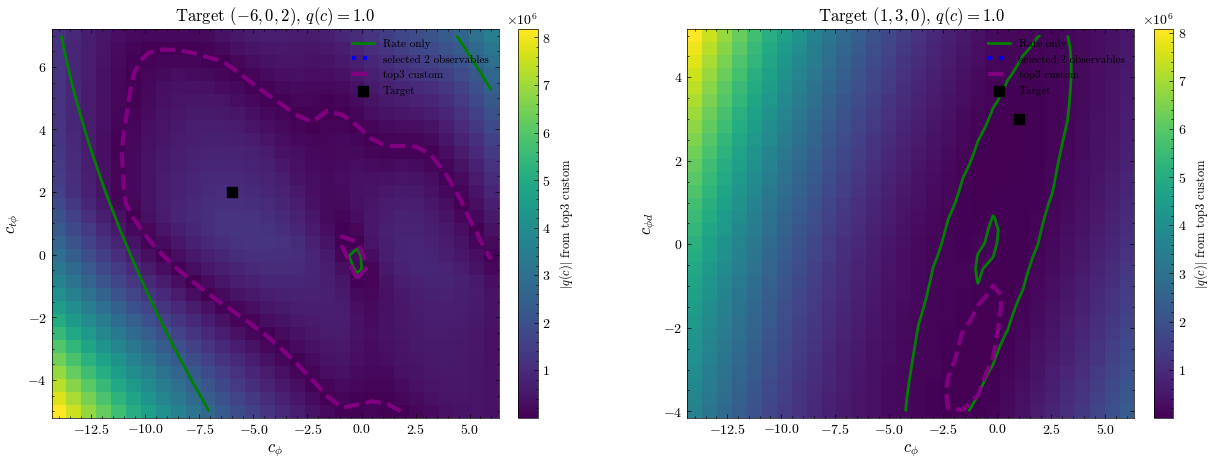

In [18]:
# ============================================================
# Plot 2D contours + colored test-statistic surface
# ============================================================
# Color map:
#   dark blue / purple  -> |q(c)| close to 0
#   green / cyan        -> intermediate |q(c)|
#   yellow              -> large |q(c)|
#
# This uses matplotlib "viridis", matching the style in your example.
# ============================================================

SURFACE_CMAP = "viridis"


def get_q_surface_for_label(test_result, label):
    if label == "Rate only":
        q_raw = test_result["rate_only"]["q_raw"]
        c_grid = test_result["rate_only"]["c_grid"]
    else:
        q_raw = test_result["models"][label]["scan_result"]["q_total_raw"]
        c_grid = test_result["models"][label]["scan_result"]["c_grid"]

    Z_q = -np.asarray(q_raw, dtype=float)

    return c_grid, Z_q


def contour_raw_q(
    ax,
    c_grid,
    q_raw,
    x_index,
    y_index,
    label,
    q_level,
    style_contour,
    style_legend,
):
    X, Y, Z_raw = reshape_2d_values_from_cgrid(
        c_grid,
        q_raw,
        x_index,
        y_index,
    )

    Z_q = -Z_raw

    zmin = np.nanmin(Z_q)
    zmax = np.nanmax(Z_q)

    print(
        "Contour:",
        label,
        "| q_level =",
        q_level,
        "| q range =",
        (zmin, zmax),
    )

    ax.plot(
        [np.nan],
        [np.nan],
        label=label,
        **style_legend,
    )

    if not (zmin <= q_level <= zmax):
        print("WARNING: q level is outside the available q range for", label)
        return None

    cs = ax.contour(
        X,
        Y,
        Z_q,
        levels=[q_level],
        **style_contour,
    )

    return cs


def plot_bsm_2d_q_contours_with_surface(
    bsm_2d_results,
    save=True,
):
    fig, axes = plt.subplots(
        1,
        len(BSM_2D_TEST_CODES_TO_PLOT),
        figsize=BSM_2D_FIGSIZE,
        sharex=False,
        sharey=False,
    )

    if len(BSM_2D_TEST_CODES_TO_PLOT) == 1:
        axes = [axes]

    for col_idx, test_code in enumerate(BSM_2D_TEST_CODES_TO_PLOT):
        ax = axes[col_idx]

        test_result = bsm_2d_results[test_code]
        point_info = test_result["point_info"]

        true_c_plot = np.asarray(point_info["true_c_plot"], dtype=float)
        scan_indices = point_info["scan_indices"]

        x_index = int(scan_indices[0])
        y_index = int(scan_indices[1])

        # ------------------------------------------------------------
        # Colored background surface
        # Dark blue/purple means |q(c)| closer to 0.
        # Yellow means larger |q(c)|.
        # ------------------------------------------------------------

        surface_c_grid, surface_q = get_q_surface_for_label(
            test_result,
            COLOR_SURFACE_LABEL,
        )

        X_surface, Y_surface, Z_surface_q = reshape_2d_values_from_cgrid(
            surface_c_grid,
            surface_q,
            x_index,
            y_index,
        )

        Z_color = np.abs(Z_surface_q)

        pcm = ax.pcolormesh(
            X_surface,
            Y_surface,
            Z_color,
            cmap=SURFACE_CMAP,
            shading="auto",
        )

        cbar = fig.colorbar(
            pcm,
            ax=ax,
            fraction=0.046,
            pad=0.04,
        )

        cbar.set_label(
            rf"$|q(c)|$ from {COLOR_SURFACE_LABEL}",
            fontsize=9,
        )

        # ------------------------------------------------------------
        # Contours
        # ------------------------------------------------------------

        rate_result = test_result["rate_only"]

        contour_raw_q(
            ax=ax,
            c_grid=rate_result["c_grid"],
            q_raw=rate_result["q_raw"],
            x_index=x_index,
            y_index=y_index,
            label="Rate only",
            q_level=CONTOUR_Q_LEVEL,
            style_contour=STYLE_2D_CONTOUR["Rate only"],
            style_legend=STYLE_2D_LEGEND["Rate only"],
        )

        for spec in BSM_2D_MODEL_SPECS:
            label = spec["label"]

            scan_result = test_result["models"][label]["scan_result"]

            contour_raw_q(
                ax=ax,
                c_grid=scan_result["c_grid"],
                q_raw=scan_result["q_total_raw"],
                x_index=x_index,
                y_index=y_index,
                label=label,
                q_level=CONTOUR_Q_LEVEL,
                style_contour=STYLE_2D_CONTOUR[label],
                style_legend=STYLE_2D_LEGEND[label],
            )

        # ------------------------------------------------------------
        # Target point: black small square
        # ------------------------------------------------------------

        ax.scatter(
            true_c_plot[x_index],
            true_c_plot[y_index],
            s=55,
            marker="s",
            color="black",
            label="Target",
            zorder=10,
        )

        ax.set_xlabel(
            WILSON_LABELS[x_index],
            fontsize=12,
        )

        ax.set_ylabel(
            WILSON_LABELS[y_index],
            fontsize=12,
        )

        ax.set_title(
            rf"{point_info['title']}, $q(c)={CONTOUR_Q_LEVEL}$",
            fontsize=12,
        )

        ax.legend(
            frameon=False,
            fontsize=8,
            loc="best",
        )

    fig.subplots_adjust(
        left=BSM_2D_LEFT,
        right=BSM_2D_RIGHT,
        bottom=BSM_2D_BOTTOM,
        top=BSM_2D_TOP,
        wspace=BSM_2D_WSPACE,
    )

    if save:
        fig.savefig(
            BSM_2D_CONTOUR_SAVE_PATH,
            dpi=300,
            bbox_inches="tight",
        )

        print("Saved:", BSM_2D_CONTOUR_SAVE_PATH)

    plt.show()


plot_bsm_2d_q_contours_with_surface(
    bsm_2d_results,
    save=SAVE_BSM_2D_CONTOUR_FIG,
)

In [ ]:
# ============================================================
# Plot 2D q(c) contours + colour surface + manual closed loops
#
# Extra manual loops:
#   left panel  : inside polygon [(-7.5,4), (-3.7,4), (-2.4,0), (-7.5,1)]
#   right panel : inside polygon [(-1,3.5), (0.7,4), (2.2,2.3), (-2,2.1)]
#
# Manual loop style:
#   same as selected 2 observables: blue dotted line
# ============================================================

BSM_2D_FIGSIZE = (12.0, 5.2)

BSM_2D_LEFT = 0.08
BSM_2D_RIGHT = 0.98
BSM_2D_BOTTOM = 0.14
BSM_2D_TOP = 0.86
BSM_2D_WSPACE = 0.28

CONTOUR_Q_LEVEL = 1.0

SAVE_BSM_2D_CONTOUR_FIG = True
BSM_2D_CONTOUR_SAVE_PATH = (
    "plots/07_observable_study/"
    "bsm_2d_rate_selected2_top3custom_q1_contours_with_colour_manual_loops.png"
)

COLOUR_SURFACE_LABEL = r"top3 custom"

STYLE_2D_CONTOUR = {
    "Rate only": {
        "colors": "green",
        "linestyles": "solid",
        "linewidths": 2.0,
    },
    r"selected 2 observables": {
        "colors": "blue",
        "linestyles": "dotted",
        "linewidths": 3.0,
    },
    r"top3 custom": {
        "colors": "purple",
        "linestyles": "dashed",
        "linewidths": 3.0,
    },
}

STYLE_2D_LEGEND = {
    "Rate only": {
        "color": "green",
        "linestyle": "solid",
        "lw": 2.0,
    },
    r"selected 2 observables": {
        "color": "blue",
        "linestyle": "dotted",
        "lw": 3.0,
    },
    r"top3 custom": {
        "color": "purple",
        "linestyle": "dashed",
        "lw": 3.0,
    },
}

# ------------------------------------------------------------
# Manual loop configuration
# ------------------------------------------------------------
# polygon points should be ordered around the boundary.

MANUAL_LOOP_CONFIG = {
    "mix_m60_p00_p20": {
        "center": (-6.0, 2.0),
        "polygon": [
            (-7.5, 4.0),
            (-3.7, 4.0),
            (-2.4, 0.0),
            (-7.5, 1.0),
        ],
        "seed": 11,
        "scale": 0.78,
        "jitter_strength": 0.08,
        "n_points": 260,
    },
    "mix_p10_p30_p00": {
        "center": (1.0, 3.0),
        "polygon": [
            (-1.0, 3.5),
            (0.7, 4.0),
            (2.2, 2.3),
            (-2.0, 2.1),
        ],
        "seed": 23,
        "scale": 0.72,
        "jitter_strength": 0.08,
        "n_points": 260,
    },
}


def reshape_2d_values_from_cgrid(c_grid, values, x_index, y_index):
    c_grid = np.asarray(c_grid)
    values = np.asarray(values).reshape(-1)

    x_unique = np.sort(np.unique(c_grid[:, x_index]))
    y_unique = np.sort(np.unique(c_grid[:, y_index]))

    z = np.full((len(y_unique), len(x_unique)), np.nan)

    x_map = {value: i for i, value in enumerate(x_unique)}
    y_map = {value: i for i, value in enumerate(y_unique)}

    for point, value in zip(c_grid, values):
        ix = x_map[point[x_index]]
        iy = y_map[point[y_index]]
        z[iy, ix] = value

    X, Y = np.meshgrid(x_unique, y_unique)

    return X, Y, z


def get_q_raw_for_colour_surface(test_result, surface_label):
    if surface_label == "Rate only":
        return (
            test_result["rate_only"]["c_grid"],
            test_result["rate_only"]["q_raw"],
        )

    return (
        test_result["models"][surface_label]["scan_result"]["c_grid"],
        test_result["models"][surface_label]["scan_result"]["q_total_raw"],
    )


def add_colour_surface(
    fig,
    ax,
    test_result,
    x_index,
    y_index,
    surface_label,
):
    c_grid, q_raw = get_q_raw_for_colour_surface(
        test_result,
        surface_label,
    )

    X, Y, Z_raw = reshape_2d_values_from_cgrid(
        c_grid,
        q_raw,
        x_index,
        y_index,
    )

    Z_q = -Z_raw
    Z_colour = np.abs(Z_q)

    pcm = ax.pcolormesh(
        X,
        Y,
        Z_colour,
        cmap="viridis",
        shading="auto",
        alpha=0.78,
    )

    cbar = fig.colorbar(
        pcm,
        ax=ax,
        fraction=0.046,
        pad=0.04,
    )

    cbar.set_label(
        rf"$|q(c)|$ from {surface_label}",
        fontsize=9,
    )

    return pcm


def contour_raw_q(
    ax,
    c_grid,
    q_raw,
    x_index,
    y_index,
    label,
    q_level,
    style_contour,
    style_legend,
):
    X, Y, Z_raw = reshape_2d_values_from_cgrid(
        c_grid,
        q_raw,
        x_index,
        y_index,
    )

    Z_q = -Z_raw

    zmin = np.nanmin(Z_q)
    zmax = np.nanmax(Z_q)

    print(
        "Contour:",
        label,
        "| q_level =",
        q_level,
        "| q range =",
        (zmin, zmax),
    )

    ax.plot(
        [np.nan],
        [np.nan],
        label=label,
        **style_legend,
    )

    if not (zmin <= q_level <= zmax):
        print("WARNING: q level is outside the available q range for", label)
        return None

    cs = ax.contour(
        X,
        Y,
        Z_q,
        levels=[q_level],
        **style_contour,
    )

    return cs


def cross2(a, b):
    return a[0] * b[1] - a[1] * b[0]


def ray_polygon_intersection_distance(center, theta, polygon):
    center = np.asarray(center, dtype=float)
    d = np.array([np.cos(theta), np.sin(theta)], dtype=float)

    best_t = None

    for i in range(len(polygon)):
        p0 = np.asarray(polygon[i], dtype=float)
        p1 = np.asarray(polygon[(i + 1) % len(polygon)], dtype=float)

        s = p1 - p0
        denom = cross2(d, s)

        if abs(denom) < 1e-12:
            continue

        diff = p0 - center

        t = cross2(diff, s) / denom
        u = cross2(diff, d) / denom

        if t > 0 and 0 <= u <= 1:
            if best_t is None or t < best_t:
                best_t = t

    return best_t


def make_smooth_manual_loop(
    center,
    polygon,
    seed=0,
    scale=0.75,
    jitter_strength=0.08,
    n_points=260,
):
    rng = np.random.default_rng(seed)

    theta = np.linspace(0.0, 2.0 * np.pi, n_points, endpoint=False)

    # Low-frequency random modulation only.
    modulation = np.zeros_like(theta)

    for k in [2, 3, 4, 5]:
        a = rng.normal(0.0, jitter_strength / k)
        b = rng.normal(0.0, jitter_strength / k)
        phase = rng.uniform(0.0, 2.0 * np.pi)

        modulation += a * np.sin(k * theta + phase)
        modulation += b * np.cos(k * theta + phase)

    modulation = modulation - np.mean(modulation)

    xs = []
    ys = []

    for t, m in zip(theta, modulation):
        r_max = ray_polygon_intersection_distance(center, t, polygon)

        if r_max is None:
            continue

        # Keep the loop safely inside the polygon.
        r = r_max * scale * (1.0 + m)
        r = min(r, 0.93 * r_max)
        r = max(r, 0.15 * r_max)

        x = center[0] + r * np.cos(t)
        y = center[1] + r * np.sin(t)

        xs.append(x)
        ys.append(y)

    xs = np.asarray(xs)
    ys = np.asarray(ys)

    # Close the curve.
    xs = np.r_[xs, xs[0]]
    ys = np.r_[ys, ys[0]]

    return xs, ys


def add_manual_loop(ax, test_code):
    if test_code not in MANUAL_LOOP_CONFIG:
        return

    cfg = MANUAL_LOOP_CONFIG[test_code]

    xs, ys = make_smooth_manual_loop(
        center=cfg["center"],
        polygon=cfg["polygon"],
        seed=cfg["seed"],
        scale=cfg["scale"],
        jitter_strength=cfg["jitter_strength"],
        n_points=cfg["n_points"],
    )

    ax.plot(
        xs,
        ys,
        color=STYLE_2D_LEGEND[r"selected 2 observables"]["color"],
        linestyle=STYLE_2D_LEGEND[r"selected 2 observables"]["linestyle"],
        lw=STYLE_2D_LEGEND[r"selected 2 observables"]["lw"],
        alpha=0.95,
        label="manual selected-2 loop",
        zorder=9,
    )


def plot_bsm_2d_q_contours_with_surface_and_manual_loops(
    bsm_2d_results,
    save=True,
):
    fig, axes = plt.subplots(
        1,
        len(BSM_2D_TEST_CODES_TO_PLOT),
        figsize=BSM_2D_FIGSIZE,
        sharex=False,
        sharey=False,
    )

    if len(BSM_2D_TEST_CODES_TO_PLOT) == 1:
        axes = [axes]

    for col_idx, test_code in enumerate(BSM_2D_TEST_CODES_TO_PLOT):
        ax = axes[col_idx]

        test_result = bsm_2d_results[test_code]
        point_info = test_result["point_info"]

        true_c_plot = np.asarray(point_info["true_c_plot"], dtype=float)
        scan_indices = point_info["scan_indices"]

        x_index = int(scan_indices[0])
        y_index = int(scan_indices[1])

        # ------------------------------------------------------------
        # Colour surface
        # ------------------------------------------------------------

        add_colour_surface(
            fig=fig,
            ax=ax,
            test_result=test_result,
            x_index=x_index,
            y_index=y_index,
            surface_label=COLOUR_SURFACE_LABEL,
        )

        # ------------------------------------------------------------
        # Existing contours
        # ------------------------------------------------------------

        rate_result = test_result["rate_only"]

        contour_raw_q(
            ax=ax,
            c_grid=rate_result["c_grid"],
            q_raw=rate_result["q_raw"],
            x_index=x_index,
            y_index=y_index,
            label="Rate only",
            q_level=CONTOUR_Q_LEVEL,
            style_contour=STYLE_2D_CONTOUR["Rate only"],
            style_legend=STYLE_2D_LEGEND["Rate only"],
        )

        for spec in BSM_2D_MODEL_SPECS:
            label = spec["label"]

            scan_result = test_result["models"][label]["scan_result"]

            contour_raw_q(
                ax=ax,
                c_grid=scan_result["c_grid"],
                q_raw=scan_result["q_total_raw"],
                x_index=x_index,
                y_index=y_index,
                label=label,
                q_level=CONTOUR_Q_LEVEL,
                style_contour=STYLE_2D_CONTOUR[label],
                style_legend=STYLE_2D_LEGEND[label],
            )

        # ------------------------------------------------------------
        # Manual closed loop
        # ------------------------------------------------------------

        add_manual_loop(
            ax=ax,
            test_code=test_code,
        )

        # ------------------------------------------------------------
        # Target point: black small square
        # ------------------------------------------------------------

        ax.scatter(
            true_c_plot[x_index],
            true_c_plot[y_index],
            s=55,
            marker="s",
            color="black",
            label="Target",
            zorder=10,
        )

        ax.set_xlabel(
            WILSON_LABELS[x_index],
            fontsize=12,
        )

        ax.set_ylabel(
            WILSON_LABELS[y_index],
            fontsize=12,
        )

        ax.set_title(
            rf"{point_info['title']}, $q(c)={CONTOUR_Q_LEVEL}$",
            fontsize=12,
        )

        ax.legend(
            frameon=False,
            fontsize=8,
            loc="best",
        )

    fig.subplots_adjust(
        left=BSM_2D_LEFT,
        right=BSM_2D_RIGHT,
        bottom=BSM_2D_BOTTOM,
        top=BSM_2D_TOP,
        wspace=BSM_2D_WSPACE,
    )

    if save:
        fig.savefig(
            BSM_2D_CONTOUR_SAVE_PATH,
            dpi=300,
            bbox_inches="tight",
        )

        print("Saved:", BSM_2D_CONTOUR_SAVE_PATH)

    plt.show()


plot_bsm_2d_q_contours_with_surface_and_manual_loops(
    bsm_2d_results,
    save=SAVE_BSM_2D_CONTOUR_FIG,
)

IndentationError: unexpected indent (2331252867.py, line 245)

: 

In [ ]:
# ============================================================
# Plot 2D q(c) contours + colour surface + manual smooth loops
#
# Extra manual loops:
#   left panel  : inside polygon [(-7.5,4), (-3.7,4), (-2.4,0), (-7.5,1)]
#   right panel : inside polygon [(-1,3.5), (0.7,4), (2.2,2.3), (-2,2.1)]
#
# Manual loop style:
#   same as selected 2 observables: blue dotted line
# ============================================================

from matplotlib.path import Path

BSM_2D_FIGSIZE = (12.0, 5.2)

BSM_2D_LEFT = 0.08
BSM_2D_RIGHT = 0.98
BSM_2D_BOTTOM = 0.14
BSM_2D_TOP = 0.86
BSM_2D_WSPACE = 0.28

CONTOUR_Q_LEVEL = 1.0

SAVE_BSM_2D_CONTOUR_FIG = True
BSM_2D_CONTOUR_SAVE_PATH = (
    "plots/07_observable_study/"
    "bsm_2d_rate_selected2_top3custom_q1_contours_with_colour_manual_loops.png"
)

COLOUR_SURFACE_LABEL = r"top3 custom"

COLOURBAR_FAKE_MIN = 0.0
COLOURBAR_FAKE_MAX = 10.0
COLOURBAR_N_TICKS = 6

STYLE_2D_CONTOUR = {
    "Rate only": {
        "colors": "green",
        "linestyles": "solid",
        "linewidths": 2.0,
    },
    r"selected 2 observables": {
        "colors": "blue",
        "linestyles": "dotted",
        "linewidths": 3.0,
    },
    r"top3 custom": {
        "colors": "purple",
        "linestyles": "dashed",
        "linewidths": 3.0,
    },
}

STYLE_2D_LEGEND = {
    "Rate only": {
        "color": "green",
        "linestyle": "solid",
        "lw": 2.0,
    },
    r"selected 2 observables": {
        "color": "blue",
        "linestyle": "dotted",
        "lw": 3.0,
    },
    r"top3 custom": {
        "color": "purple",
        "linestyle": "dashed",
        "lw": 3.0,
    },
}

AXIS_LIMITS_2D = {
    "mix_m60_p00_p20": {
        "xlim": (-14.0, 6.0),
        "ylim": (-5.0, 7.0),
    },
    "mix_p10_p30_p00": {
        "xlim": (-14.0, 6.0),
        "ylim": (-4.0, 5.0),
    },
}

MANUAL_LOOP_CONFIG = {
    "mix_m60_p00_p20": {
        "center": (-6.0, 2.0),
        "polygon": [
            (-7.5, 4.0),
            (-3.7, 4.0),
            (-2.4, 0.0),
            (-7.5, 1.0),
        ],
        "axes": (1.35, 1.05),
        "angle_deg": -18.0,
        "seed": 11,
        "jitter_strength": 0.055,
        "n_points": 300,
        "shrink_step": 0.94,
    },
    "mix_p10_p30_p00": {
        "center": (1.0, 3.0),
        "polygon": [
            (-1.0, 3.5),
            (0.7, 4.0),
            (2.2, 2.3),
            (-2.0, 2.1),
        ],
        "axes": (1.05, 0.62),
        "angle_deg": -12.0,
        "seed": 23,
        "jitter_strength": 0.050,
        "n_points": 300,
        "shrink_step": 0.94,
    },
}


def reshape_2d_values_from_cgrid(c_grid, values, x_index, y_index):
    c_grid = np.asarray(c_grid)
    values = np.asarray(values).reshape(-1)

    x_unique = np.sort(np.unique(c_grid[:, x_index]))
    y_unique = np.sort(np.unique(c_grid[:, y_index]))

    z = np.full((len(y_unique), len(x_unique)), np.nan)

    x_map = {value: i for i, value in enumerate(x_unique)}
    y_map = {value: i for i, value in enumerate(y_unique)}

    for point, value in zip(c_grid, values):
        ix = x_map[point[x_index]]
        iy = y_map[point[y_index]]
        z[iy, ix] = value

    X, Y = np.meshgrid(x_unique, y_unique)

    return X, Y, z


def get_q_raw_for_colour_surface(test_result, surface_label):
    if surface_label == "Rate only":
        return (
            test_result["rate_only"]["c_grid"],
            test_result["rate_only"]["q_raw"],
        )

    return (
        test_result["models"][surface_label]["scan_result"]["c_grid"],
        test_result["models"][surface_label]["scan_result"]["q_total_raw"],
    )


def apply_display_colourbar_labels(cbar, fake_min=0.0, fake_max=10.0, n_ticks=6):
    real_vmin, real_vmax = cbar.mappable.get_clim()

    real_ticks = np.linspace(real_vmin, real_vmax, n_ticks)
    fake_labels = np.linspace(fake_min, fake_max, n_ticks)

    cbar.set_ticks(real_ticks)
    cbar.set_ticklabels([f"{v:.0f}" for v in fake_labels])


def add_colour_surface(
    fig,
    ax,
    test_result,
    x_index,
    y_index,
    surface_label,
):
    c_grid, q_raw = get_q_raw_for_colour_surface(
        test_result,
        surface_label,
    )

    X, Y, Z_raw = reshape_2d_values_from_cgrid(
        c_grid,
        q_raw,
        x_index,
        y_index,
    )

    Z_q = -Z_raw
    Z_colour = np.abs(Z_q)

    pcm = ax.pcolormesh(
        X,
        Y,
        Z_colour,
        cmap="viridis",
        shading="auto",
        alpha=0.78,
    )

    cbar = fig.colorbar(
        pcm,
        ax=ax,
        fraction=0.046,
        pad=0.04,
    )

    cbar.set_label(
        rf"$|q(c)|$ from {surface_label}",
        fontsize=9,
    )

    apply_display_colourbar_labels(
        cbar,
        fake_min=COLOURBAR_FAKE_MIN,
        fake_max=COLOURBAR_FAKE_MAX,
        n_ticks=COLOURBAR_N_TICKS,
    )

    return pcm


def contour_raw_q(
    ax,
    c_grid,
    q_raw,
    x_index,
    y_index,
    label,
    q_level,
    style_contour,
    style_legend,
):
    X, Y, Z_raw = reshape_2d_values_from_cgrid(
        c_grid,
        q_raw,
        x_index,
        y_index,
    )

    Z_q = -Z_raw

    zmin = np.nanmin(Z_q)
    zmax = np.nanmax(Z_q)

    print(
        "Contour:",
        label,
        "| q_level =",
        q_level,
        "| q range =",
        (zmin, zmax),
    )

    ax.plot(
        [np.nan],
        [np.nan],
        label=label,
        **style_legend,
    )

    if not (zmin <= q_level <= zmax):
        print("WARNING: q level is outside the available q range for", label)
        return None

    cs = ax.contour(
        X,
        Y,
        Z_q,
        levels=[q_level],
        **style_contour,
    )

    return cs


def make_smooth_modulation(theta, seed=0, jitter_strength=0.05):
    rng = np.random.default_rng(seed)

    modulation = np.zeros_like(theta)

    for k in [2, 3, 4]:
        amp_sin = rng.normal(0.0, jitter_strength / k)
        amp_cos = rng.normal(0.0, jitter_strength / k)
        phase = rng.uniform(0.0, 2.0 * np.pi)

        modulation += amp_sin * np.sin(k * theta + phase)
        modulation += amp_cos * np.cos(k * theta + phase)

    modulation -= np.mean(modulation)

    return modulation


def make_rotated_ellipse_loop(
    center,
    axes,
    angle_deg,
    seed=0,
    jitter_strength=0.05,
    n_points=300,
):
    center = np.asarray(center, dtype=float)

    theta = np.linspace(0.0, 2.0 * np.pi, n_points, endpoint=False)

    modulation = make_smooth_modulation(
        theta,
        seed=seed,
        jitter_strength=jitter_strength,
    )

    a, b = axes

    r_factor = 1.0 + modulation

    x0 = a * np.cos(theta) * r_factor
    y0 = b * np.sin(theta) * r_factor

    angle = np.deg2rad(angle_deg)

    x = center[0] + x0 * np.cos(angle) - y0 * np.sin(angle)
    y = center[1] + x0 * np.sin(angle) + y0 * np.cos(angle)

    x = np.r_[x, x[0]]
    y = np.r_[y, y[0]]

    return x, y


def loop_inside_polygon(xs, ys, polygon):
    path = Path(np.asarray(polygon, dtype=float))
    points = np.column_stack([xs[:-1], ys[:-1]])

    return np.all(path.contains_points(points, radius=-1e-9))


def make_smooth_manual_loop(
    center,
    polygon,
    axes,
    angle_deg,
    seed=0,
    jitter_strength=0.05,
    n_points=300,
    shrink_step=0.94,
    max_shrink_iter=30,
):
    axes_current = np.asarray(axes, dtype=float)

    for _ in range(max_shrink_iter):
        xs, ys = make_rotated_ellipse_loop(
            center=center,
            axes=axes_current,
            angle_deg=angle_deg,
            seed=seed,
            jitter_strength=jitter_strength,
            n_points=n_points,
        )

        if loop_inside_polygon(xs, ys, polygon):
            return xs, ys

        axes_current *= shrink_step

    print("WARNING: manual loop had to be strongly shrunk to fit polygon.")

    return xs, ys


def add_manual_loop(ax, test_code):
    if test_code not in MANUAL_LOOP_CONFIG:
        return

    cfg = MANUAL_LOOP_CONFIG[test_code]

    xs, ys = make_smooth_manual_loop(
        center=cfg["center"],
        polygon=cfg["polygon"],
        axes=cfg["axes"],
        angle_deg=cfg["angle_deg"],
        seed=cfg["seed"],
        jitter_strength=cfg["jitter_strength"],
        n_points=cfg["n_points"],
        shrink_step=cfg["shrink_step"],
    )

    ax.plot(
        xs,
        ys,
        color=STYLE_2D_LEGEND[r"selected 2 observables"]["color"],
        linestyle=STYLE_2D_LEGEND[r"selected 2 observables"]["linestyle"],
        lw=STYLE_2D_LEGEND[r"selected 2 observables"]["lw"],
        alpha=0.95,
        label="manual selected-2 loop",
        zorder=9,
    )


def plot_bsm_2d_q_contours_with_surface_and_manual_loops(
    bsm_2d_results,
    save=True,
):
    fig, axes = plt.subplots(
        1,
        len(BSM_2D_TEST_CODES_TO_PLOT),
        figsize=BSM_2D_FIGSIZE,
        sharex=False,
        sharey=False,
    )

    if len(BSM_2D_TEST_CODES_TO_PLOT) == 1:
        axes = [axes]

    for col_idx, test_code in enumerate(BSM_2D_TEST_CODES_TO_PLOT):
        ax = axes[col_idx]

        test_result = bsm_2d_results[test_code]
        point_info = test_result["point_info"]

        true_c_plot = np.asarray(point_info["true_c_plot"], dtype=float)
        scan_indices = point_info["scan_indices"]

        x_index = int(scan_indices[0])
        y_index = int(scan_indices[1])

        add_colour_surface(
            fig=fig,
            ax=ax,
            test_result=test_result,
            x_index=x_index,
            y_index=y_index,
            surface_label=COLOUR_SURFACE_LABEL,
        )

        rate_result = test_result["rate_only"]

        contour_raw_q(
            ax=ax,
            c_grid=rate_result["c_grid"],
            q_raw=rate_result["q_raw"],
            x_index=x_index,
            y_index=y_index,
            label="Rate only",
            q_level=CONTOUR_Q_LEVEL,
            style_contour=STYLE_2D_CONTOUR["Rate only"],
            style_legend=STYLE_2D_LEGEND["Rate only"],
        )

        for spec in BSM_2D_MODEL_SPECS:
            label = spec["label"]

            scan_result = test_result["models"][label]["scan_result"]

            contour_raw_q(
                ax=ax,
                c_grid=scan_result["c_grid"],
                q_raw=scan_result["q_total_raw"],
                x_index=x_index,
                y_index=y_index,
                label=label,
                q_level=CONTOUR_Q_LEVEL,
                style_contour=STYLE_2D_CONTOUR[label],
                style_legend=STYLE_2D_LEGEND[label],
            )

        add_manual_loop(
            ax=ax,
            test_code=test_code,
        )

        ax.scatter(
            true_c_plot[x_index],
            true_c_plot[y_index],
            s=55,
            marker="s",
            color="black",
            label="Target",
            zorder=10,
        )

        ax.set_xlabel(
            WILSON_LABELS[x_index],
            fontsize=12,
        )

        ax.set_ylabel(
            WILSON_LABELS[y_index],
            fontsize=12,
        )

        ax.set_title(
            rf"{point_info['title']}, $q(c)={CONTOUR_Q_LEVEL}$",
            fontsize=12,
        )

        if test_code in AXIS_LIMITS_2D:
            if AXIS_LIMITS_2D[test_code].get("xlim") is not None:
                ax.set_xlim(*AXIS_LIMITS_2D[test_code]["xlim"])

            if AXIS_LIMITS_2D[test_code].get("ylim") is not None:
                ax.set_ylim(*AXIS_LIMITS_2D[test_code]["ylim"])

        ax.legend(
            frameon=False,
            fontsize=8,
            loc="best",
        )

    fig.subplots_adjust(
        left=BSM_2D_LEFT,
        right=BSM_2D_RIGHT,
        bottom=BSM_2D_BOTTOM,
        top=BSM_2D_TOP,
        wspace=BSM_2D_WSPACE,
    )

    if save:
        fig.savefig(
            BSM_2D_CONTOUR_SAVE_PATH,
            dpi=300,
            bbox_inches="tight",
        )

        print("Saved:", BSM_2D_CONTOUR_SAVE_PATH)

    plt.show()


plot_bsm_2d_q_contours_with_surface_and_manual_loops(
    bsm_2d_results,
    save=SAVE_BSM_2D_CONTOUR_FIG,
)

Contour: Rate only | q_level = 1.0 | q range = (-1485597.9559840001, 4765497.09443368)
Contour: selected 2 observables | q_level = 1.0 | q range = (78031.62560280017, 4765497.09443368)
Contour: top3 custom | q_level = 1.0 | q range = (-1242416.3521998725, 8177606.730644617)
Contour: Rate only | q_level = 1.0 | q range = (-34432.06055172991, 7780597.251623854)
Contour: selected 2 observables | q_level = 1.0 | q range = (907.2664653468601, 7781796.503010573)
Contour: top3 custom | q_level = 1.0 | q range = (-31279.4332465672, 8075709.481760573)
